# 18. Mechanistic chord architecture v3 vs LV geometry and mechanics

## Цель ноутбука

В этом ноутбуке проверяется новая механистическая классификация архитектуры ложных хорд ЛЖ.

Мы уходим от слишком грубой классификации:

- local-simple vs complex;
- residual network;
- broad non-apical topology.

Новая классификация строится не просто по сложности, а по предполагаемой механической роли хорды.

## Новая классификация

### Group 1 — Local transverse / low-angle chord

Локальная поперечная или почти поперечная хорда, соединяющая соседние регионы.

Физиологический смысл:

локальное transverse / low-angle tethering-ограничение без выраженного дальнего моста.

---

### Group 2 — Single long oblique bridge

Одиночная протяжённая косая хорда.

Физиологический смысл:

один длинный косой мост, потенциально связывающий удалённые механические зоны ЛЖ.

---

### Group 3 — Double transverse without long oblique

Две поперечные хорды, но без протяжённой косой хорды.

Физиологический смысл:

усиленное поперечное tethering-ограничение, но ещё не распределённая сеть.

---

### Group 4 — Chord network

Сеть хорд.

Физиологический смысл:

множественная внутриполостная архитектура, где важна уже не одна хорда, а распределённая система механических связей.

## Outcomes

Основные outcomes:

- `echo_lv_sphericity_index_end_diastolic_ratio`
- `echo_lv_sphericity_index_end_systolic_ratio`
- `echo_lv_myocardial_mass_index_g_m2`
- `echo_lv_sws_delta_g_cm2`
- `merged_lv_deformation_cv_pct`
- `dicor_sm_kdtr_cv_pct`

## Методический принцип

Неизвестные или не подходящие под правила случаи не отправляются автоматически в сеть.
Они остаются `unclassified`, чтобы не создавать искусственную остаточную группу.

In [1]:
# ============================================================
# 18. Mechanistic chord architecture v3 vs LV mechanics
# ============================================================

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy import stats
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords")

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

FINAL_DATA_PATH = DATA_DIR / "final_analysis_dataset_ver2.xlsx"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FINAL_DATA_PATH exists:", FINAL_DATA_PATH.exists(), FINAL_DATA_PATH)

# ------------------------------------------------------------
# Academic plot style
# ------------------------------------------------------------

sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.15,
)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "figure.figsize": (8.0, 5.0),

    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "axes.grid": False,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 12,

    "xtick.direction": "out",
    "ytick.direction": "out",

    "legend.frameon": False,
})

PROJECT_ROOT: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords
FINAL_DATA_PATH exists: True C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\final_analysis_dataset_ver2.xlsx


In [2]:
# ============================================================
# Load final dataset and mechanistic dataset if available
# ============================================================

df_final = pd.read_excel(FINAL_DATA_PATH)

print("df_final:", df_final.shape)
display(df_final.head())

# Try to find regression_mechanistic_dataset.xlsx automatically
mech_candidates = list(PROJECT_ROOT.rglob("regression_mechanistic_dataset.xlsx"))

print("\nMechanistic dataset candidates:")
for p in mech_candidates:
    print(p)

if len(mech_candidates) > 0:
    MECH_DATA_PATH = mech_candidates[0]
    df_mech = pd.read_excel(MECH_DATA_PATH)
    print("\nUsing MECH_DATA_PATH:", MECH_DATA_PATH)
    print("df_mech:", df_mech.shape)
else:
    MECH_DATA_PATH = None
    df_mech = None
    print("\nWARNING: regression_mechanistic_dataset.xlsx was not found. Will use df_final only.")

df_final: (153, 222)


,subject_full_name,age,height_cm,weight_cm,BSA,sex,IMT,echo_ascending_aorta_diameter_mm_div_bsa,echo_ascending_aorta_diameter_mm,echo_aortic_sinus_diameter_mm_div_bsa,...,echo_lv_strain_plus_cv_pct,echo_lv_strain_rate_cv_pct,echo_lv_systolic_wall_stress_g_cm2,merged_lv_deformation_cv_pct,hemo_sbp_rest_mmhg,hemo_sbp_exercise_mmhg,dsws,echo_lv_sws_rest_g_cm2,echo_lv_sws_max_g_cm2,echo_lv_sws_delta_g_cm2
0,Абатурова,23.0,176.0,70.0,1.849925,1.0,23.0,14.054624,26.0,13.514062,...,NaN,NaN,114.446420,24.0,122.0,159.0,37.0,116.630910,152.002579,35.371669
1,Абросимова,15.0,163.0,62.0,1.675477,1.0,23.3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Айтиева,20.0,155.0,58.5,1.587057,1.0,24.5,16.382524,26.0,16.382524,...,NaN,NaN,169.629253,37.0,119.0,161.0,42.0,109.309091,147.888770,38.579679
3,Алиева,21.0,152.0,53.3,1.500148,1.0,23.0,17.331622,26.0,15.331819,...,NaN,NaN,67.794404,33.0,109.0,155.0,46.0,96.054733,136.591592,40.536860
4,Артемова,17.0,161.0,55.0,1.568350,1.0,21.0,13.389867,21.0,13.389867,...,NaN,NaN,96.909213,NaN,118.0,139.0,21.0,75.558075,101.839145,26.281070



Mechanistic dataset candidates:
C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\interim\regression_mechanistic_dataset.xlsx

Using MECH_DATA_PATH: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\interim\regression_mechanistic_dataset.xlsx
df_mech: (153, 224)


In [3]:
# ============================================================
# Merge mechanistic variables safely
# ============================================================

ID_COL = "subject_full_name"

candidate_mech_cols = [
    "mechanical_chord_phenotype",
    "chord_type_complexity_class",
    "lv_false_tendon_total_count",
    "transverse_load",
    "oblique_load",
    "long_oblique_bridge_load",
    "chord_type_diversity",
    "tethering_index",
]

if df_mech is not None:
    existing_mech_cols = [c for c in candidate_mech_cols if c in df_mech.columns]
    
    print("Existing mechanistic columns in df_mech:")
    print(existing_mech_cols)
    
    df = df_final.copy()
    
    # Only add columns that are absent in df_final
    cols_to_add = [c for c in existing_mech_cols if c not in df.columns]
    
    print("\nMechanistic columns to add:")
    print(cols_to_add)
    
    if len(cols_to_add) > 0:
        if ID_COL in df.columns and ID_COL in df_mech.columns:
            df = df.merge(
                df_mech[[ID_COL] + cols_to_add],
                on=ID_COL,
                how="left",
                validate="one_to_one",
            )
            print("\nMerged by subject_full_name:", df.shape)
        else:
            print("\nWARNING: subject_full_name not found in both datasets. Using row-order fallback.")
            if len(df) != len(df_mech):
                raise ValueError("Cannot row-order merge: df_final and df_mech have different number of rows.")
            for col in cols_to_add:
                df[col] = df_mech[col].values
    else:
        print("\nAll selected mechanistic columns already exist in df_final.")
else:
    df = df_final.copy()

print("\nWorking df:", df.shape)

needed_cols = candidate_mech_cols
existing = [c for c in needed_cols if c in df.columns]
missing = [c for c in needed_cols if c not in df.columns]

print("\nExisting in working df:")
print(existing)

print("\nMissing in working df:")
print(missing)

Existing mechanistic columns in df_mech:
['mechanical_chord_phenotype', 'chord_type_complexity_class', 'lv_false_tendon_total_count', 'transverse_load', 'oblique_load', 'long_oblique_bridge_load', 'chord_type_diversity', 'tethering_index']

Mechanistic columns to add:
['mechanical_chord_phenotype', 'chord_type_complexity_class', 'transverse_load', 'oblique_load', 'long_oblique_bridge_load', 'chord_type_diversity', 'tethering_index']

Merged by subject_full_name: (153, 229)

Working df: (153, 229)

Existing in working df:
['mechanical_chord_phenotype', 'chord_type_complexity_class', 'lv_false_tendon_total_count', 'transverse_load', 'oblique_load', 'long_oblique_bridge_load', 'chord_type_diversity', 'tethering_index']

Missing in working df:
[]


In [4]:
# ============================================================
# Detect chord attachment columns and create topology helpers
# ============================================================

attachment_cols = [
    c for c in df.columns
    if ("chord_attachment" in c.lower()) or ("attachment_flag" in c.lower() and "chord" in c.lower())
]

basal_attachment_cols = [c for c in attachment_cols if "_basal_" in c.lower()]
mid_attachment_cols = [c for c in attachment_cols if "_mid_" in c.lower()]
apical_attachment_cols = [c for c in attachment_cols if "_apical_" in c.lower()]

print("All attachment cols:", len(attachment_cols))
print("Basal attachment cols:", len(basal_attachment_cols))
print("Mid attachment cols:", len(mid_attachment_cols))
print("Apical attachment cols:", len(apical_attachment_cols))

print("\nBasal:")
print(basal_attachment_cols)

print("\nMid:")
print(mid_attachment_cols)

print("\nApical:")
print(apical_attachment_cols)


def row_any_positive(row, cols):
    if not cols:
        return False
    values = pd.to_numeric(row[cols], errors="coerce").fillna(0)
    return bool((values > 0).any())


def row_sum_positive(row, cols):
    if not cols:
        return 0
    values = pd.to_numeric(row[cols], errors="coerce").fillna(0)
    return int((values > 0).sum())


# Attachment level flags
df["has_basal_chord_attachment"] = df.apply(lambda r: row_any_positive(r, basal_attachment_cols), axis=1)
df["has_mid_chord_attachment"] = df.apply(lambda r: row_any_positive(r, mid_attachment_cols), axis=1)
df["has_apical_chord_attachment"] = df.apply(lambda r: row_any_positive(r, apical_attachment_cols), axis=1)

df["n_basal_chord_attachment_segments"] = df.apply(lambda r: row_sum_positive(r, basal_attachment_cols), axis=1)
df["n_mid_chord_attachment_segments"] = df.apply(lambda r: row_sum_positive(r, mid_attachment_cols), axis=1)
df["n_apical_chord_attachment_segments"] = df.apply(lambda r: row_sum_positive(r, apical_attachment_cols), axis=1)

df["n_chord_attachment_segments_total"] = (
    df["n_basal_chord_attachment_segments"]
    + df["n_mid_chord_attachment_segments"]
    + df["n_apical_chord_attachment_segments"]
)

df["n_involved_lv_levels"] = (
    df[[
        "has_basal_chord_attachment",
        "has_mid_chord_attachment",
        "has_apical_chord_attachment",
    ]]
    .astype(int)
    .sum(axis=1)
)

# Pure apical exclusion flag
df["is_pure_apical_chord_topology"] = (
    df["has_apical_chord_attachment"]
    & ~df["has_basal_chord_attachment"]
    & ~df["has_mid_chord_attachment"]
)

# Proxy for long basal-apical bridge
df["has_basal_apical_bridge_proxy"] = (
    df["has_basal_chord_attachment"]
    & df["has_apical_chord_attachment"]
)

# Convert numeric chord variables
numeric_chord_cols = [
    "lv_false_tendon_total_count",
    "transverse_load",
    "oblique_load",
    "long_oblique_bridge_load",
    "chord_type_diversity",
    "tethering_index",
]

for col in numeric_chord_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

helper_cols = [
    "has_basal_chord_attachment",
    "has_mid_chord_attachment",
    "has_apical_chord_attachment",
    "is_pure_apical_chord_topology",
    "has_basal_apical_bridge_proxy",
    "n_involved_lv_levels",
    "n_chord_attachment_segments_total",
]

display(df[helper_cols].describe(include="all"))

All attachment cols: 18
Basal attachment cols: 6
Mid attachment cols: 6
Apical attachment cols: 6

Basal:
['strain_plus_basal_anteroseptal_chord_attachment_flag', 'strain_plus_basal_anterior_chord_attachment_flag', 'strain_plus_basal_anterolateral_chord_attachment_flag', 'strain_plus_basal_inferolateral_chord_attachment_flag', 'strain_plus_basal_inferior_chord_attachment_flag', 'strain_plus_basal_inferoseptal_chord_attachment_flag']

Mid:
['strain_plus_mid_anteroseptal_chord_attachment_flag', 'strain_plus_mid_anterior_chord_attachment_flag', 'strain_plus_mid_anterolateral_chord_attachment_flag', 'strain_plus_mid_inferolateral_chord_attachment_flag', 'strain_plus_mid_inferior_chord_attachment_flag', 'strain_plus_mid_inferoseptal_chord_attachment_flag']

Apical:
['strain_plus_apical_anteroseptal_chord_attachment_flag', 'strain_plus_apical_anterior_chord_attachment_flag', 'strain_plus_apical_anterolateral_chord_attachment_flag', 'strain_plus_apical_inferolateral_chord_attachment_flag', 's

,has_basal_chord_attachment,has_mid_chord_attachment,has_apical_chord_attachment,is_pure_apical_chord_topology,has_basal_apical_bridge_proxy,n_involved_lv_levels,n_chord_attachment_segments_total
count,153,153,153,153,153,153.000000,153.000000
unique,2,2,2,1,2,NaN,NaN
top,False,False,False,False,False,NaN,NaN
freq,131,130,140,153,140,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,0.379085,0.745098
std,NaN,NaN,NaN,NaN,NaN,0.873638,1.695697
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000


In [5]:
# ============================================================
# New mechanistic chord architecture classification v3
# ============================================================

def classify_chord_architecture_v3(row):
    """
    New working classification:

    1. Local_transverse_or_low_angle:
       local transverse / low-angle chord connecting adjacent regions.

    2. Single_long_oblique_bridge:
       single long oblique chord only.

    3. Double_transverse_no_long_oblique:
       two transverse chords without long oblique bridge.

    4. Chord_network:
       distributed chord network.

    Exclusion:
       pure apical cases are excluded if is_pure_apical_chord_topology == True.

    Important:
       Unclear cases are not automatically assigned to network.
       They remain unclassified.
    """

    total = pd.to_numeric(row.get("lv_false_tendon_total_count", np.nan), errors="coerce")
    transverse = pd.to_numeric(row.get("transverse_load", np.nan), errors="coerce")
    oblique = pd.to_numeric(row.get("oblique_load", np.nan), errors="coerce")
    long_oblique = pd.to_numeric(row.get("long_oblique_bridge_load", np.nan), errors="coerce")
    diversity = pd.to_numeric(row.get("chord_type_diversity", np.nan), errors="coerce")
    n_levels = pd.to_numeric(row.get("n_involved_lv_levels", np.nan), errors="coerce")

    pure_apical = bool(row.get("is_pure_apical_chord_topology", False))

    has_basal = bool(row.get("has_basal_chord_attachment", False))
    has_mid = bool(row.get("has_mid_chord_attachment", False))
    has_apical = bool(row.get("has_apical_chord_attachment", False))
    basal_apical_bridge = bool(row.get("has_basal_apical_bridge_proxy", False))

    # 0. Exclude pure apical
    if pure_apical:
        return pd.Series([np.nan, "excluded_pure_apical"])

    # Missing total count: do not force into any group
    if pd.isna(total):
        return pd.Series([np.nan, "missing_total_chord_count"])

    # --------------------------------------------------------
    # 4. Chord network
    # --------------------------------------------------------
    # Network is checked first because 3+ chords dominate
    # over local orientation labels.
    if total >= 3:
        return pd.Series(["4_Chord_network", "network_total_chords_ge_3"])

    # Additional conservative network rule:
    # 2 chords + broad 3-level involvement may represent network-like architecture.
    if total >= 2 and not pd.isna(n_levels) and n_levels >= 3:
        return pd.Series(["4_Chord_network", "network_multilevel_involvement"])

    # --------------------------------------------------------
    # 2. Single long oblique bridge
    # --------------------------------------------------------
    if total == 1 and not pd.isna(long_oblique) and long_oblique >= 1:
        return pd.Series(["2_Single_long_oblique_bridge", "single_long_oblique_load"])

    # Proxy version: one chord with oblique component and basal-apical bridge
    if (
        total == 1
        and basal_apical_bridge
        and not pd.isna(oblique)
        and oblique >= 1
    ):
        return pd.Series(["2_Single_long_oblique_bridge", "single_basal_apical_oblique_proxy"])

    # --------------------------------------------------------
    # 3. Two transverse, no long oblique
    # --------------------------------------------------------
    if (
        total == 2
        and not pd.isna(transverse)
        and transverse >= 2
        and (pd.isna(long_oblique) or long_oblique == 0)
    ):
        return pd.Series(["3_Double_transverse_no_long_oblique", "two_transverse_no_long_oblique"])

    # --------------------------------------------------------
    # 1. Local transverse / low angle
    # --------------------------------------------------------
    # One transverse-like chord, without long oblique, without basal-apical bridge.
    if (
        total == 1
        and not pd.isna(transverse)
        and transverse >= 1
        and (pd.isna(long_oblique) or long_oblique == 0)
        and not basal_apical_bridge
    ):
        return pd.Series(["1_Local_transverse_or_low_angle", "single_local_transverse_no_bridge"])

    # Fallback proxy: one chord involving local / adjacent non-apical levels
    local_or_adjacent_non_apical = (
        (has_basal and not has_mid and not has_apical)
        or (has_mid and not has_basal and not has_apical)
        or (has_basal and has_mid and not has_apical)
    )

    if (
        total == 1
        and local_or_adjacent_non_apical
        and not basal_apical_bridge
        and (pd.isna(long_oblique) or long_oblique == 0)
    ):
        return pd.Series(["1_Local_transverse_or_low_angle", "single_adjacent_non_apical_proxy"])

    # Everything else remains unclassified
    return pd.Series([np.nan, "unclassified_by_v3_rules"])


df[["chord_architecture_v3", "chord_architecture_v3_reason"]] = df.apply(
    classify_chord_architecture_v3,
    axis=1
)

print("New v3 architecture counts:")
display(
    df["chord_architecture_v3"]
    .value_counts(dropna=False)
    .rename_axis("chord_architecture_v3")
    .reset_index(name="n")
)

print("\nReasons by group:")
display(
    pd.crosstab(
        df["chord_architecture_v3"],
        df["chord_architecture_v3_reason"],
        dropna=False
    )
)

print("\nAll reasons including unclassified:")
display(
    df["chord_architecture_v3_reason"]
    .value_counts(dropna=False)
    .rename_axis("reason")
    .reset_index(name="n")
)

New v3 architecture counts:


,chord_architecture_v3,n
0,NaN,64
1,4_Chord_network,62
2,3_Double_transverse_no_long_oblique,11
3,2_Single_long_oblique_bridge,8
4,1_Local_transverse_or_low_angle,8



Reasons by group:


chord_architecture_v3_reason,missing_total_chord_count,network_multilevel_involvement,network_total_chords_ge_3,single_local_transverse_no_bridge,single_long_oblique_load,two_transverse_no_long_oblique,unclassified_by_v3_rules
chord_architecture_v3,,,,,,,
1_Local_transverse_or_low_angle,0,0,0,8,0,0,0
2_Single_long_oblique_bridge,0,0,0,0,8,0,0
3_Double_transverse_no_long_oblique,0,0,0,0,0,11,0
4_Chord_network,0,2,60,0,0,0,0
NaN,21,0,0,0,0,0,43



All reasons including unclassified:


,reason,n
0,network_total_chords_ge_3,60
1,unclassified_by_v3_rules,43
2,missing_total_chord_count,21
3,two_transverse_no_long_oblique,11
4,single_long_oblique_load,8
5,single_local_transverse_no_bridge,8
6,network_multilevel_involvement,2


In [6]:
# ============================================================
# Labels and classification audit
# ============================================================

ARCH_GROUP_COL = "chord_architecture_v3"

ARCH_GROUP_ORDER = [
    "1_Local_transverse_or_low_angle",
    "2_Single_long_oblique_bridge",
    "3_Double_transverse_no_long_oblique",
    "4_Chord_network",
]

ARCH_GROUP_LABELS_RU = {
    "1_Local_transverse_or_low_angle": "1. Локальная\nпоперечная / малый угол",
    "2_Single_long_oblique_bridge": "2. Одиночная\nпротяжённая косая",
    "3_Double_transverse_no_long_oblique": "3. Две поперечные\nбез длинной косой",
    "4_Chord_network": "4. Сеть хорд",
}

audit_cols = [
    ID_COL,
    ARCH_GROUP_COL,
    "chord_architecture_v3_reason",
    "lv_false_tendon_total_count",
    "transverse_load",
    "oblique_load",
    "long_oblique_bridge_load",
    "chord_type_diversity",
    "tethering_index",
    "mechanical_chord_phenotype",
    "chord_type_complexity_class",
    "has_basal_chord_attachment",
    "has_mid_chord_attachment",
    "has_apical_chord_attachment",
    "is_pure_apical_chord_topology",
    "has_basal_apical_bridge_proxy",
    "n_involved_lv_levels",
    "n_chord_attachment_segments_total",
]

audit_cols = [c for c in audit_cols if c in df.columns]

classification_audit_v3 = df[audit_cols].copy()

display(classification_audit_v3.head(30))

classification_audit_v3.to_excel(
    TABLES_DIR / "18_chord_architecture_v3_classification_audit.xlsx",
    index=False
)

# Cross-tabs with previous classifications
for col in ["mechanical_chord_phenotype", "chord_type_complexity_class"]:
    if col in df.columns:
        print("\n" + "=" * 90)
        print(f"Cross-tab: {ARCH_GROUP_COL} × {col}")
        display(pd.crosstab(df[ARCH_GROUP_COL], df[col], dropna=False))

,subject_full_name,chord_architecture_v3,chord_architecture_v3_reason,lv_false_tendon_total_count,transverse_load,oblique_load,long_oblique_bridge_load,chord_type_diversity,tethering_index,mechanical_chord_phenotype,chord_type_complexity_class,has_basal_chord_attachment,has_mid_chord_attachment,has_apical_chord_attachment,is_pure_apical_chord_topology,has_basal_apical_bridge_proxy,n_involved_lv_levels,n_chord_attachment_segments_total
0,Абатурова,2_Single_long_oblique_bridge,single_long_oblique_load,1.0,0.0,4.0,1.0,3,1,Oblique-Only,3_complex_network,False,False,False,False,False,0,0
1,Абросимова,NaN,unclassified_by_v3_rules,2.0,NaN,NaN,NaN,0,0,No-selected-chord-types,0_no_selected_types,False,False,False,False,False,0,0
2,Айтиева,4_Chord_network,network_total_chords_ge_3,4.0,4.0,2.0,2.0,4,10,Transverse-Involved,3_complex_network,False,False,False,False,False,0,0
3,Алиева,4_Chord_network,network_total_chords_ge_3,3.0,4.0,1.0,1.0,4,9,Transverse-Involved,3_complex_network,False,False,False,False,False,0,0
4,Артемова,4_Chord_network,network_total_chords_ge_3,3.0,NaN,NaN,NaN,0,0,No-selected-chord-types,0_no_selected_types,False,False,False,False,False,0,0
5,Бирюкова,4_Chord_network,network_total_chords_ge_3,4.0,6.0,1.0,1.0,4,13,Transverse-Involved,3_complex_network,False,False,False,False,False,0,0
6,Бузакова,3_Double_transverse_no_long_oblique,two_transverse_no_long_oblique,2.0,4.0,0.0,0.0,3,8,Transverse-Involved,3_complex_network,False,False,False,False,False,0,0
7,Булатова,NaN,unclassified_by_v3_rules,2.0,0.0,2.0,2.0,1,2,Oblique-Only,1_single_type,False,False,False,False,False,0,0
8,Варвашеня,4_Chord_network,network_total_chords_ge_3,4.0,6.0,1.0,1.0,4,13,Transverse-Involved,3_complex_network,False,False,False,False,False,0,0
9,Волкова,NaN,missing_total_chord_count,NaN,NaN,NaN,NaN,0,0,No-selected-chord-types,0_no_selected_types,False,False,False,False,False,0,0



Cross-tab: chord_architecture_v3 × mechanical_chord_phenotype


mechanical_chord_phenotype,No-selected-chord-types,Oblique-Only,Transverse-Involved
chord_architecture_v3,,,
1_Local_transverse_or_low_angle,0,0,8
2_Single_long_oblique_bridge,0,8,0
3_Double_transverse_no_long_oblique,0,0,11
4_Chord_network,21,10,31
NaN,34,14,16



Cross-tab: chord_architecture_v3 × chord_type_complexity_class


chord_type_complexity_class,0_no_selected_types,1_single_type,2_two_types,3_complex_network
chord_architecture_v3,,,,
1_Local_transverse_or_low_angle,0,3,2,3
2_Single_long_oblique_bridge,0,5,2,1
3_Double_transverse_no_long_oblique,0,1,3,7
4_Chord_network,21,4,6,31
NaN,34,7,15,8


In [7]:
# ============================================================
# Outcomes
# ============================================================

OUTCOMES = [
    "echo_lv_sphericity_index_end_diastolic_ratio",
    "echo_lv_sphericity_index_end_systolic_ratio",
    "echo_lv_myocardial_mass_index_g_m2",
    "echo_lv_sws_delta_g_cm2",
    "merged_lv_deformation_cv_pct",
    "dicor_sm_kdtr_cv_pct",
]

OUTCOME_LABELS_RU = {
    "echo_lv_sphericity_index_end_diastolic_ratio": "Индекс сферичности ЛЖ, КД",
    "echo_lv_sphericity_index_end_systolic_ratio": "Индекс сферичности ЛЖ, КС",
    "echo_lv_myocardial_mass_index_g_m2": "Индекс массы миокарда ЛЖ, г/м²",
    "echo_lv_sws_delta_g_cm2": "ΔSWS ЛЖ, г/см²",
    "merged_lv_deformation_cv_pct": "CV деформации ЛЖ, %",
    "dicor_sm_kdtr_cv_pct": "DICOR KDTR CV, %",
}

existing_outcomes = [c for c in OUTCOMES if c in df.columns]
missing_outcomes = [c for c in OUTCOMES if c not in df.columns]

print("Existing outcomes:")
print(existing_outcomes)

print("\nMissing outcomes:")
print(missing_outcomes)

for col in existing_outcomes:
    df[col] = pd.to_numeric(df[col], errors="coerce")

rows = []

for y in existing_outcomes:
    temp = df[[ARCH_GROUP_COL, y]].dropna().copy()
    temp = temp[temp[ARCH_GROUP_COL].isin(ARCH_GROUP_ORDER)]
    
    counts = temp[ARCH_GROUP_COL].value_counts().to_dict()
    
    row = {
        "outcome": y,
        "outcome_label_ru": OUTCOME_LABELS_RU.get(y, y),
        "n_total": len(temp),
    }
    
    for g in ARCH_GROUP_ORDER:
        row[g] = counts.get(g, 0)
    
    rows.append(row)

availability_v3 = pd.DataFrame(rows)
display(availability_v3)

availability_v3.to_excel(
    TABLES_DIR / "18_chord_architecture_v3_outcome_availability.xlsx",
    index=False
)

Existing outcomes:
['echo_lv_sphericity_index_end_diastolic_ratio', 'echo_lv_sphericity_index_end_systolic_ratio', 'echo_lv_myocardial_mass_index_g_m2', 'echo_lv_sws_delta_g_cm2', 'merged_lv_deformation_cv_pct', 'dicor_sm_kdtr_cv_pct']

Missing outcomes:
[]


,outcome,outcome_label_ru,n_total,1_Local_transverse_or_low_angle,2_Single_long_oblique_bridge,3_Double_transverse_no_long_oblique,4_Chord_network
0,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД",69,8,8,11,42
1,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС",69,8,8,11,42
2,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",58,3,5,7,43
3,echo_lv_sws_delta_g_cm2,"ΔSWS ЛЖ, г/см²",21,2,3,2,14
4,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",69,7,8,11,43
5,dicor_sm_kdtr_cv_pct,"DICOR KDTR CV, %",47,5,7,8,27


In [8]:
# ============================================================
# Descriptive statistics + Kruskal-Wallis + pairwise tests
# ============================================================

def cliffs_delta(x, y):
    x = np.asarray(pd.Series(x).dropna())
    y = np.asarray(pd.Series(y).dropna())

    if len(x) == 0 or len(y) == 0:
        return np.nan

    gt = sum(xi > yj for xi in x for yj in y)
    lt = sum(xi < yj for xi in x for yj in y)

    return (gt - lt) / (len(x) * len(y))


summary_rows = []
kw_rows = []
pairwise_rows = []

for outcome in existing_outcomes:
    temp = df[[ARCH_GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[ARCH_GROUP_COL].isin(ARCH_GROUP_ORDER)]

    if temp.empty:
        continue

    desc = (
        temp
        .groupby(ARCH_GROUP_COL)[outcome]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )
    desc["outcome"] = outcome
    desc["outcome_label_ru"] = OUTCOME_LABELS_RU.get(outcome, outcome)
    summary_rows.append(desc)

    arrays = [
        temp.loc[temp[ARCH_GROUP_COL] == g, outcome].dropna()
        for g in ARCH_GROUP_ORDER
    ]
    arrays_nonempty = [a for a in arrays if len(a) >= 2]

    if len(arrays_nonempty) >= 2:
        kw_stat, kw_p = stats.kruskal(*arrays_nonempty)
    else:
        kw_stat, kw_p = np.nan, np.nan

    kw_rows.append({
        "outcome": outcome,
        "outcome_label_ru": OUTCOME_LABELS_RU.get(outcome, outcome),
        "n": len(temp),
        "n_groups_with_at_least_2": len(arrays_nonempty),
        "kruskal_h": kw_stat,
        "kruskal_p": kw_p,
    })

    # Pairwise Mann-Whitney
    for i, g1 in enumerate(ARCH_GROUP_ORDER):
        for g2 in ARCH_GROUP_ORDER[i + 1:]:
            x = temp.loc[temp[ARCH_GROUP_COL] == g1, outcome].dropna()
            y = temp.loc[temp[ARCH_GROUP_COL] == g2, outcome].dropna()

            if len(x) >= 2 and len(y) >= 2:
                u_stat, p_val = stats.mannwhitneyu(x, y, alternative="two-sided")
                cd = cliffs_delta(x, y)
            else:
                u_stat, p_val, cd = np.nan, np.nan, np.nan

            pairwise_rows.append({
                "outcome": outcome,
                "outcome_label_ru": OUTCOME_LABELS_RU.get(outcome, outcome),
                "group_1": g1,
                "group_2": g2,
                "n_1": len(x),
                "n_2": len(y),
                "median_1": np.nanmedian(x) if len(x) else np.nan,
                "median_2": np.nanmedian(y) if len(y) else np.nan,
                "median_diff_2_minus_1": (
                    np.nanmedian(y) - np.nanmedian(x)
                    if len(x) and len(y)
                    else np.nan
                ),
                "mannwhitney_u": u_stat,
                "p_value": p_val,
                "cliffs_delta_group1_vs_group2": cd,
            })

summary_v3 = pd.concat(summary_rows, ignore_index=True)
kw_v3 = pd.DataFrame(kw_rows)
pairwise_v3 = pd.DataFrame(pairwise_rows)

display(summary_v3)
display(kw_v3.sort_values("kruskal_p"))
display(pairwise_v3.sort_values("p_value"))

summary_v3.to_excel(
    TABLES_DIR / "18_chord_architecture_v3_descriptive_stats.xlsx",
    index=False
)

kw_v3.to_excel(
    TABLES_DIR / "18_chord_architecture_v3_kruskal_tests.xlsx",
    index=False
)

pairwise_v3.to_excel(
    TABLES_DIR / "18_chord_architecture_v3_pairwise_tests.xlsx",
    index=False
)

,chord_architecture_v3,count,mean,std,median,min,max,outcome,outcome_label_ru
0,1_Local_transverse_or_low_angle,8,0.521500,0.070993,0.519000,0.448000,0.642000,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД"
1,2_Single_long_oblique_bridge,8,0.517500,0.093263,0.546500,0.343000,0.610000,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД"
2,3_Double_transverse_no_long_oblique,11,0.540364,0.071093,0.538000,0.469000,0.709000,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД"
3,4_Chord_network,42,0.521833,0.071676,0.511500,0.370000,0.689000,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД"
4,1_Local_transverse_or_low_angle,8,0.475125,0.091764,0.457000,0.353000,0.590000,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС"
5,2_Single_long_oblique_bridge,8,0.454250,0.085737,0.466000,0.328000,0.610000,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС"
6,3_Double_transverse_no_long_oblique,11,0.466636,0.077831,0.450000,0.336000,0.590000,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС"
7,4_Chord_network,42,0.472738,0.085505,0.479000,0.345000,0.600000,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС"
8,1_Local_transverse_or_low_angle,3,65.000000,10.440307,60.000000,58.000000,77.000000,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²"
9,2_Single_long_oblique_bridge,5,96.400000,19.578049,97.000000,67.000000,120.000000,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²"


,outcome,outcome_label_ru,n,n_groups_with_at_least_2,kruskal_h,kruskal_p
2,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",58,4,7.861083,0.048972
4,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",69,4,4.322468,0.228683
3,echo_lv_sws_delta_g_cm2,"ΔSWS ЛЖ, г/см²",21,4,2.847248,0.415781
5,dicor_sm_kdtr_cv_pct,"DICOR KDTR CV, %",47,4,0.767934,0.857120
1,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС",69,4,0.384806,0.943363
0,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД",69,4,0.364922,0.947390


,outcome,outcome_label_ru,group_1,group_2,n_1,n_2,median_1,median_2,median_diff_2_minus_1,mannwhitney_u,p_value,cliffs_delta_group1_vs_group2
28,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",2_Single_long_oblique_bridge,4_Chord_network,8,43,20.000000,28.392743,8.392743,92.5,0.040637,-0.462209
16,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",2_Single_long_oblique_bridge,4_Chord_network,5,43,97.000000,75.000000,-22.000000,168.0,0.042760,0.562791
12,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",1_Local_transverse_or_low_angle,2_Single_long_oblique_bridge,3,5,60.000000,97.000000,37.000000,1.0,0.071429,-0.866667
23,echo_lv_sws_delta_g_cm2,"ΔSWS ЛЖ, г/см²",3_Double_transverse_no_long_oblique,4_Chord_network,2,14,12.218746,24.297298,12.078552,3.0,0.100000,-0.785714
14,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",1_Local_transverse_or_low_angle,4_Chord_network,3,43,60.000000,75.000000,15.000000,27.5,0.104188,-0.573643
13,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",1_Local_transverse_or_low_angle,3_Double_transverse_no_long_oblique,3,7,60.000000,83.000000,23.000000,3.0,0.116667,-0.714286
27,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",2_Single_long_oblique_bridge,3_Double_transverse_no_long_oblique,8,11,20.000000,21.934674,1.934674,29.0,0.230371,-0.340909
17,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",3_Double_transverse_no_long_oblique,4_Chord_network,7,43,83.000000,75.000000,-8.000000,190.0,0.275282,0.262458
26,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",1_Local_transverse_or_low_angle,4_Chord_network,7,43,21.094764,28.392743,7.297980,117.0,0.355902,-0.222591
33,dicor_sm_kdtr_cv_pct,"DICOR KDTR CV, %",2_Single_long_oblique_bridge,3_Double_transverse_no_long_oblique,7,8,16.826395,22.606586,5.780191,20.0,0.396892,-0.285714


Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_echo_lv_sphericity_index_end_diastolic_ratio_by_chord_architecture.png


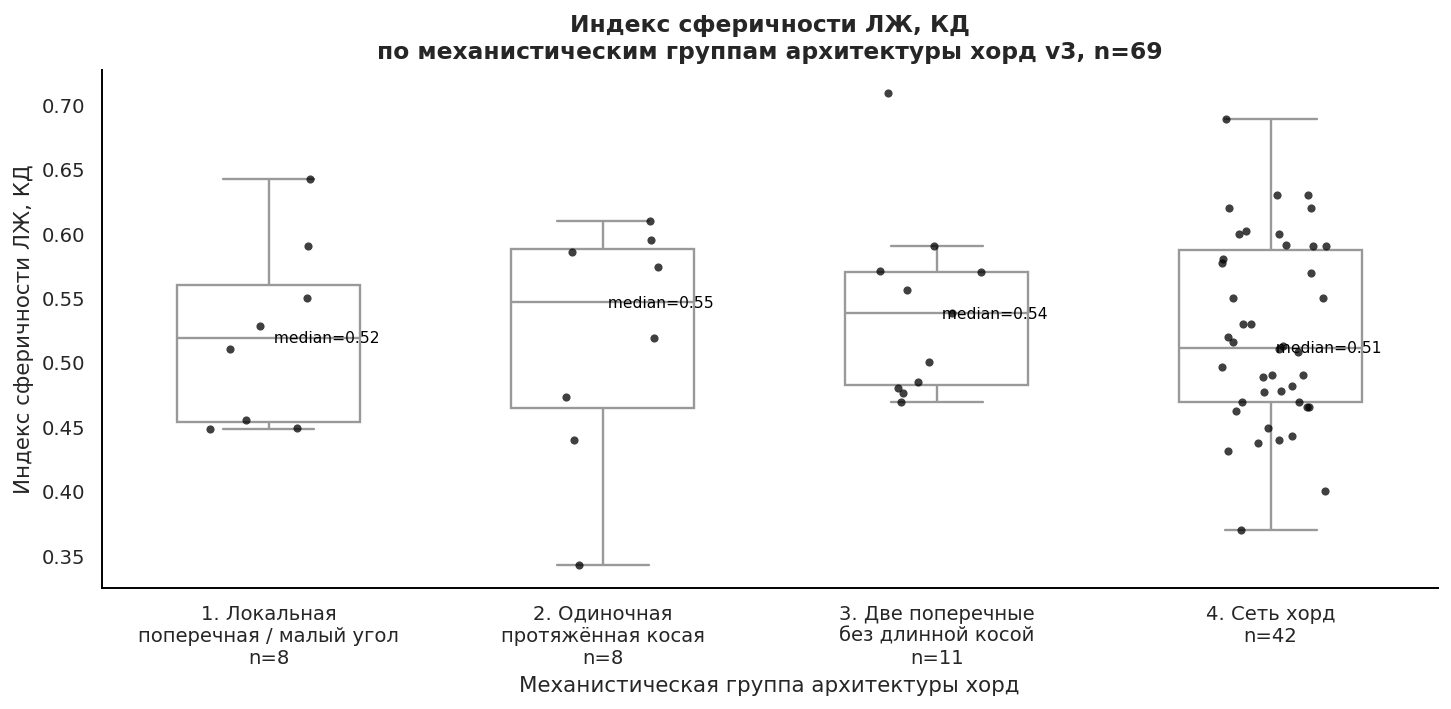

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_echo_lv_sphericity_index_end_systolic_ratio_by_chord_architecture.png


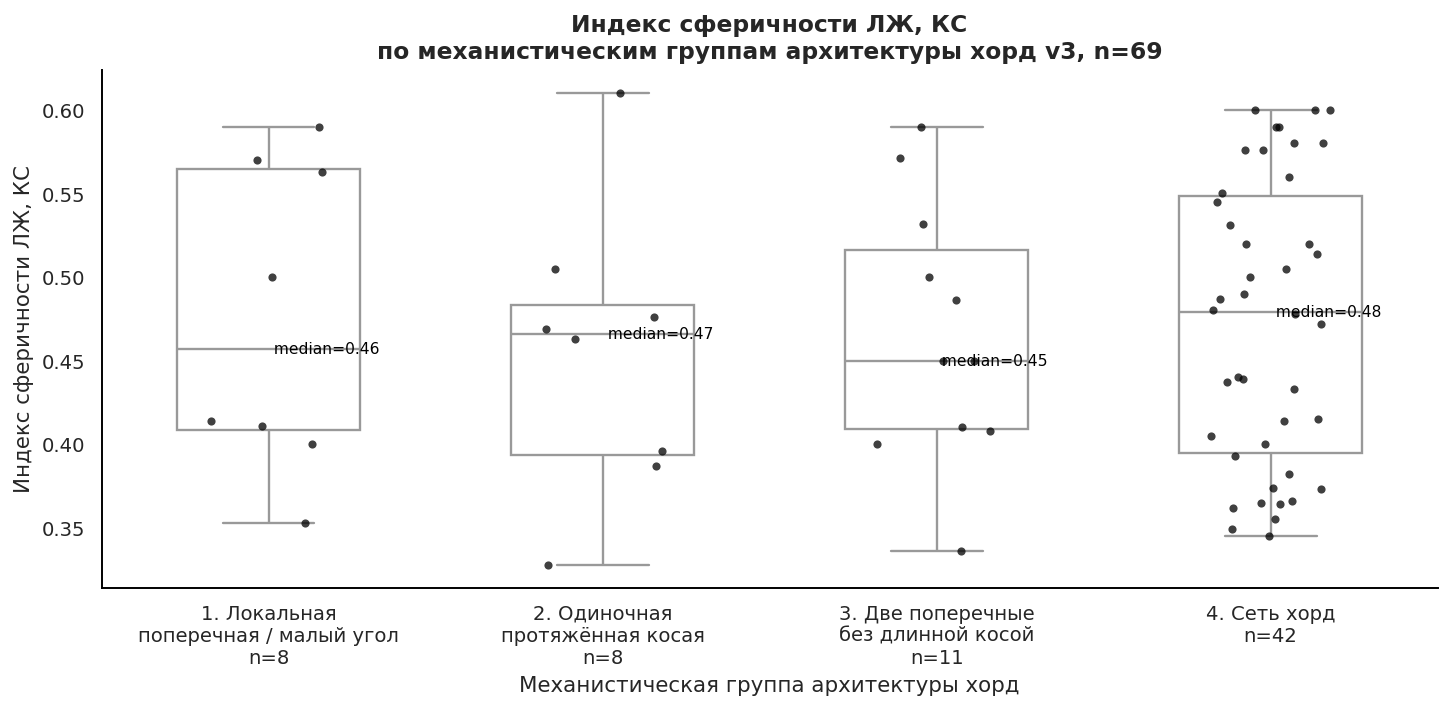

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_echo_lv_myocardial_mass_index_g_m2_by_chord_architecture.png


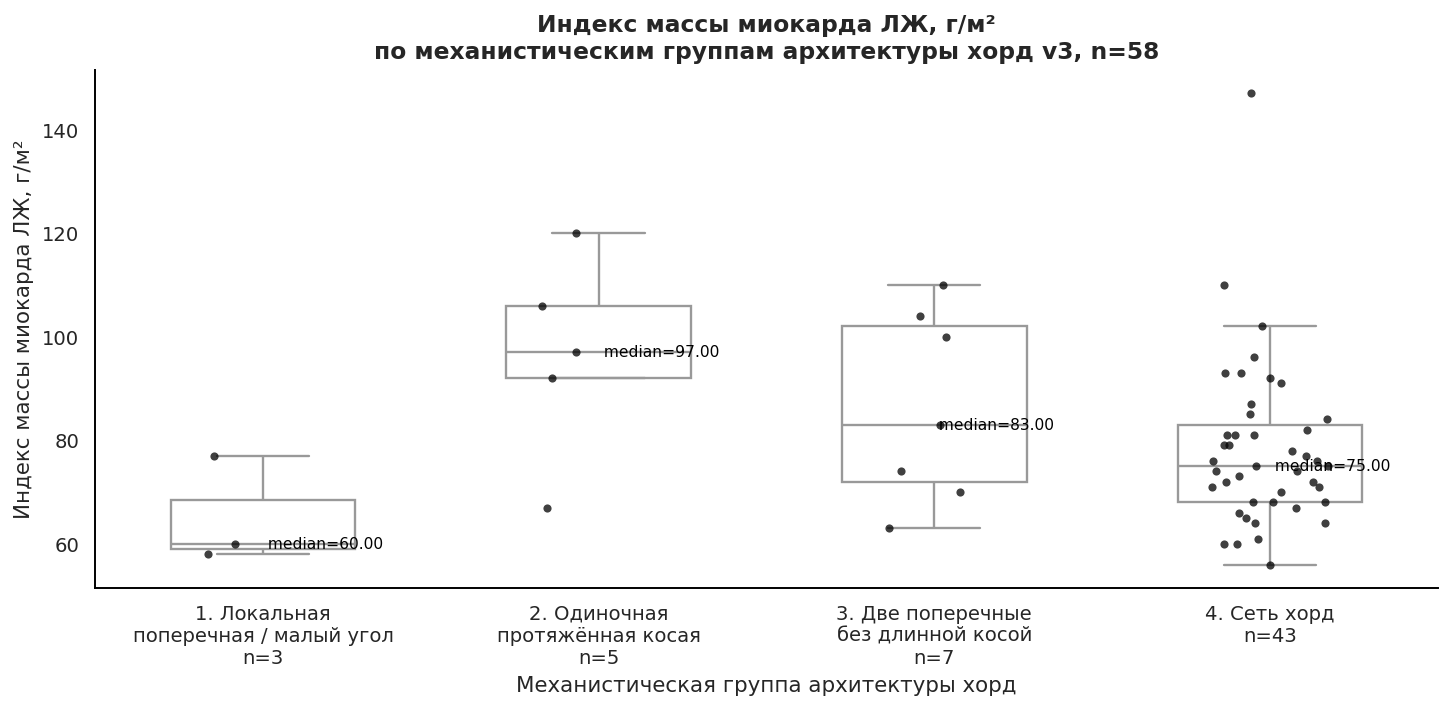

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_echo_lv_sws_delta_g_cm2_by_chord_architecture.png


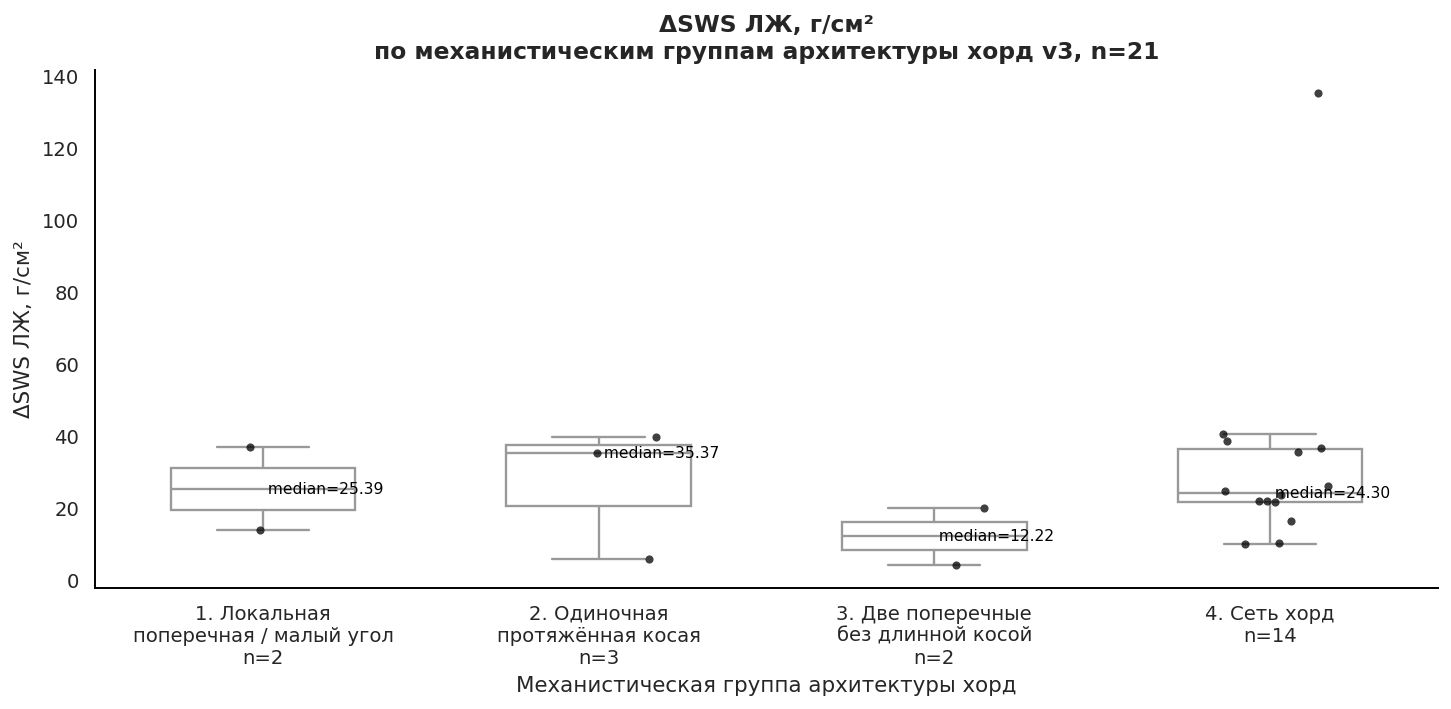

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_merged_lv_deformation_cv_pct_by_chord_architecture.png


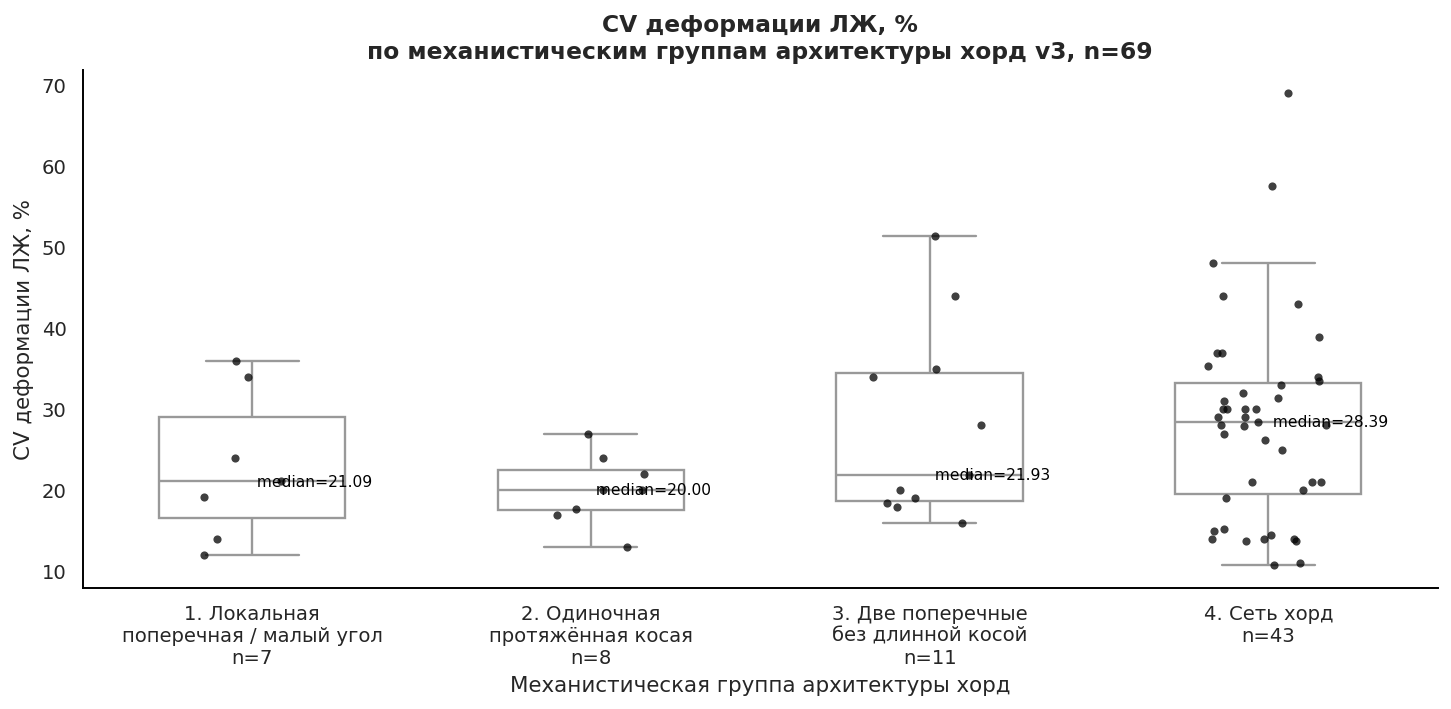

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_dicor_sm_kdtr_cv_pct_by_chord_architecture.png


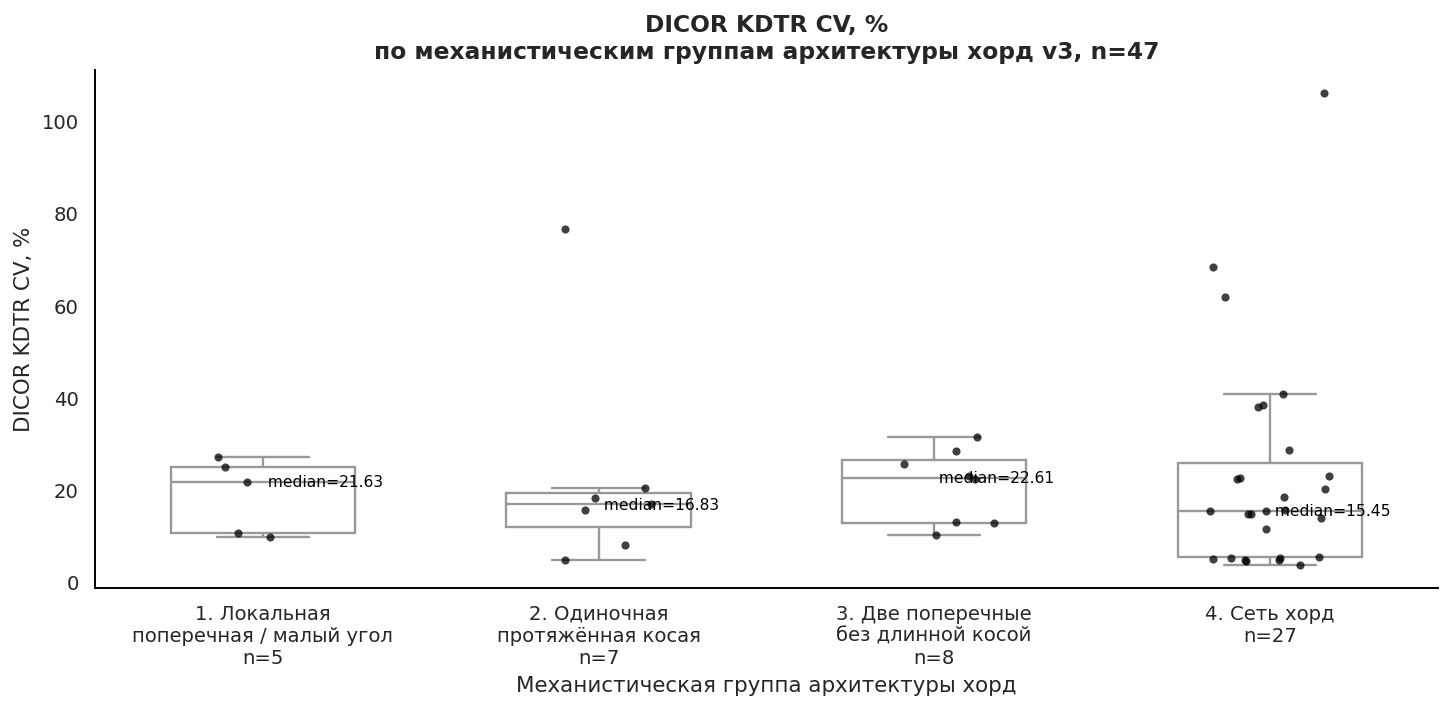

In [9]:
# ============================================================
# Academic boxplot + stripplot for each outcome
# ============================================================

def plot_outcome_by_architecture_v3(data, outcome, save=True):
    temp = data[[ARCH_GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[ARCH_GROUP_COL].isin(ARCH_GROUP_ORDER)]

    if temp.empty:
        print(f"Skipping {outcome}: no data")
        return

    group_n = temp[ARCH_GROUP_COL].value_counts().to_dict()

    xlabels = [
        f"{ARCH_GROUP_LABELS_RU[g]}\nn={group_n.get(g, 0)}"
        for g in ARCH_GROUP_ORDER
    ]

    fig, ax = plt.subplots(figsize=(10.5, 5.2))

    sns.boxplot(
        data=temp,
        x=ARCH_GROUP_COL,
        y=outcome,
        order=ARCH_GROUP_ORDER,
        color="white",
        width=0.55,
        fliersize=0,
        linewidth=1.2,
        ax=ax,
    )

    sns.stripplot(
        data=temp,
        x=ARCH_GROUP_COL,
        y=outcome,
        order=ARCH_GROUP_ORDER,
        color="black",
        size=4.2,
        jitter=0.18,
        alpha=0.75,
        ax=ax,
    )

    medians = temp.groupby(ARCH_GROUP_COL)[outcome].median()

    for i, g in enumerate(ARCH_GROUP_ORDER):
        if g in medians.index:
            ax.text(
                i,
                medians.loc[g],
                f" median={medians.loc[g]:.2f}",
                va="center",
                ha="left",
                fontsize=8,
                color="black",
            )

    ax.set_xlabel("Механистическая группа архитектуры хорд")
    ax.set_ylabel(OUTCOME_LABELS_RU.get(outcome, outcome))
    ax.set_xticklabels(xlabels)

    ax.set_title(
        f"{OUTCOME_LABELS_RU.get(outcome, outcome)}\n"
        f"по механистическим группам архитектуры хорд v3, n={len(temp)}"
    )

    sns.despine(ax=ax)
    plt.tight_layout()

    if save:
        file_name = f"18_v3_{outcome}_by_chord_architecture.png"
        fig.savefig(FIGURES_DIR / file_name, bbox_inches="tight")
        print("Saved:", FIGURES_DIR / file_name)

    plt.show()


for outcome in existing_outcomes:
    plot_outcome_by_architecture_v3(df, outcome)

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_standardized_outcome_profile.png


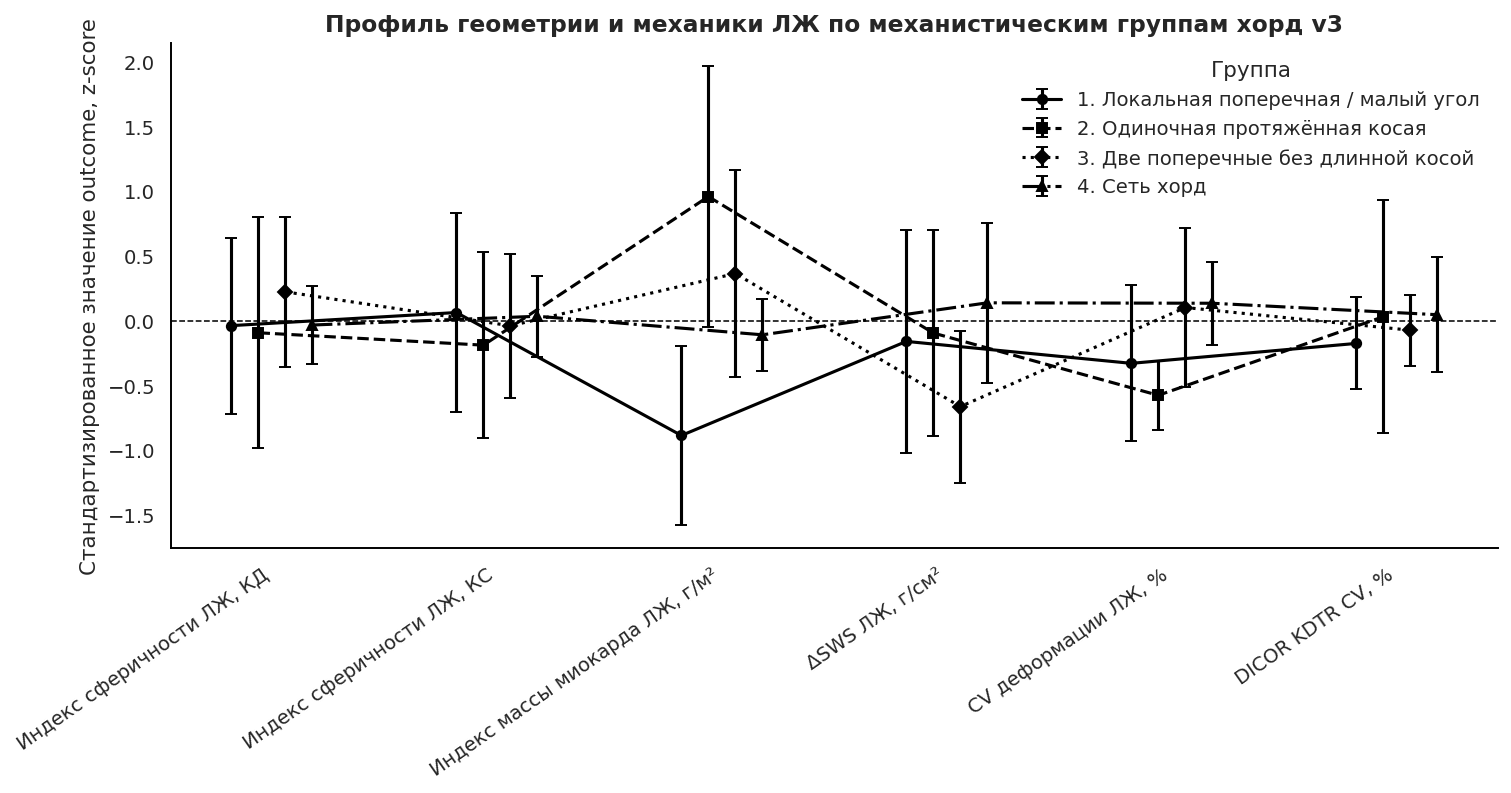

In [10]:
# ============================================================
# Standardized outcome profile by chord architecture v3
# ============================================================

profile_rows = []

for outcome in existing_outcomes:
    temp = df[[ARCH_GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[ARCH_GROUP_COL].isin(ARCH_GROUP_ORDER)]

    if temp.empty or temp[outcome].std(ddof=0) == 0:
        continue

    temp["z_value"] = (temp[outcome] - temp[outcome].mean()) / temp[outcome].std(ddof=0)
    temp["outcome_label_ru"] = OUTCOME_LABELS_RU.get(outcome, outcome)

    grouped = (
        temp
        .groupby([ARCH_GROUP_COL, "outcome_label_ru"])["z_value"]
        .agg(["mean", "sem", "count"])
        .reset_index()
    )

    profile_rows.append(grouped)

profile_v3 = pd.concat(profile_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(11.0, 5.8))

x_labels = list(profile_v3["outcome_label_ru"].drop_duplicates())
x_positions = np.arange(len(x_labels))

offsets = {
    "1_Local_transverse_or_low_angle": -0.18,
    "2_Single_long_oblique_bridge": -0.06,
    "3_Double_transverse_no_long_oblique": 0.06,
    "4_Chord_network": 0.18,
}

markers = {
    "1_Local_transverse_or_low_angle": "o",
    "2_Single_long_oblique_bridge": "s",
    "3_Double_transverse_no_long_oblique": "D",
    "4_Chord_network": "^",
}

linestyles = {
    "1_Local_transverse_or_low_angle": "-",
    "2_Single_long_oblique_bridge": "--",
    "3_Double_transverse_no_long_oblique": ":",
    "4_Chord_network": "-.",
}

for group in ARCH_GROUP_ORDER:
    gdf = profile_v3[profile_v3[ARCH_GROUP_COL] == group].copy()

    y_values = []
    y_errors = []

    for label in x_labels:
        row = gdf[gdf["outcome_label_ru"] == label]

        if row.empty:
            y_values.append(np.nan)
            y_errors.append(np.nan)
        else:
            y_values.append(row["mean"].iloc[0])
            y_errors.append(row["sem"].iloc[0] * 1.96)

    ax.errorbar(
        x_positions + offsets[group],
        y_values,
        yerr=y_errors,
        marker=markers[group],
        linestyle=linestyles[group],
        linewidth=1.6,
        capsize=3,
        color="black",
        label=ARCH_GROUP_LABELS_RU[group].replace("\n", " "),
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=35, ha="right")

ax.set_ylabel("Стандартизированное значение outcome, z-score")
ax.set_xlabel("")
ax.set_title("Профиль геометрии и механики ЛЖ по механистическим группам хорд v3")

ax.legend(title="Группа", loc="best")
sns.despine(ax=ax)

plt.tight_layout()

file_name = "18_v3_standardized_outcome_profile.png"
fig.savefig(FIGURES_DIR / file_name, bbox_inches="tight")
print("Saved:", FIGURES_DIR / file_name)

plt.show()

In [11]:
# ============================================================
# Robust OLS models: chord architecture v3 vs outcomes
# ============================================================

model_rows = []

REFERENCE_GROUP = "1_Local_transverse_or_low_angle"

for outcome in existing_outcomes:
    temp = df[[ARCH_GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[ARCH_GROUP_COL].isin(ARCH_GROUP_ORDER)]

    # Need at least two groups and enough observations
    if temp[ARCH_GROUP_COL].nunique() < 2 or len(temp) < 10:
        continue

    temp[ARCH_GROUP_COL] = pd.Categorical(
        temp[ARCH_GROUP_COL],
        categories=ARCH_GROUP_ORDER,
        ordered=True,
    )

    formula = (
        f"{outcome} ~ "
        f"C({ARCH_GROUP_COL}, Treatment(reference='{REFERENCE_GROUP}'))"
    )

    model = smf.ols(formula, data=temp).fit(cov_type="HC3")

    for term in model.params.index:
        if term == "Intercept":
            continue

        model_rows.append({
            "outcome": outcome,
            "outcome_label_ru": OUTCOME_LABELS_RU.get(outcome, outcome),
            "n": int(model.nobs),
            "reference_group": REFERENCE_GROUP,
            "term": term,
            "coef": model.params[term],
            "p_value_hc3": model.pvalues[term],
            "ci_low_hc3": model.conf_int().loc[term, 0],
            "ci_high_hc3": model.conf_int().loc[term, 1],
            "r2": model.rsquared,
            "adj_r2": model.rsquared_adj,
        })

models_v3 = pd.DataFrame(model_rows)

display(models_v3.sort_values("p_value_hc3"))

models_v3.to_excel(
    TABLES_DIR / "18_chord_architecture_v3_robust_ols_models.xlsx",
    index=False
)

,outcome,outcome_label_ru,n,reference_group,term,coef,p_value_hc3,ci_low_hc3,ci_high_hc3,r2,adj_r2
6,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",58,1_Local_transverse_or_low_angle,"C(chord_architecture_v3, Treatment(reference='...",31.400000,0.010436,7.369451,55.430549,0.144757,0.097244
7,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",58,1_Local_transverse_or_low_angle,"C(chord_architecture_v3, Treatment(reference='...",21.285714,0.043332,0.637689,41.933740,0.144757,0.097244
8,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",58,1_Local_transverse_or_low_angle,"C(chord_architecture_v3, Treatment(reference='...",13.232558,0.088882,-2.011646,28.476763,0.144757,0.097244
14,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",69,1_Local_transverse_or_low_angle,"C(chord_architecture_v3, Treatment(reference='...",5.277530,0.210724,-2.987055,13.542115,0.062493,0.019223
13,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",69,1_Local_transverse_or_low_angle,"C(chord_architecture_v3, Treatment(reference='...",4.902817,0.356613,-5.521291,15.326926,0.062493,0.019223
17,dicor_sm_kdtr_cv_pct,"DICOR KDTR CV, %",47,1_Local_transverse_or_low_angle,"C(chord_architecture_v3, Treatment(reference='...",4.444106,0.470156,-7.616249,16.504462,0.005570,-0.063809
12,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",69,1_Local_transverse_or_low_angle,"C(chord_architecture_v3, Treatment(reference='...",-2.806973,0.494782,-10.865235,5.251289,0.062493,0.019223
10,echo_lv_sws_delta_g_cm2,"ΔSWS ЛЖ, г/см²",21,1_Local_transverse_or_low_angle,"C(chord_architecture_v3, Treatment(reference='...",-13.171811,0.503817,-51.790265,25.446643,0.058413,-0.107749
1,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД",69,1_Local_transverse_or_low_angle,"C(chord_architecture_v3, Treatment(reference='...",0.018864,0.589978,-0.049747,0.087474,0.009772,-0.035931
3,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС",69,1_Local_transverse_or_low_angle,"C(chord_architecture_v3, Treatment(reference='...",-0.020875,0.660094,-0.113908,0.072158,0.005563,-0.040334


In [12]:
# ============================================================
# Auto-generated interpretation notes
# ============================================================

lines = []

lines.append("# Interpretation notes: chord architecture v3\n")

lines.append("## Group counts\n")
counts = (
    df[ARCH_GROUP_COL]
    .value_counts(dropna=False)
    .rename_axis("group")
    .reset_index(name="n")
)

for _, row in counts.iterrows():
    lines.append(f"- {row['group']}: n = {row['n']}")

lines.append("\n## Outcome availability\n")
for _, row in availability_v3.iterrows():
    outcome_label = row["outcome_label_ru"]
    lines.append(f"\n### {outcome_label}")
    lines.append(f"- total n = {row['n_total']}")
    for g in ARCH_GROUP_ORDER:
        lines.append(f"- {g}: n = {row.get(g, 0)}")

lines.append("\n## Kruskal-Wallis screening\n")
if not kw_v3.empty:
    for _, row in kw_v3.sort_values("kruskal_p").iterrows():
        lines.append(
            f"- {row['outcome_label_ru']} (`{row['outcome']}`): "
            f"n = {int(row['n'])}, H = {row['kruskal_h']:.3f}, "
            f"p = {row['kruskal_p']:.4f}"
        )

lines.append("\n## Methodological note\n")
lines.append(
    "This is an exploratory mechanistic classification. "
    "Unclassified cases were not automatically assigned to the network group. "
    "Pure apical topology was excluded according to the current working rule. "
    "If some groups have very small n, they should be interpreted descriptively rather than confirmatorily."
)

interpretation_text = "\n".join(lines)

print(interpretation_text)

with open(
    TABLES_DIR / "18_chord_architecture_v3_interpretation_notes.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(interpretation_text)

# Interpretation notes: chord architecture v3

## Group counts

- nan: n = 64
- 4_Chord_network: n = 62
- 3_Double_transverse_no_long_oblique: n = 11
- 2_Single_long_oblique_bridge: n = 8
- 1_Local_transverse_or_low_angle: n = 8

## Outcome availability


### Индекс сферичности ЛЖ, КД
- total n = 69
- 1_Local_transverse_or_low_angle: n = 8
- 2_Single_long_oblique_bridge: n = 8
- 3_Double_transverse_no_long_oblique: n = 11
- 4_Chord_network: n = 42

### Индекс сферичности ЛЖ, КС
- total n = 69
- 1_Local_transverse_or_low_angle: n = 8
- 2_Single_long_oblique_bridge: n = 8
- 3_Double_transverse_no_long_oblique: n = 11
- 4_Chord_network: n = 42

### Индекс массы миокарда ЛЖ, г/м²
- total n = 58
- 1_Local_transverse_or_low_angle: n = 3
- 2_Single_long_oblique_bridge: n = 5
- 3_Double_transverse_no_long_oblique: n = 7
- 4_Chord_network: n = 43

### ΔSWS ЛЖ, г/см²
- total n = 21
- 1_Local_transverse_or_low_angle: n = 2
- 2_Single_long_oblique_bridge: n = 3
- 3_Double_transverse_no_long_obliqu

In [13]:
# ============================================================
# ANOVA block for chord architecture v3
# Classical ANOVA + Welch ANOVA + Kruskal-Wallis + post-hoc
# ============================================================

import numpy as np
import pandas as pd

from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

GROUP_COL = "chord_architecture_v3"

GROUP_ORDER = [
    "1_Local_transverse_or_low_angle",
    "2_Single_long_oblique_bridge",
    "3_Double_transverse_no_long_oblique",
    "4_Chord_network",
]

GROUP_LABELS_RU = {
    "1_Local_transverse_or_low_angle": "1. Локальная поперечная / малый угол",
    "2_Single_long_oblique_bridge": "2. Одиночная протяжённая косая",
    "3_Double_transverse_no_long_oblique": "3. Две поперечные без длинной косой",
    "4_Chord_network": "4. Сеть хорд",
}

OUTCOMES = [
    "echo_lv_sphericity_index_end_diastolic_ratio",
    "echo_lv_sphericity_index_end_systolic_ratio",
    "echo_lv_myocardial_mass_index_g_m2",
    "echo_lv_sws_delta_g_cm2",
    "merged_lv_deformation_cv_pct",
    "dicor_sm_kdtr_cv_pct",
]

OUTCOME_LABELS_RU = {
    "echo_lv_sphericity_index_end_diastolic_ratio": "Индекс сферичности ЛЖ, КД",
    "echo_lv_sphericity_index_end_systolic_ratio": "Индекс сферичности ЛЖ, КС",
    "echo_lv_myocardial_mass_index_g_m2": "Индекс массы миокарда ЛЖ, г/м²",
    "echo_lv_sws_delta_g_cm2": "ΔSWS ЛЖ, г/см²",
    "merged_lv_deformation_cv_pct": "CV деформации ЛЖ, %",
    "dicor_sm_kdtr_cv_pct": "DICOR KDTR CV, %",
}

existing_outcomes = [c for c in OUTCOMES if c in df.columns]

for col in existing_outcomes:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def eta_squared_from_anova_table(anova_table):
    """
    Eta squared = SS_between / SS_total.
    """
    try:
        ss_between = anova_table.loc[f"C({GROUP_COL})", "sum_sq"]
        ss_resid = anova_table.loc["Residual", "sum_sq"]
        return ss_between / (ss_between + ss_resid)
    except Exception:
        return np.nan


def omega_squared_from_anova_table(anova_table):
    """
    Omega squared = (SS_between - df_between * MS_error) / (SS_total + MS_error).
    More conservative than eta squared.
    """
    try:
        ss_between = anova_table.loc[f"C({GROUP_COL})", "sum_sq"]
        df_between = anova_table.loc[f"C({GROUP_COL})", "df"]
        ss_resid = anova_table.loc["Residual", "sum_sq"]
        df_resid = anova_table.loc["Residual", "df"]
        ms_error = ss_resid / df_resid
        ss_total = ss_between + ss_resid

        omega = (ss_between - df_between * ms_error) / (ss_total + ms_error)
        return max(omega, 0)
    except Exception:
        return np.nan


def pairwise_welch_holm(data, outcome, group_col=GROUP_COL):
    """
    Pairwise Welch t-tests with Holm correction.
    Useful when group sizes and variances are unequal.
    """
    rows = []

    groups = [
        g for g in GROUP_ORDER
        if g in data[group_col].dropna().unique()
    ]

    for i, g1 in enumerate(groups):
        for g2 in groups[i + 1:]:
            x = data.loc[data[group_col] == g1, outcome].dropna()
            y = data.loc[data[group_col] == g2, outcome].dropna()

            if len(x) >= 2 and len(y) >= 2:
                t_stat, p_val = stats.ttest_ind(x, y, equal_var=False, nan_policy="omit")
                mean_diff = y.mean() - x.mean()
                median_diff = y.median() - x.median()
            else:
                t_stat, p_val, mean_diff, median_diff = np.nan, np.nan, np.nan, np.nan

            rows.append({
                "outcome": outcome,
                "outcome_label_ru": OUTCOME_LABELS_RU.get(outcome, outcome),
                "group_1": g1,
                "group_2": g2,
                "group_1_label_ru": GROUP_LABELS_RU.get(g1, g1),
                "group_2_label_ru": GROUP_LABELS_RU.get(g2, g2),
                "n_1": len(x),
                "n_2": len(y),
                "mean_1": x.mean() if len(x) else np.nan,
                "mean_2": y.mean() if len(y) else np.nan,
                "mean_diff_group2_minus_group1": mean_diff,
                "median_1": x.median() if len(x) else np.nan,
                "median_2": y.median() if len(y) else np.nan,
                "median_diff_group2_minus_group1": median_diff,
                "welch_t": t_stat,
                "p_uncorrected": p_val,
            })

    out = pd.DataFrame(rows)

    if not out.empty and out["p_uncorrected"].notna().sum() > 0:
        mask = out["p_uncorrected"].notna()
        corrected = multipletests(
            out.loc[mask, "p_uncorrected"],
            alpha=0.05,
            method="holm"
        )
        out.loc[mask, "p_holm"] = corrected[1]
        out.loc[mask, "reject_holm_0_05"] = corrected[0]

    return out


# ------------------------------------------------------------
# Main ANOVA loop
# ------------------------------------------------------------

anova_rows = []
descriptive_rows = []
posthoc_tukey_rows = []
posthoc_welch_rows = []

for outcome in existing_outcomes:
    temp = df[[GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[GROUP_COL].isin(GROUP_ORDER)]

    if temp.empty:
        continue

    # Keep only groups with at least 2 observations for tests
    group_counts = temp[GROUP_COL].value_counts()
    valid_groups = group_counts[group_counts >= 2].index.tolist()
    temp_test = temp[temp[GROUP_COL].isin(valid_groups)].copy()

    # Descriptive table
    desc = (
        temp
        .groupby(GROUP_COL)[outcome]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )
    desc["outcome"] = outcome
    desc["outcome_label_ru"] = OUTCOME_LABELS_RU.get(outcome, outcome)
    desc["group_label_ru"] = desc[GROUP_COL].map(GROUP_LABELS_RU)
    descriptive_rows.append(desc)

    if temp_test[GROUP_COL].nunique() < 2:
        anova_rows.append({
            "outcome": outcome,
            "outcome_label_ru": OUTCOME_LABELS_RU.get(outcome, outcome),
            "n_total": len(temp),
            "n_groups_total": temp[GROUP_COL].nunique(),
            "n_groups_tested": temp_test[GROUP_COL].nunique(),
            "note": "Not enough groups with n>=2",
        })
        continue

    arrays = [
        temp_test.loc[temp_test[GROUP_COL] == g, outcome].dropna()
        for g in valid_groups
    ]

    # ----------------------------
    # Levene test for equal variances
    # ----------------------------
    try:
        levene_stat, levene_p = stats.levene(*arrays, center="median")
    except Exception:
        levene_stat, levene_p = np.nan, np.nan

    # ----------------------------
    # Shapiro by group, only as diagnostic
    # ----------------------------
    shapiro_min_p = np.nan
    shapiro_notes = []

    for g in valid_groups:
        vals = temp_test.loc[temp_test[GROUP_COL] == g, outcome].dropna()

        if 3 <= len(vals) <= 5000:
            try:
                _, p_shap = stats.shapiro(vals)
                shapiro_notes.append(f"{g}: p={p_shap:.3f}")
            except Exception:
                pass

    if len(shapiro_notes) > 0:
        p_values = []
        for item in shapiro_notes:
            try:
                p_values.append(float(item.split("p=")[1]))
            except Exception:
                pass
        if len(p_values) > 0:
            shapiro_min_p = min(p_values)

    # ----------------------------
    # Classical one-way ANOVA
    # ----------------------------
    try:
        model = smf.ols(f"{outcome} ~ C({GROUP_COL})", data=temp_test).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        classical_f = anova_table.loc[f"C({GROUP_COL})", "F"]
        classical_p = anova_table.loc[f"C({GROUP_COL})", "PR(>F)"]
        eta2 = eta_squared_from_anova_table(anova_table)
        omega2 = omega_squared_from_anova_table(anova_table)

    except Exception:
        classical_f, classical_p, eta2, omega2 = np.nan, np.nan, np.nan, np.nan

    # ----------------------------
    # Welch ANOVA
    # ----------------------------
    try:
        welch = anova_oneway(
            temp_test[outcome].values,
            groups=temp_test[GROUP_COL].values,
            use_var="unequal",
        )

        welch_stat = welch.statistic
        welch_p = welch.pvalue
        welch_df_num = welch.df[0]
        welch_df_denom = welch.df[1]

    except Exception:
        welch_stat, welch_p, welch_df_num, welch_df_denom = np.nan, np.nan, np.nan, np.nan

    # ----------------------------
    # Kruskal-Wallis
    # ----------------------------
    try:
        kruskal_h, kruskal_p = stats.kruskal(*arrays)
    except Exception:
        kruskal_h, kruskal_p = np.nan, np.nan

    # ----------------------------
    # Save row
    # ----------------------------
    row = {
        "outcome": outcome,
        "outcome_label_ru": OUTCOME_LABELS_RU.get(outcome, outcome),
        "n_total": len(temp),
        "n_tested": len(temp_test),
        "n_groups_total": temp[GROUP_COL].nunique(),
        "n_groups_tested": temp_test[GROUP_COL].nunique(),

        "levene_stat": levene_stat,
        "levene_p": levene_p,
        "shapiro_min_p_by_group": shapiro_min_p,
        "shapiro_notes": "; ".join(shapiro_notes),

        "classical_anova_f": classical_f,
        "classical_anova_p": classical_p,
        "eta_squared": eta2,
        "omega_squared": omega2,

        "welch_anova_f": welch_stat,
        "welch_anova_p": welch_p,
        "welch_df_num": welch_df_num,
        "welch_df_denom": welch_df_denom,

        "kruskal_h": kruskal_h,
        "kruskal_p": kruskal_p,
    }

    # Add group n columns
    for g in GROUP_ORDER:
        row[f"n_{g}"] = int(group_counts.get(g, 0))

    anova_rows.append(row)

    # ----------------------------
    # Tukey post-hoc, classical
    # ----------------------------
    try:
        tukey = pairwise_tukeyhsd(
            endog=temp_test[outcome],
            groups=temp_test[GROUP_COL],
            alpha=0.05,
        )

        tukey_df = pd.DataFrame(
            data=tukey.summary().data[1:],
            columns=tukey.summary().data[0],
        )

        tukey_df["outcome"] = outcome
        tukey_df["outcome_label_ru"] = OUTCOME_LABELS_RU.get(outcome, outcome)

        posthoc_tukey_rows.append(tukey_df)

    except Exception:
        pass

    # ----------------------------
    # Pairwise Welch + Holm
    # ----------------------------
    pw = pairwise_welch_holm(temp_test, outcome, group_col=GROUP_COL)
    posthoc_welch_rows.append(pw)


# ------------------------------------------------------------
# Combine outputs
# ------------------------------------------------------------

anova_results = pd.DataFrame(anova_rows)

descriptive_anova = (
    pd.concat(descriptive_rows, ignore_index=True)
    if len(descriptive_rows) > 0
    else pd.DataFrame()
)

posthoc_tukey = (
    pd.concat(posthoc_tukey_rows, ignore_index=True)
    if len(posthoc_tukey_rows) > 0
    else pd.DataFrame()
)

posthoc_welch = (
    pd.concat(posthoc_welch_rows, ignore_index=True)
    if len(posthoc_welch_rows) > 0
    else pd.DataFrame()
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("Descriptive statistics:")
display(descriptive_anova)

print("\nANOVA results:")
display(
    anova_results
    .sort_values("welch_anova_p", na_position="last")
)

print("\nTukey post-hoc:")
display(posthoc_tukey)

print("\nPairwise Welch + Holm:")
display(
    posthoc_welch
    .sort_values("p_holm", na_position="last")
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

descriptive_anova.to_excel(
    TABLES_DIR / "18_v3_anova_descriptive_stats.xlsx",
    index=False
)

anova_results.to_excel(
    TABLES_DIR / "18_v3_anova_results_classical_welch_kruskal.xlsx",
    index=False
)

posthoc_tukey.to_excel(
    TABLES_DIR / "18_v3_anova_posthoc_tukey.xlsx",
    index=False
)

posthoc_welch.to_excel(
    TABLES_DIR / "18_v3_anova_posthoc_pairwise_welch_holm.xlsx",
    index=False
)

print("\nSaved ANOVA outputs to:", TABLES_DIR)  

Descriptive statistics:


,chord_architecture_v3,count,mean,std,median,min,max,outcome,outcome_label_ru,group_label_ru
0,1_Local_transverse_or_low_angle,8,0.521500,0.070993,0.519000,0.448000,0.642000,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД",1. Локальная поперечная / малый угол
1,2_Single_long_oblique_bridge,8,0.517500,0.093263,0.546500,0.343000,0.610000,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД",2. Одиночная протяжённая косая
2,3_Double_transverse_no_long_oblique,11,0.540364,0.071093,0.538000,0.469000,0.709000,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД",3. Две поперечные без длинной косой
3,4_Chord_network,42,0.521833,0.071676,0.511500,0.370000,0.689000,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД",4. Сеть хорд
4,1_Local_transverse_or_low_angle,8,0.475125,0.091764,0.457000,0.353000,0.590000,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС",1. Локальная поперечная / малый угол
5,2_Single_long_oblique_bridge,8,0.454250,0.085737,0.466000,0.328000,0.610000,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС",2. Одиночная протяжённая косая
6,3_Double_transverse_no_long_oblique,11,0.466636,0.077831,0.450000,0.336000,0.590000,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС",3. Две поперечные без длинной косой
7,4_Chord_network,42,0.472738,0.085505,0.479000,0.345000,0.600000,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС",4. Сеть хорд
8,1_Local_transverse_or_low_angle,3,65.000000,10.440307,60.000000,58.000000,77.000000,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",1. Локальная поперечная / малый угол
9,2_Single_long_oblique_bridge,5,96.400000,19.578049,97.000000,67.000000,120.000000,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",2. Одиночная протяжённая косая



ANOVA results:


,outcome,outcome_label_ru,n_total,n_tested,n_groups_total,n_groups_tested,levene_stat,levene_p,shapiro_min_p_by_group,shapiro_notes,...,welch_anova_f,welch_anova_p,welch_df_num,welch_df_denom,kruskal_h,kruskal_p,n_1_Local_transverse_or_low_angle,n_2_Single_long_oblique_bridge,n_3_Double_transverse_no_long_oblique,n_4_Chord_network
4,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",69,69,4,4,1.315664,0.276877,0.005,4_Chord_network: p=0.005; 3_Double_transverse_...,...,3.924067,0.024905,3.0,18.664863,4.322468,0.228683,7,8,11,43
2,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",58,58,4,4,0.554395,0.647411,0.000,4_Chord_network: p=0.000; 3_Double_transverse_...,...,2.904220,0.114784,3.0,6.657206,7.861083,0.048972,3,5,7,43
3,echo_lv_sws_delta_g_cm2,"ΔSWS ЛЖ, г/см²",21,21,4,4,0.063955,0.978190,0.000,4_Chord_network: p=0.000; 2_Single_long_obliqu...,...,0.854784,0.543318,3.0,3.326080,2.847248,0.415781,2,3,2,14
0,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД",69,69,4,4,0.381271,0.766821,0.063,4_Chord_network: p=0.498; 3_Double_transverse_...,...,0.204987,0.891467,3.0,16.384509,0.364922,0.947390,8,8,11,42
5,dicor_sm_kdtr_cv_pct,"DICOR KDTR CV, %",47,47,4,4,0.659519,0.581467,0.000,4_Chord_network: p=0.000; 3_Double_transverse_...,...,0.197792,0.896218,3.0,14.604270,0.767934,0.857120,5,7,8,27
1,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС",69,69,4,4,0.552318,0.648406,0.006,4_Chord_network: p=0.006; 3_Double_transverse_...,...,0.110490,0.952776,3.0,16.781133,0.384806,0.943363,8,8,11,42



Tukey post-hoc:


,group1,group2,meandiff,p-adj,lower,upper,reject,outcome,outcome_label_ru
0,1_Local_transverse_or_low_angle,2_Single_long_oblique_bridge,-0.0040,0.9995,-0.1018,0.0938,False,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД"
1,1_Local_transverse_or_low_angle,3_Double_transverse_no_long_oblique,0.0189,0.9469,-0.0720,0.1097,False,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД"
2,1_Local_transverse_or_low_angle,4_Chord_network,0.0003,1.0000,-0.0751,0.0758,False,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД"
3,2_Single_long_oblique_bridge,3_Double_transverse_no_long_oblique,0.0229,0.9103,-0.0680,0.1137,False,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД"
4,2_Single_long_oblique_bridge,4_Chord_network,0.0043,0.9987,-0.0711,0.0798,False,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД"
5,3_Double_transverse_no_long_oblique,4_Chord_network,-0.0185,0.8815,-0.0847,0.0477,False,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД"
6,1_Local_transverse_or_low_angle,2_Single_long_oblique_bridge,-0.0209,0.9609,-0.1331,0.0913,False,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС"
7,1_Local_transverse_or_low_angle,3_Double_transverse_no_long_oblique,-0.0085,0.9965,-0.1128,0.0958,False,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС"
8,1_Local_transverse_or_low_angle,4_Chord_network,-0.0024,0.9999,-0.0889,0.0842,False,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС"
9,2_Single_long_oblique_bridge,3_Double_transverse_no_long_oblique,0.0124,0.9893,-0.0919,0.1167,False,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС"



Pairwise Welch + Holm:


,outcome,outcome_label_ru,group_1,group_2,group_1_label_ru,group_2_label_ru,n_1,n_2,mean_1,mean_2,mean_diff_group2_minus_group1,median_1,median_2,median_diff_group2_minus_group1,welch_t,p_uncorrected,p_holm,reject_holm_0_05
28,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",2_Single_long_oblique_bridge,4_Chord_network,2. Одиночная протяжённая косая,4. Сеть хорд,8,43,20.085696,28.170199,8.084503,20.000000,28.392743,8.392743,-3.340838,0.002160,0.012960,True
12,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",1_Local_transverse_or_low_angle,2_Single_long_oblique_bridge,1. Локальная поперечная / малый угол,2. Одиночная протяжённая косая,3,5,65.000000,96.400000,31.400000,60.000000,97.000000,37.000000,-2.953951,0.025501,0.153005,False
13,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",1_Local_transverse_or_low_angle,3_Double_transverse_no_long_oblique,1. Локальная поперечная / малый угол,3. Две поперечные без длинной косой,3,7,65.000000,86.285714,21.285714,60.000000,83.000000,23.000000,-2.312186,0.054884,0.274420,False
27,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",2_Single_long_oblique_bridge,3_Double_transverse_no_long_oblique,2. Одиночная протяжённая косая,3. Две поперечные без длинной косой,8,11,20.085696,27.795487,7.709790,20.000000,21.934674,1.934674,-1.979804,0.068675,0.343374,False
16,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",2_Single_long_oblique_bridge,4_Chord_network,2. Одиночная протяжённая косая,4. Сеть хорд,5,43,96.400000,78.232558,-18.167442,97.000000,75.000000,-22.000000,1.999991,0.106464,0.425858,False
14,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",1_Local_transverse_or_low_angle,4_Chord_network,1. Локальная поперечная / малый угол,4. Сеть хорд,3,43,65.000000,78.232558,13.232558,60.000000,75.000000,15.000000,-2.037272,0.144725,0.434175,False
17,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",3_Double_transverse_no_long_oblique,4_Chord_network,3. Две поперечные без длинной косой,4. Сеть хорд,7,43,86.285714,78.232558,-8.053156,83.000000,75.000000,-8.000000,1.093169,0.308083,0.616167,False
15,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",2_Single_long_oblique_bridge,3_Double_transverse_no_long_oblique,2. Одиночная протяжённая косая,3. Две поперечные без длинной косой,5,7,96.400000,86.285714,-10.114286,97.000000,83.000000,-14.000000,0.904378,0.390962,0.616167,False
23,echo_lv_sws_delta_g_cm2,"ΔSWS ЛЖ, г/см²",3_Double_transverse_no_long_oblique,4_Chord_network,3. Две поперечные без длинной косой,4. Сеть хорд,2,14,12.218746,33.184682,20.965936,12.218746,24.297298,12.078552,-1.841875,0.137636,0.825815,False
26,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",1_Local_transverse_or_low_angle,4_Chord_network,1. Локальная поперечная / малый угол,4. Сеть хорд,7,43,22.892669,28.170199,5.277530,21.094764,28.392743,7.297980,-1.333276,0.212538,0.850151,False



Saved ANOVA outputs to: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\tables


In [14]:
# ============================================================
# Figures for ANOVA analysis: chord architecture v3
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.15,
)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "figure.figsize": (10, 5),

    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "axes.grid": False,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 12,

    "xtick.direction": "out",
    "ytick.direction": "out",

    "legend.frameon": False,
})

GROUP_COL = "chord_architecture_v3"

GROUP_ORDER = [
    "1_Local_transverse_or_low_angle",
    "2_Single_long_oblique_bridge",
    "3_Double_transverse_no_long_oblique",
    "4_Chord_network",
]

GROUP_LABELS_RU = {
    "1_Local_transverse_or_low_angle": "1. Локальная\nпоперечная / малый угол",
    "2_Single_long_oblique_bridge": "2. Одиночная\nпротяжённая косая",
    "3_Double_transverse_no_long_oblique": "3. Две поперечные\nбез длинной косой",
    "4_Chord_network": "4. Сеть хорд",
}

OUTCOMES = [
    "echo_lv_sphericity_index_end_diastolic_ratio",
    "echo_lv_sphericity_index_end_systolic_ratio",
    "echo_lv_myocardial_mass_index_g_m2",
    "echo_lv_sws_delta_g_cm2",
    "merged_lv_deformation_cv_pct",
    "dicor_sm_kdtr_cv_pct",
]

OUTCOME_LABELS_RU = {
    "echo_lv_sphericity_index_end_diastolic_ratio": "Индекс сферичности ЛЖ, КД",
    "echo_lv_sphericity_index_end_systolic_ratio": "Индекс сферичности ЛЖ, КС",
    "echo_lv_myocardial_mass_index_g_m2": "Индекс массы миокарда ЛЖ, г/м²",
    "echo_lv_sws_delta_g_cm2": "ΔSWS ЛЖ, г/см²",
    "merged_lv_deformation_cv_pct": "CV деформации ЛЖ, %",
    "dicor_sm_kdtr_cv_pct": "DICOR KDTR CV, %",
}

existing_outcomes = [c for c in OUTCOMES if c in df.columns]

for col in existing_outcomes:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Existing outcomes:", existing_outcomes)

Existing outcomes: ['echo_lv_sphericity_index_end_diastolic_ratio', 'echo_lv_sphericity_index_end_systolic_ratio', 'echo_lv_myocardial_mass_index_g_m2', 'echo_lv_sws_delta_g_cm2', 'merged_lv_deformation_cv_pct', 'dicor_sm_kdtr_cv_pct']


Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_box_strip_echo_lv_sphericity_index_end_diastolic_ratio_by_chord_architecture_v3.png


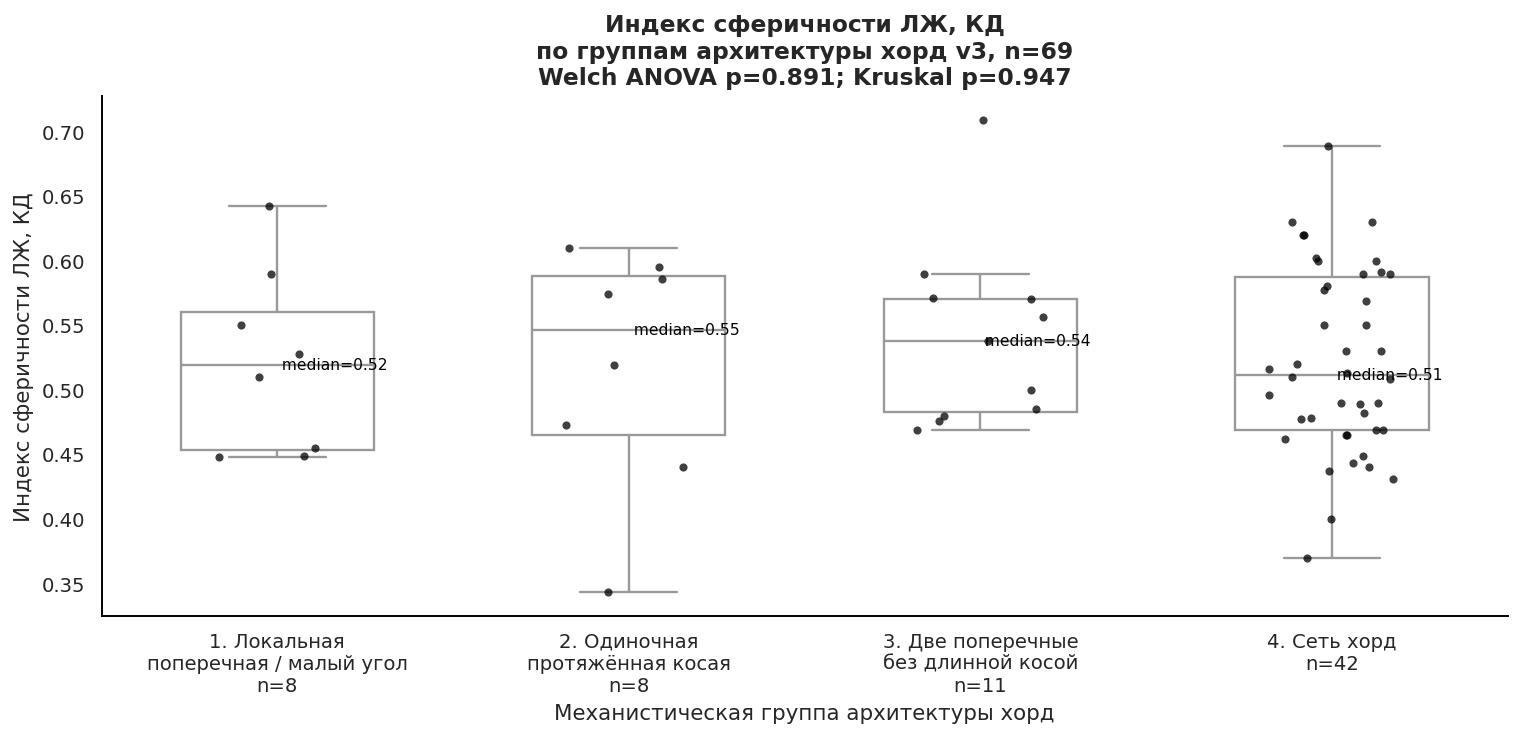

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_box_strip_echo_lv_sphericity_index_end_systolic_ratio_by_chord_architecture_v3.png


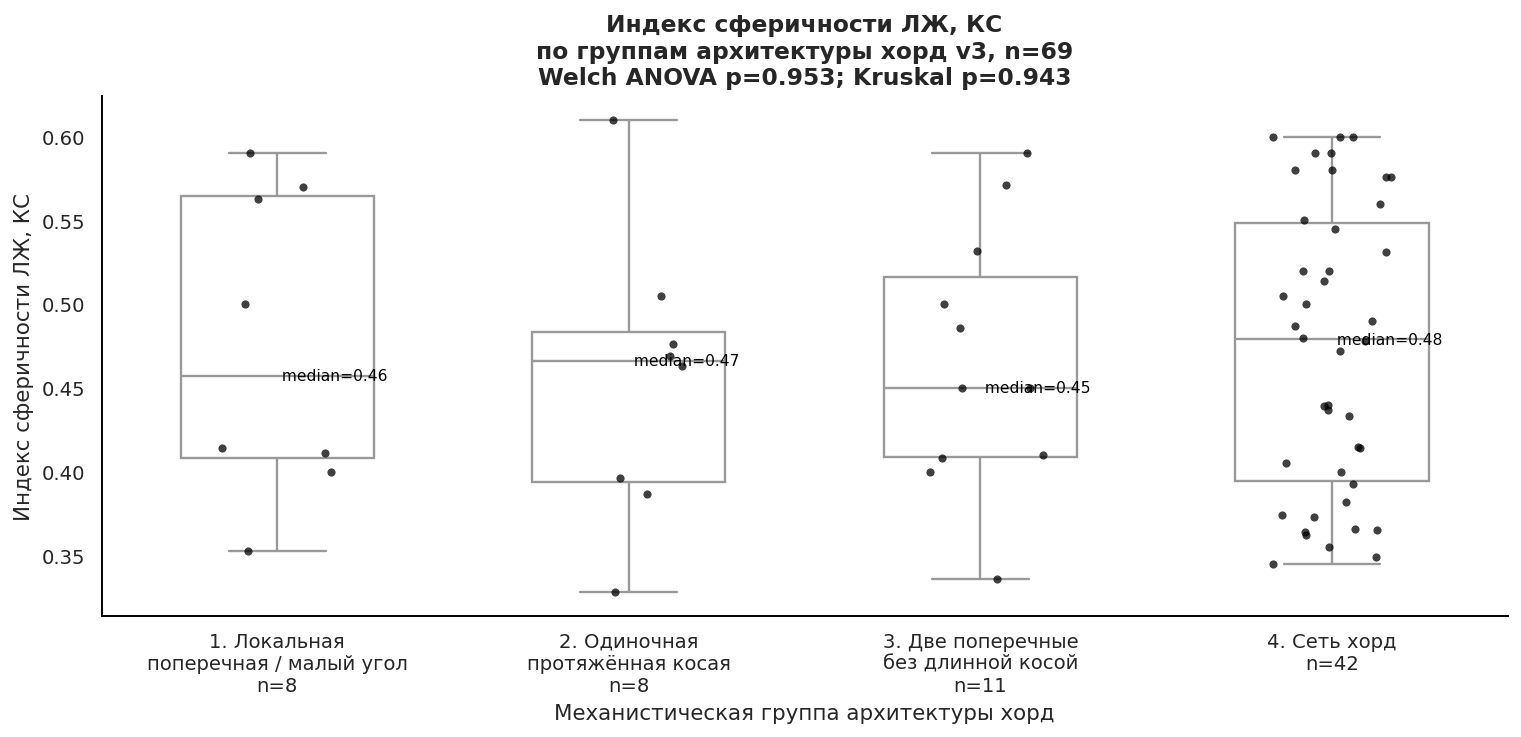

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_box_strip_echo_lv_myocardial_mass_index_g_m2_by_chord_architecture_v3.png


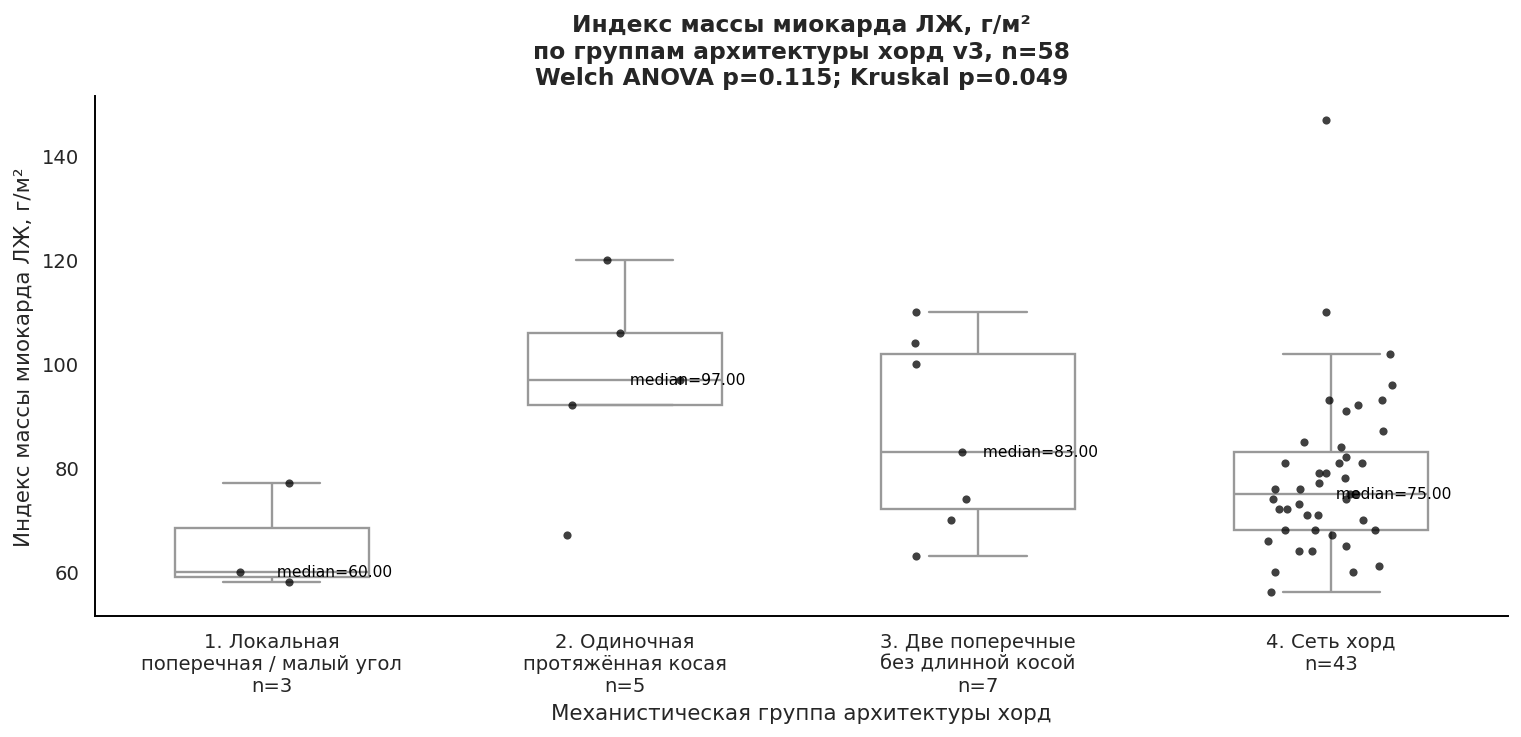

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_box_strip_echo_lv_sws_delta_g_cm2_by_chord_architecture_v3.png


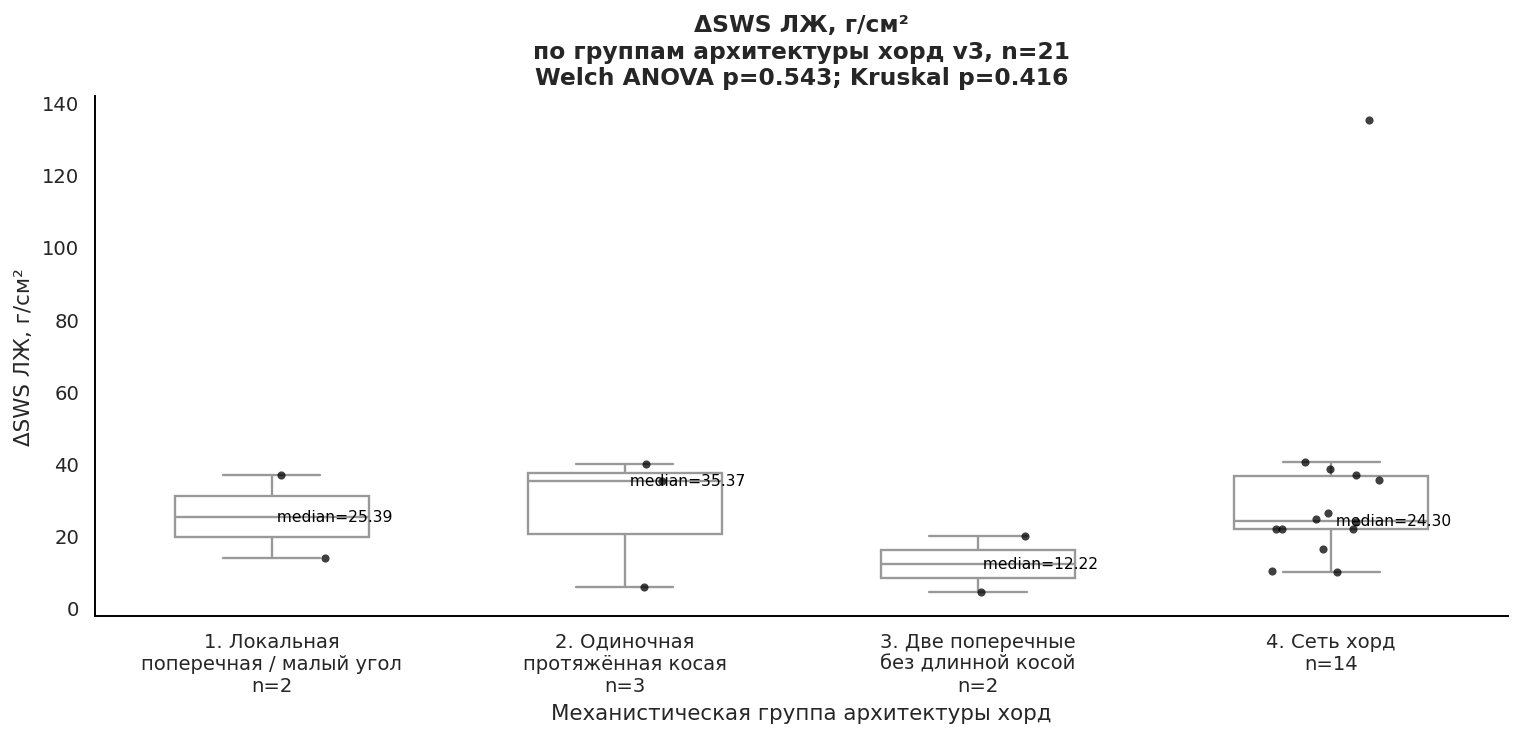

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_box_strip_merged_lv_deformation_cv_pct_by_chord_architecture_v3.png


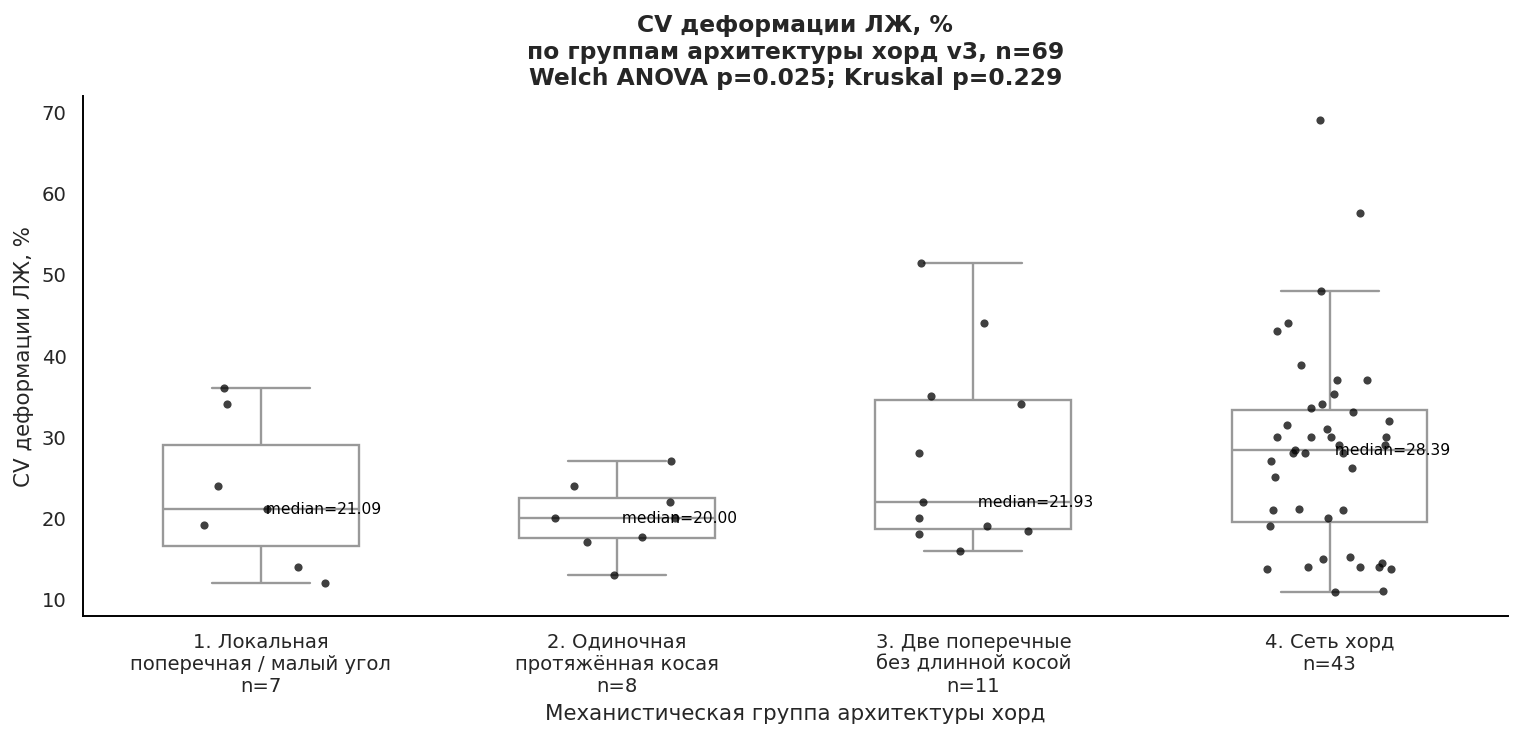

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_box_strip_dicor_sm_kdtr_cv_pct_by_chord_architecture_v3.png


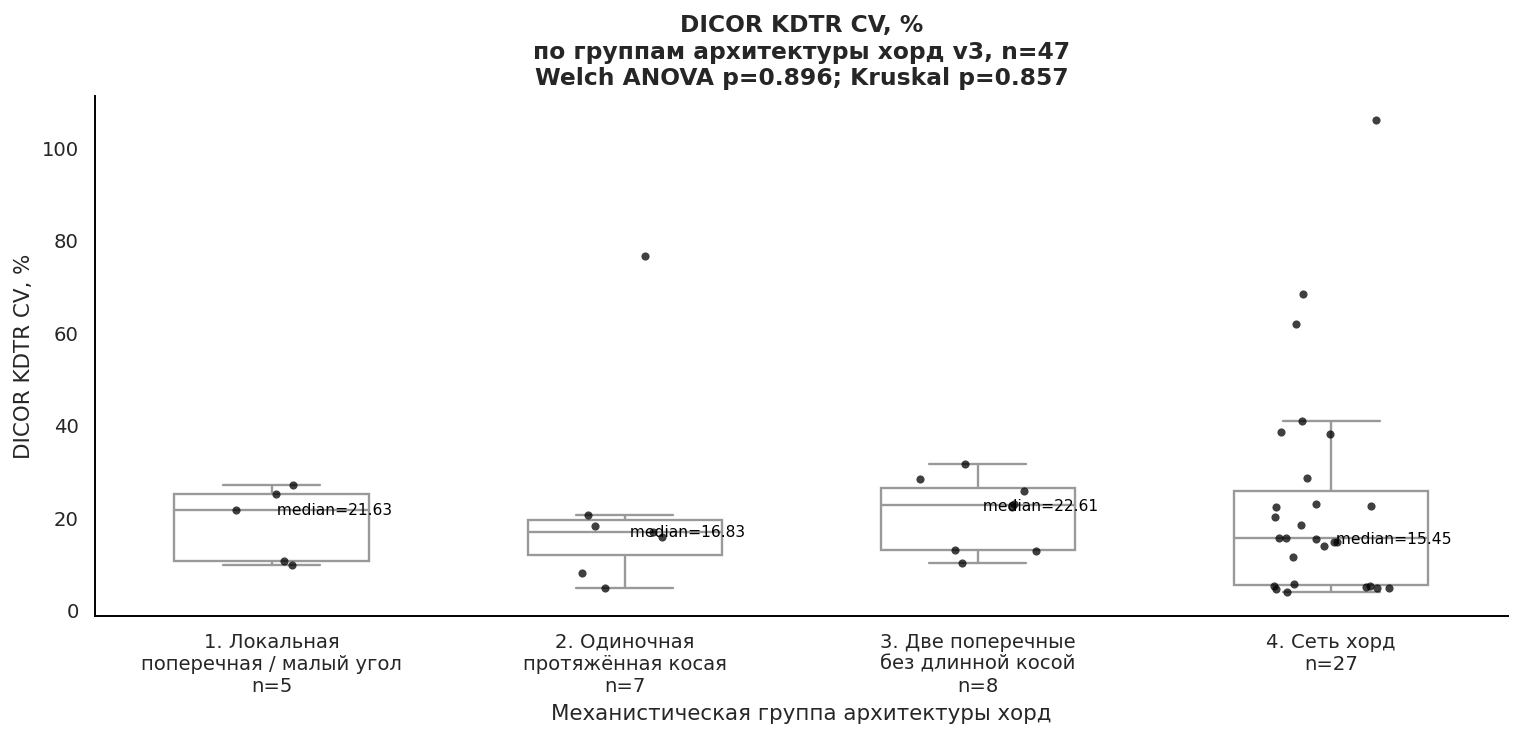

In [15]:
# ============================================================
# 1. Boxplot + stripplot for each outcome
# ============================================================

def plot_box_strip_anova(data, outcome, save=True):
    temp = data[[GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[GROUP_COL].isin(GROUP_ORDER)]

    if temp.empty:
        print(f"Skipping {outcome}: no data")
        return

    group_n = temp[GROUP_COL].value_counts().to_dict()

    xlabels = [
        f"{GROUP_LABELS_RU[g]}\nn={group_n.get(g, 0)}"
        for g in GROUP_ORDER
    ]

    fig, ax = plt.subplots(figsize=(11, 5.4))

    sns.boxplot(
        data=temp,
        x=GROUP_COL,
        y=outcome,
        order=GROUP_ORDER,
        color="white",
        width=0.55,
        fliersize=0,
        linewidth=1.2,
        ax=ax,
    )

    sns.stripplot(
        data=temp,
        x=GROUP_COL,
        y=outcome,
        order=GROUP_ORDER,
        color="black",
        size=4.2,
        jitter=0.18,
        alpha=0.75,
        ax=ax,
    )

    medians = temp.groupby(GROUP_COL)[outcome].median()

    for i, g in enumerate(GROUP_ORDER):
        if g in medians.index:
            ax.text(
                i,
                medians.loc[g],
                f" median={medians.loc[g]:.2f}",
                va="center",
                ha="left",
                fontsize=8,
                color="black",
            )

    ax.set_xlabel("Механистическая группа архитектуры хорд")
    ax.set_ylabel(OUTCOME_LABELS_RU.get(outcome, outcome))
    ax.set_xticklabels(xlabels)

    # ANOVA p-value in title
    p_txt = ""
    if "anova_results" in globals() and not anova_results.empty:
        row = anova_results[anova_results["outcome"] == outcome]
        if not row.empty:
            welch_p = row["welch_anova_p"].iloc[0]
            kruskal_p = row["kruskal_p"].iloc[0]
            p_txt = f"\nWelch ANOVA p={welch_p:.3f}; Kruskal p={kruskal_p:.3f}"

    ax.set_title(
        f"{OUTCOME_LABELS_RU.get(outcome, outcome)}\n"
        f"по группам архитектуры хорд v3, n={len(temp)}{p_txt}"
    )

    sns.despine(ax=ax)
    plt.tight_layout()

    if save:
        file_name = f"18_anova_box_strip_{outcome}_by_chord_architecture_v3.png"
        fig.savefig(FIGURES_DIR / file_name, bbox_inches="tight")
        print("Saved:", FIGURES_DIR / file_name)

    plt.show()


for outcome in existing_outcomes:
    plot_box_strip_anova(df, outcome)

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_mean_ci_echo_lv_sphericity_index_end_diastolic_ratio_by_chord_architecture_v3.png


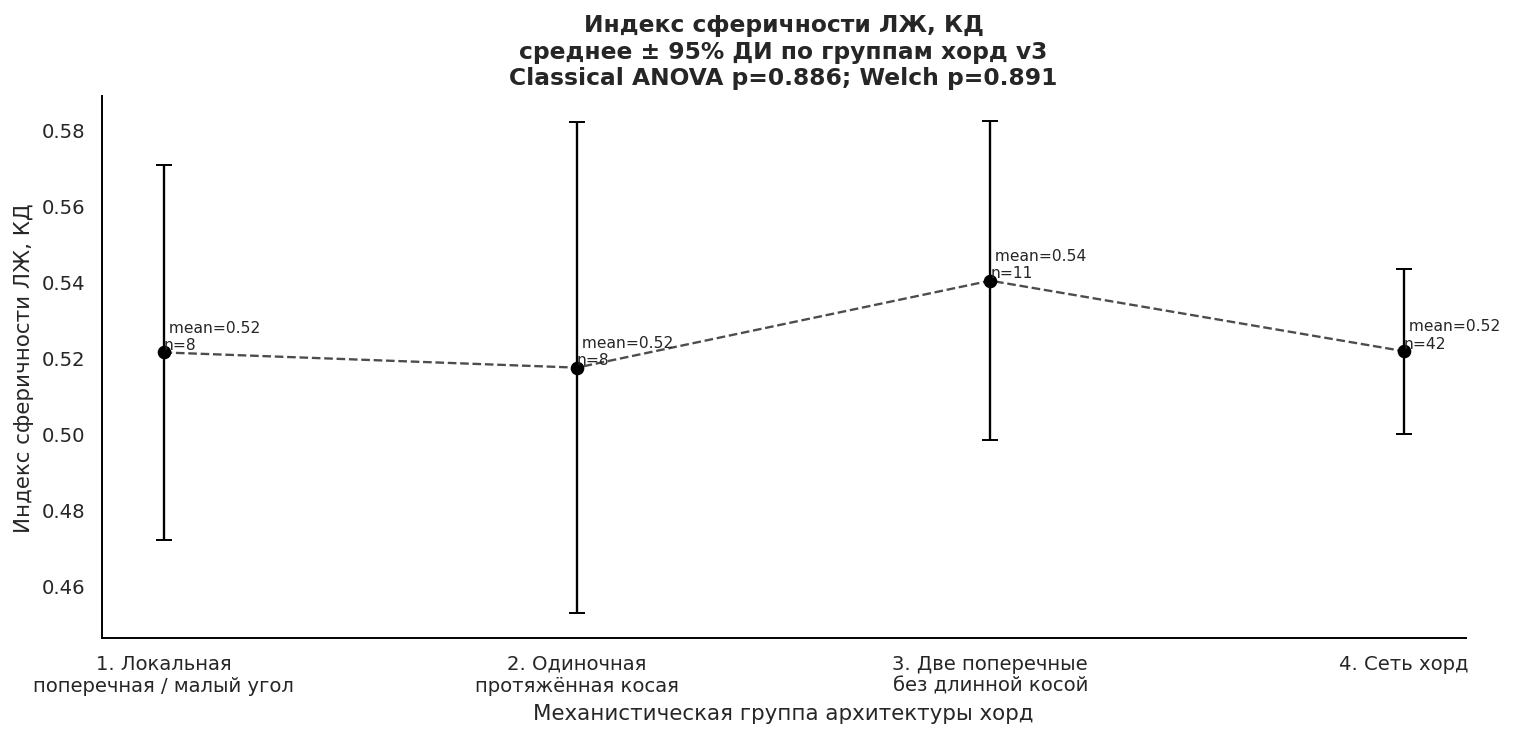

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_mean_ci_echo_lv_sphericity_index_end_systolic_ratio_by_chord_architecture_v3.png


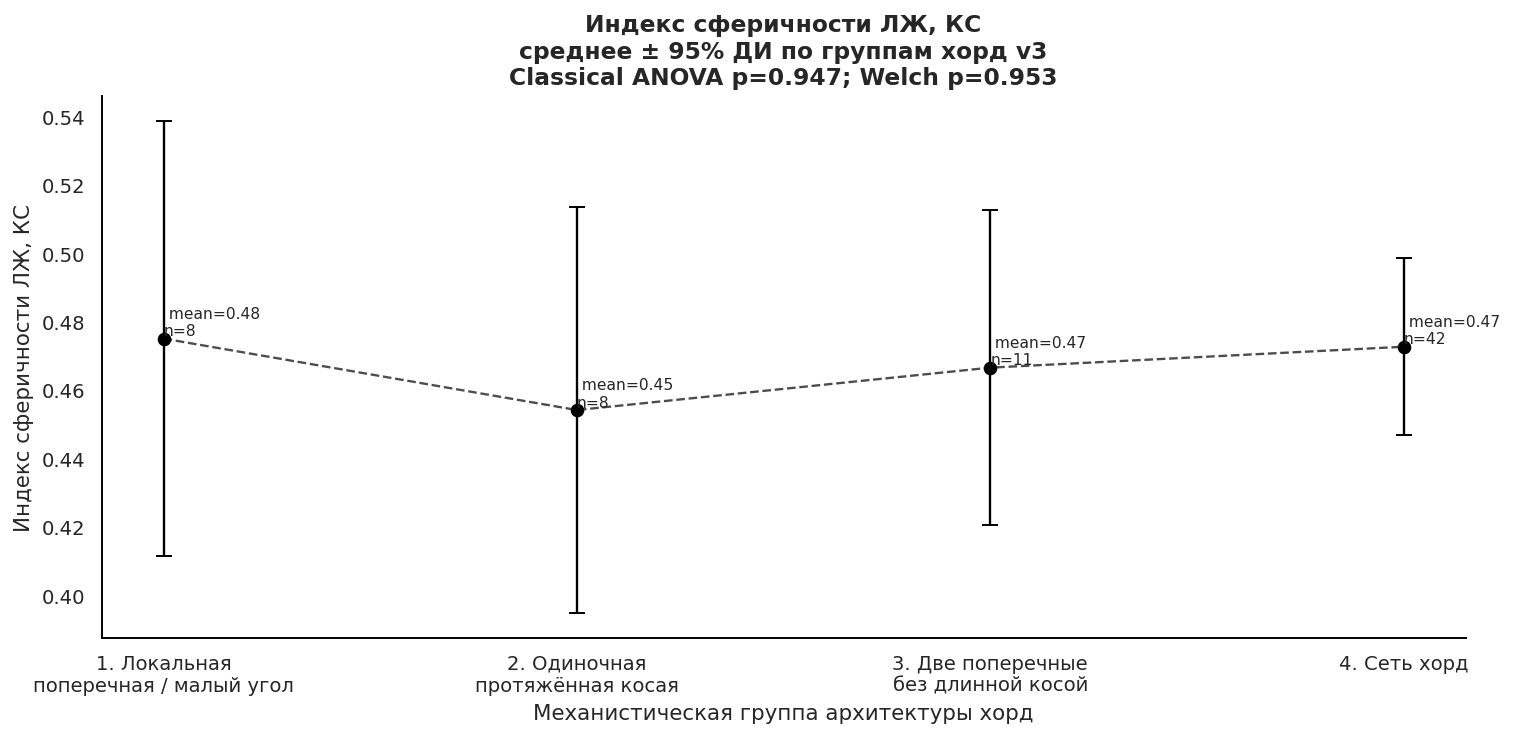

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_mean_ci_echo_lv_myocardial_mass_index_g_m2_by_chord_architecture_v3.png


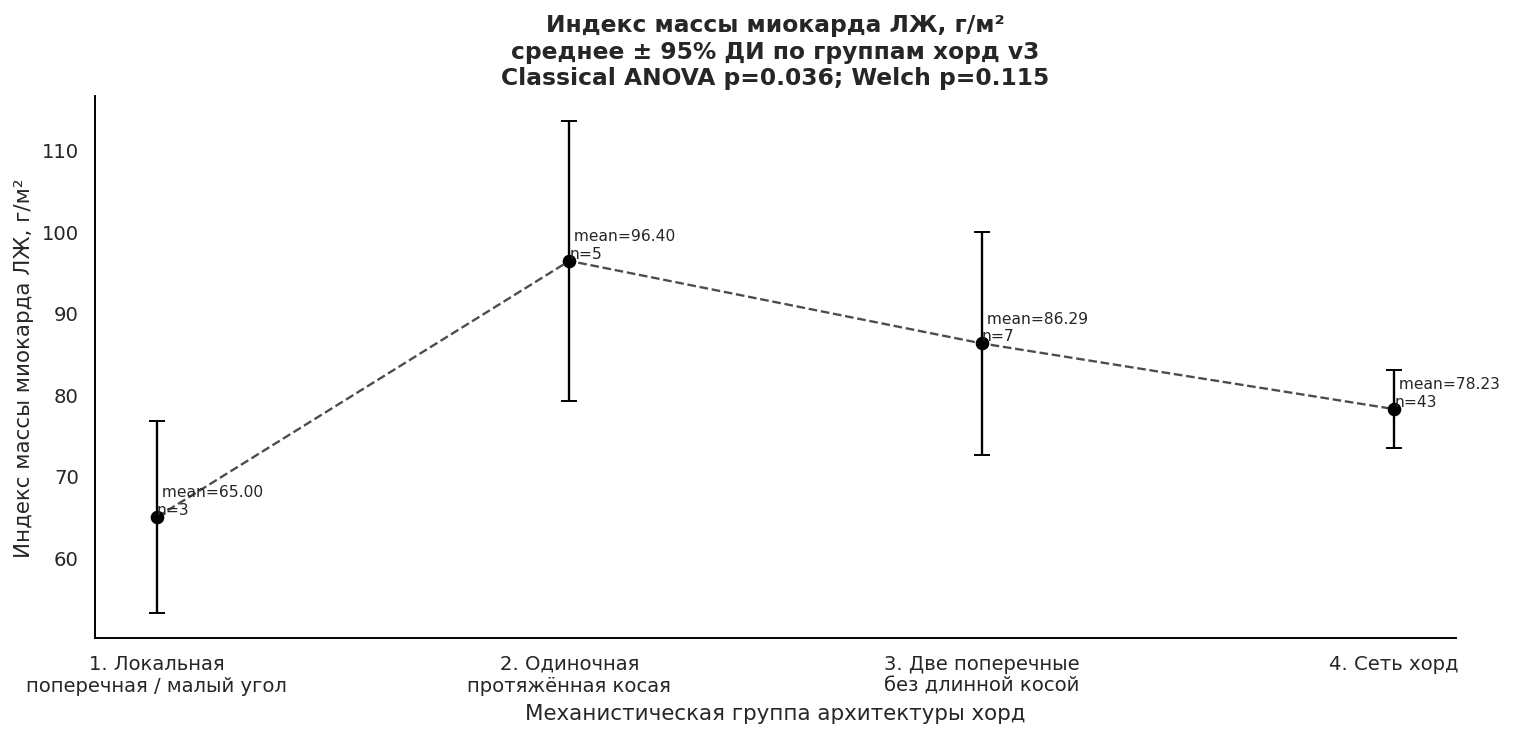

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_mean_ci_echo_lv_sws_delta_g_cm2_by_chord_architecture_v3.png


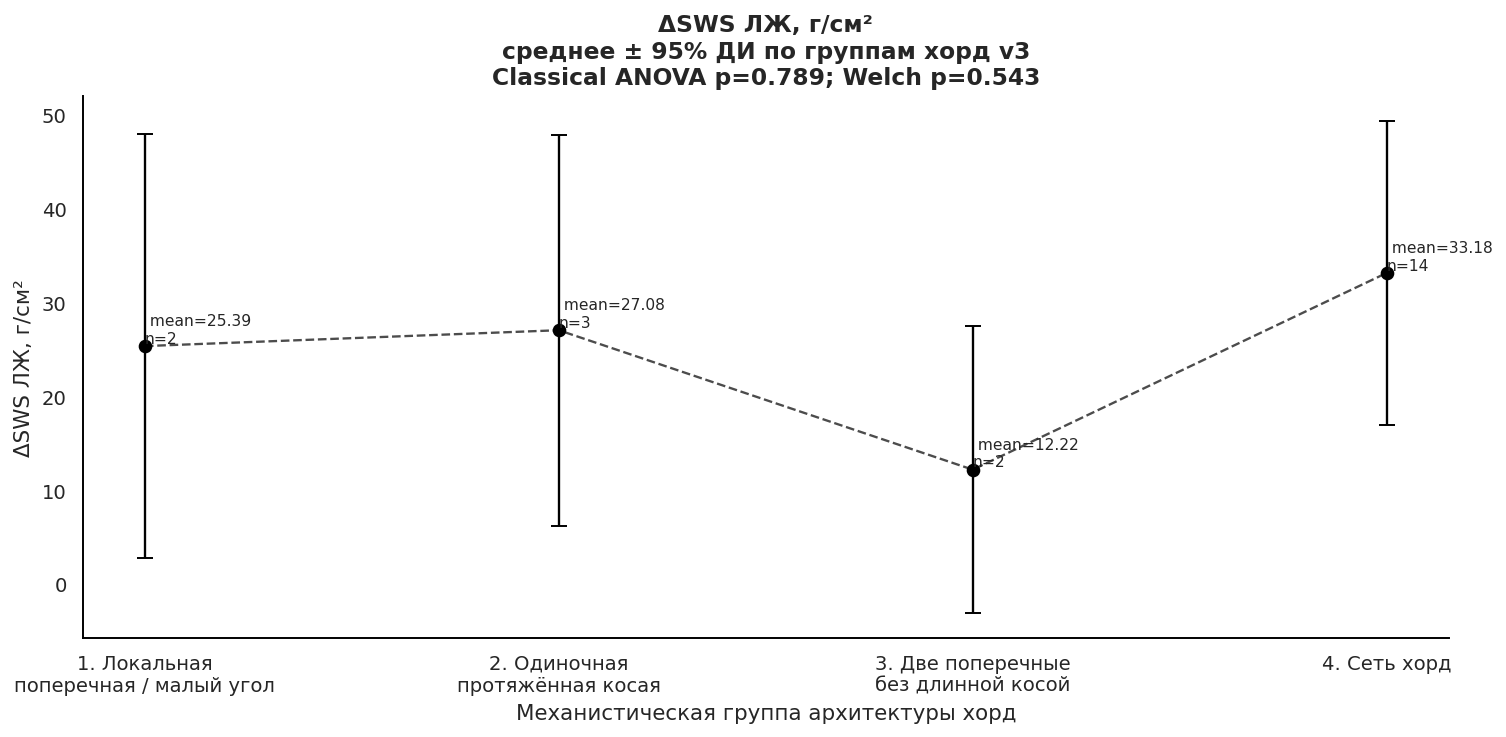

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_mean_ci_merged_lv_deformation_cv_pct_by_chord_architecture_v3.png


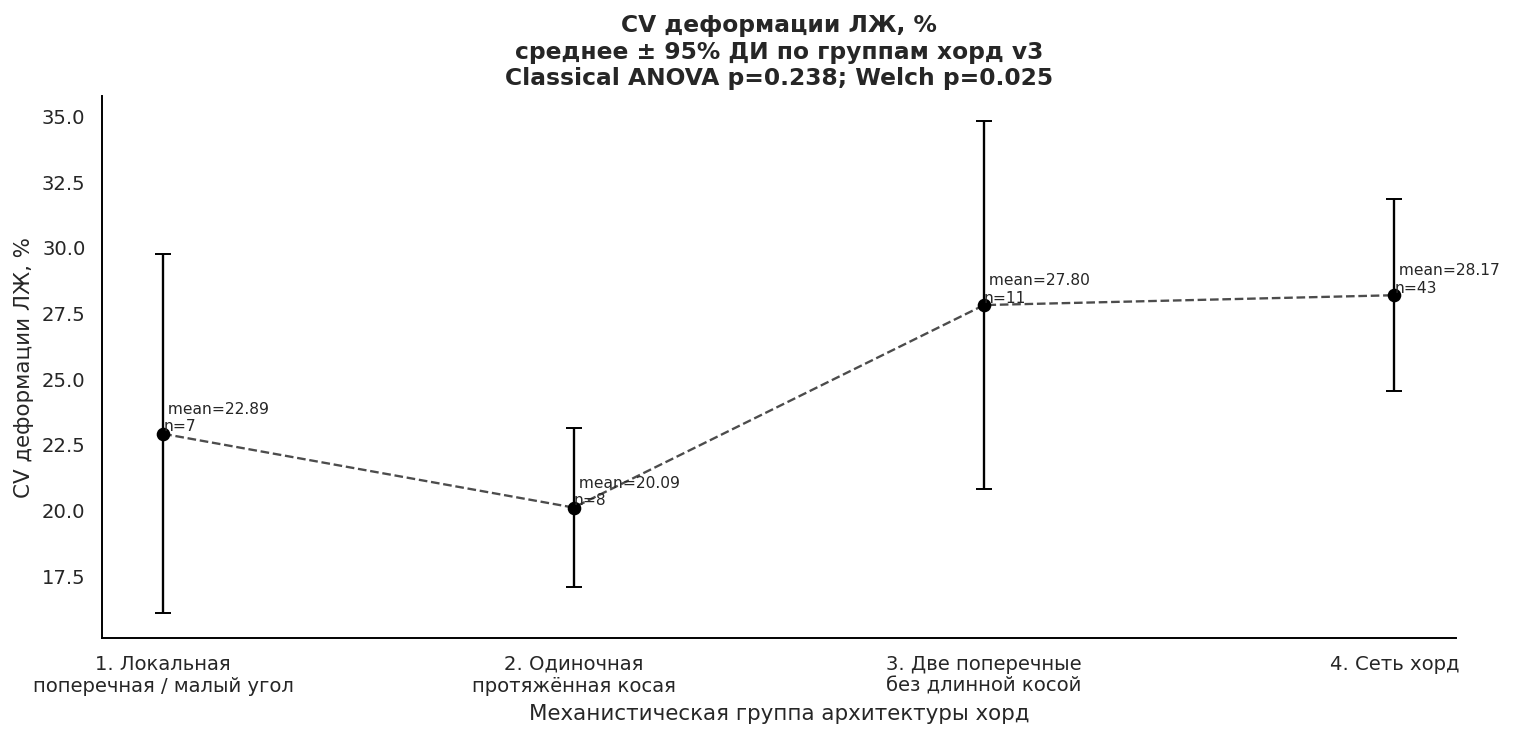

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_mean_ci_dicor_sm_kdtr_cv_pct_by_chord_architecture_v3.png


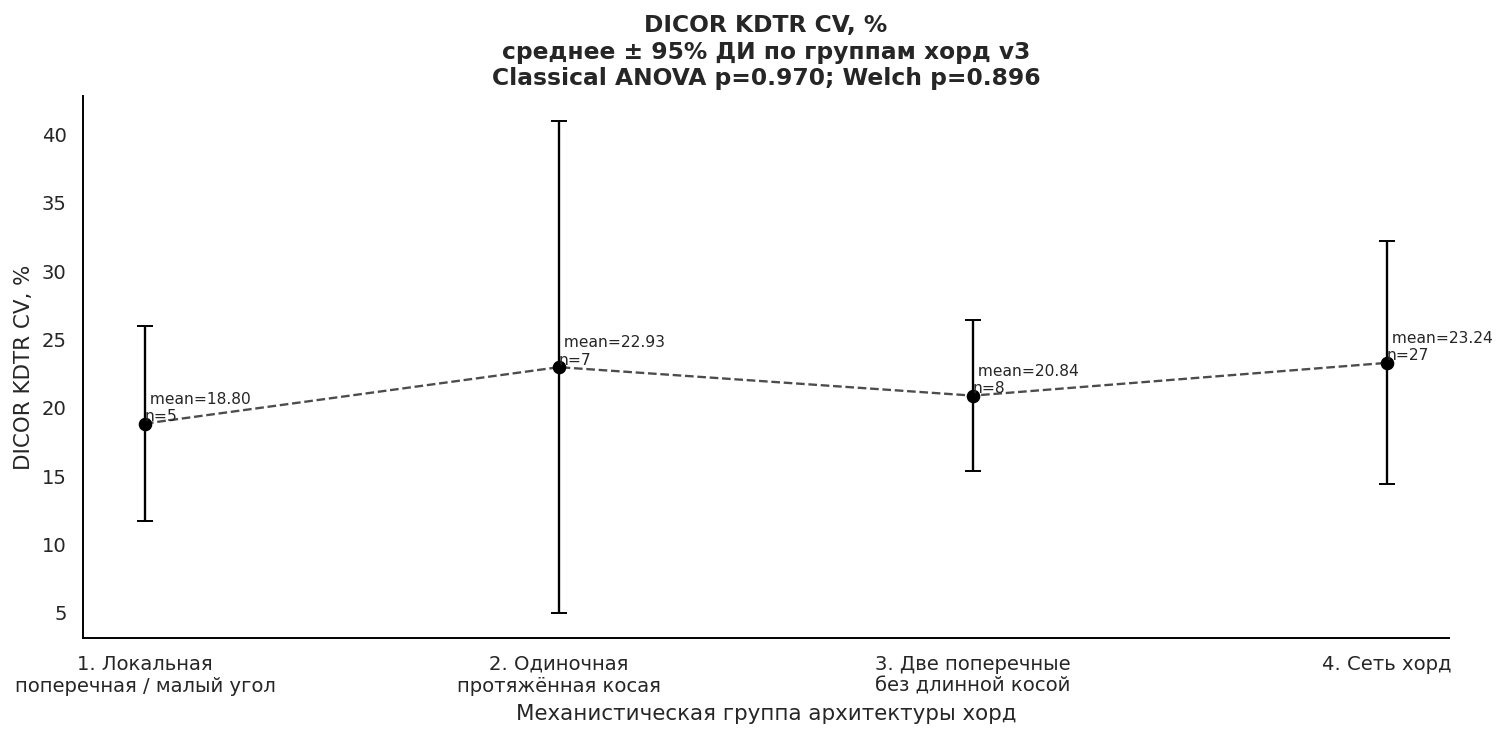

In [16]:
# ============================================================
# 2. Mean ± 95% CI plots for ANOVA interpretation
# ============================================================

def plot_mean_ci_anova(data, outcome, save=True):
    temp = data[[GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[GROUP_COL].isin(GROUP_ORDER)]

    if temp.empty:
        print(f"Skipping {outcome}: no data")
        return

    summary = (
        temp
        .groupby(GROUP_COL)[outcome]
        .agg(["count", "mean", "std"])
        .reindex(GROUP_ORDER)
        .reset_index()
    )

    summary["sem"] = summary["std"] / np.sqrt(summary["count"])
    summary["ci95"] = 1.96 * summary["sem"]

    fig, ax = plt.subplots(figsize=(11, 5.4))

    x = np.arange(len(summary))

    ax.errorbar(
        x,
        summary["mean"],
        yerr=summary["ci95"],
        fmt="o",
        color="black",
        ecolor="black",
        elinewidth=1.2,
        capsize=4,
        markersize=6,
    )

    ax.plot(
        x,
        summary["mean"],
        color="black",
        linewidth=1.2,
        linestyle="--",
        alpha=0.7,
    )

    for i, row in summary.iterrows():
        if pd.notna(row["mean"]):
            ax.text(
                i,
                row["mean"],
                f" mean={row['mean']:.2f}\nn={int(row['count'])}",
                ha="left",
                va="bottom",
                fontsize=8,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [GROUP_LABELS_RU[g] for g in GROUP_ORDER],
        rotation=0,
    )

    ax.set_xlabel("Механистическая группа архитектуры хорд")
    ax.set_ylabel(OUTCOME_LABELS_RU.get(outcome, outcome))

    p_txt = ""
    if "anova_results" in globals() and not anova_results.empty:
        row = anova_results[anova_results["outcome"] == outcome]
        if not row.empty:
            classical_p = row["classical_anova_p"].iloc[0]
            welch_p = row["welch_anova_p"].iloc[0]
            p_txt = f"\nClassical ANOVA p={classical_p:.3f}; Welch p={welch_p:.3f}"

    ax.set_title(
        f"{OUTCOME_LABELS_RU.get(outcome, outcome)}\n"
        f"среднее ± 95% ДИ по группам хорд v3{p_txt}"
    )

    sns.despine(ax=ax)
    plt.tight_layout()

    if save:
        file_name = f"18_anova_mean_ci_{outcome}_by_chord_architecture_v3.png"
        fig.savefig(FIGURES_DIR / file_name, bbox_inches="tight")
        print("Saved:", FIGURES_DIR / file_name)

    plt.show()


for outcome in existing_outcomes:
    plot_mean_ci_anova(df, outcome)

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_standardized_profile_chord_architecture_v3.png


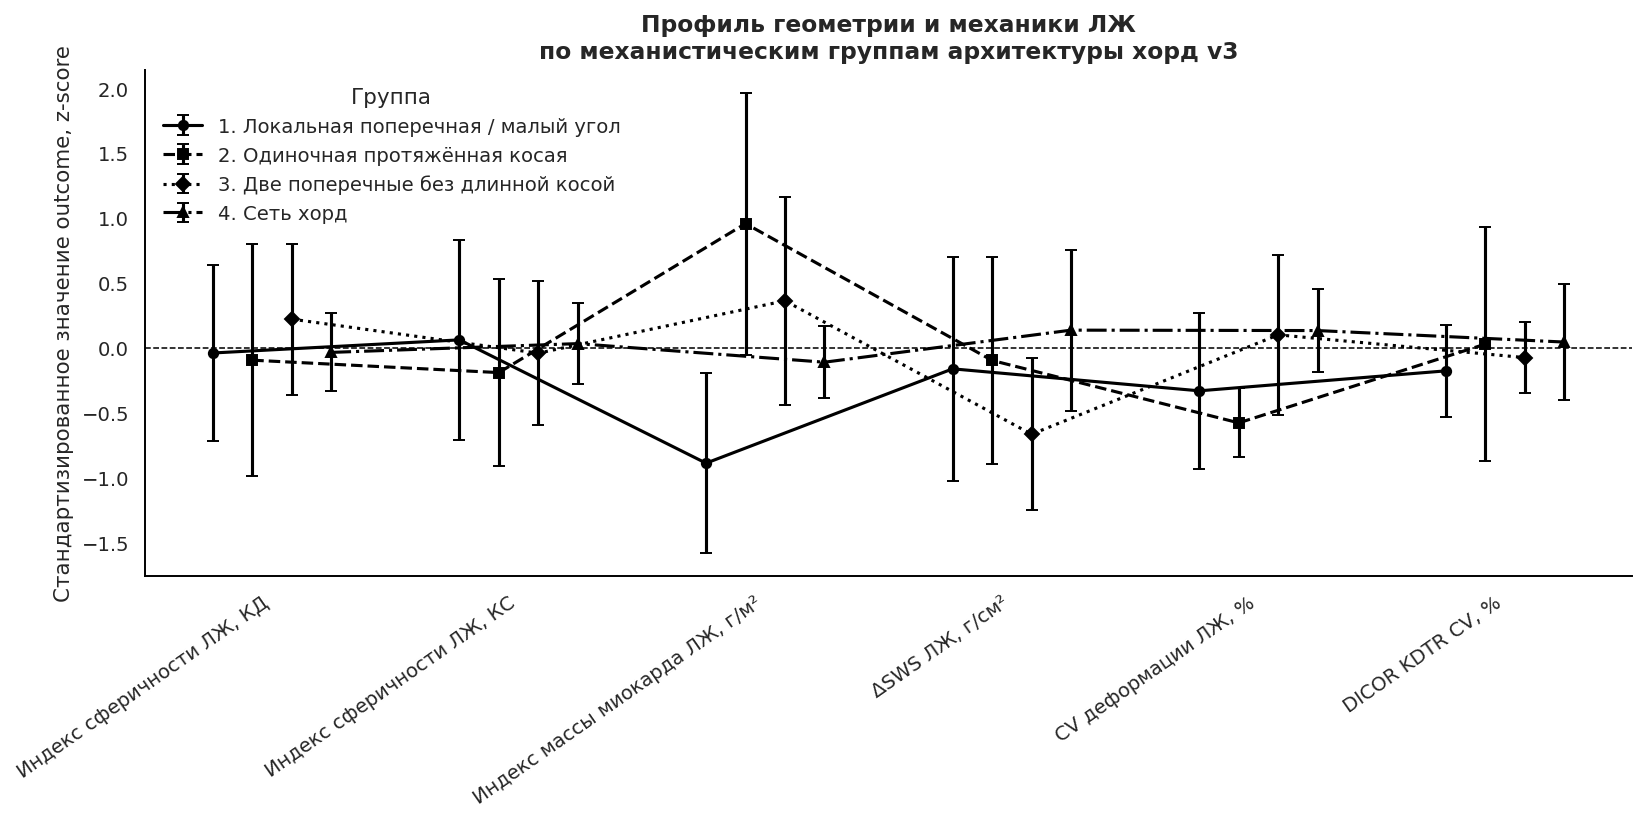

In [17]:
# ============================================================
# 3. Standardized z-score profile across all outcomes
# ============================================================

profile_rows = []

for outcome in existing_outcomes:
    temp = df[[GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[GROUP_COL].isin(GROUP_ORDER)]

    if temp.empty or temp[outcome].std(ddof=0) == 0:
        continue

    temp["z_value"] = (temp[outcome] - temp[outcome].mean()) / temp[outcome].std(ddof=0)
    temp["outcome_label_ru"] = OUTCOME_LABELS_RU.get(outcome, outcome)

    grouped = (
        temp
        .groupby([GROUP_COL, "outcome_label_ru"])["z_value"]
        .agg(["mean", "sem", "count"])
        .reset_index()
    )

    profile_rows.append(grouped)

profile_v3 = pd.concat(profile_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 6))

x_labels = list(profile_v3["outcome_label_ru"].drop_duplicates())
x_positions = np.arange(len(x_labels))

offsets = {
    "1_Local_transverse_or_low_angle": -0.24,
    "2_Single_long_oblique_bridge": -0.08,
    "3_Double_transverse_no_long_oblique": 0.08,
    "4_Chord_network": 0.24,
}

markers = {
    "1_Local_transverse_or_low_angle": "o",
    "2_Single_long_oblique_bridge": "s",
    "3_Double_transverse_no_long_oblique": "D",
    "4_Chord_network": "^",
}

linestyles = {
    "1_Local_transverse_or_low_angle": "-",
    "2_Single_long_oblique_bridge": "--",
    "3_Double_transverse_no_long_oblique": ":",
    "4_Chord_network": "-.",
}

for group in GROUP_ORDER:
    gdf = profile_v3[profile_v3[GROUP_COL] == group].copy()

    y_values = []
    y_errors = []

    for label in x_labels:
        row = gdf[gdf["outcome_label_ru"] == label]

        if row.empty:
            y_values.append(np.nan)
            y_errors.append(np.nan)
        else:
            y_values.append(row["mean"].iloc[0])
            y_errors.append(row["sem"].iloc[0] * 1.96)

    ax.errorbar(
        x_positions + offsets[group],
        y_values,
        yerr=y_errors,
        marker=markers[group],
        linestyle=linestyles[group],
        linewidth=1.6,
        capsize=3,
        color="black",
        label=GROUP_LABELS_RU[group].replace("\n", " "),
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=35, ha="right")

ax.set_ylabel("Стандартизированное значение outcome, z-score")
ax.set_xlabel("")
ax.set_title(
    "Профиль геометрии и механики ЛЖ\n"
    "по механистическим группам архитектуры хорд v3"
)

ax.legend(title="Группа", loc="best")
sns.despine(ax=ax)

plt.tight_layout()

file_name = "18_anova_standardized_profile_chord_architecture_v3.png"
fig.savefig(FIGURES_DIR / file_name, bbox_inches="tight")
print("Saved:", FIGURES_DIR / file_name)

plt.show()

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_summary_heatmap_pvalues_effectsizes.png


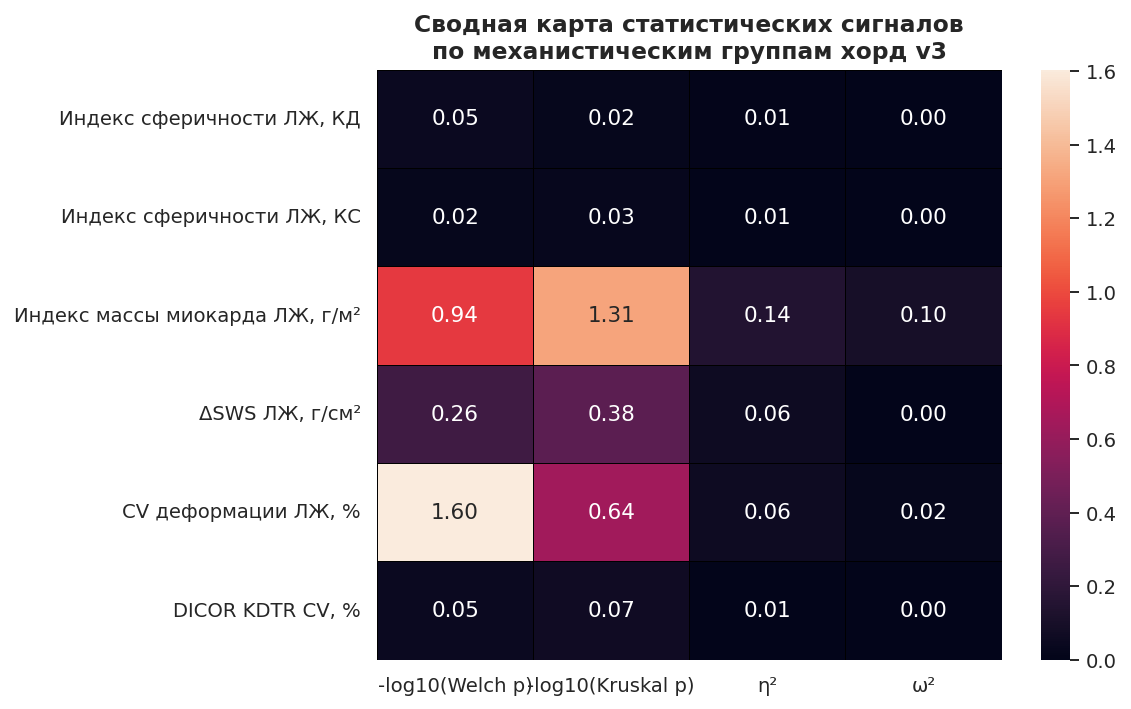

In [18]:
# ============================================================
# 4. Heatmap of ANOVA p-values and effect sizes
# ============================================================

heat = anova_results.copy()

heat = heat[heat["outcome"].isin(existing_outcomes)].copy()
heat["outcome_label_ru"] = heat["outcome"].map(OUTCOME_LABELS_RU)

# -log10 p for visual signal
heat["neg_log10_welch_p"] = -np.log10(heat["welch_anova_p"])
heat["neg_log10_kruskal_p"] = -np.log10(heat["kruskal_p"])

# Replace inf
heat["neg_log10_welch_p"] = heat["neg_log10_welch_p"].replace([np.inf, -np.inf], np.nan)
heat["neg_log10_kruskal_p"] = heat["neg_log10_kruskal_p"].replace([np.inf, -np.inf], np.nan)

heatmap_df = heat.set_index("outcome_label_ru")[
    [
        "neg_log10_welch_p",
        "neg_log10_kruskal_p",
        "eta_squared",
        "omega_squared",
    ]
]

heatmap_df = heatmap_df.rename(columns={
    "neg_log10_welch_p": "-log10(Welch p)",
    "neg_log10_kruskal_p": "-log10(Kruskal p)",
    "eta_squared": "η²",
    "omega_squared": "ω²",
})

fig, ax = plt.subplots(figsize=(8.5, 5.2))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="black",
    cbar=True,
    ax=ax,
)

ax.set_title(
    "Сводная карта статистических сигналов\n"
    "по механистическим группам хорд v3"
)

ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

file_name = "18_anova_summary_heatmap_pvalues_effectsizes.png"
fig.savefig(FIGURES_DIR / file_name, bbox_inches="tight")
print("Saved:", FIGURES_DIR / file_name)

plt.show()

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_anova_posthoc_welch_forest_top20.png


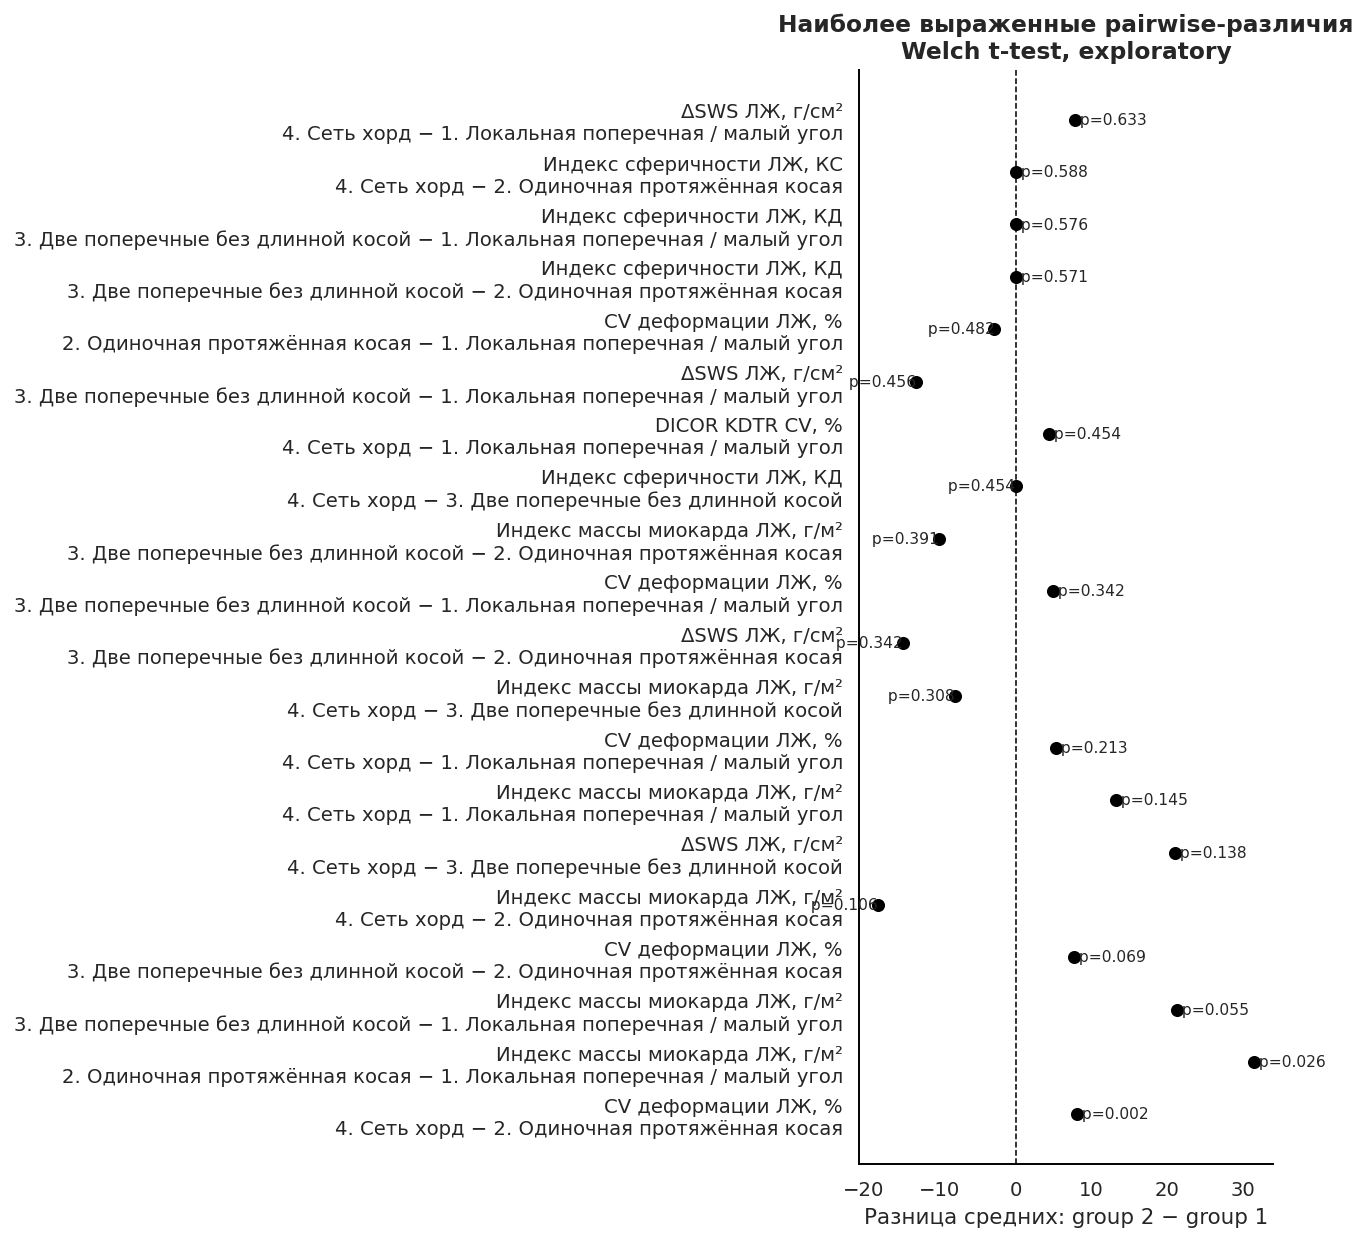

In [19]:
# ============================================================
# 5. Post-hoc pairwise Welch forest plot
# ============================================================

if "posthoc_welch" in globals() and not posthoc_welch.empty:
    forest = posthoc_welch.copy()
    forest = forest[forest["p_uncorrected"].notna()].copy()

    # Keep most interesting comparisons by uncorrected p-value
    forest = forest.sort_values("p_uncorrected").head(20).copy()

    forest["comparison"] = (
        forest["outcome_label_ru"]
        + "\n"
        + forest["group_2_label_ru"]
        + " − "
        + forest["group_1_label_ru"]
    )

    fig, ax = plt.subplots(figsize=(9.5, max(5, 0.45 * len(forest))))

    y_pos = np.arange(len(forest))

    ax.scatter(
        forest["mean_diff_group2_minus_group1"],
        y_pos,
        color="black",
        s=35,
    )

    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

    for i, (_, row) in enumerate(forest.iterrows()):
        ax.text(
            row["mean_diff_group2_minus_group1"],
            i,
            f" p={row['p_uncorrected']:.3f}",
            va="center",
            ha="left" if row["mean_diff_group2_minus_group1"] >= 0 else "right",
            fontsize=8,
        )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(forest["comparison"])

    ax.set_xlabel("Разница средних: group 2 − group 1")
    ax.set_title(
        "Наиболее выраженные pairwise-различия\n"
        "Welch t-test, exploratory"
    )

    sns.despine(ax=ax)
    plt.tight_layout()

    file_name = "18_anova_posthoc_welch_forest_top20.png"
    fig.savefig(FIGURES_DIR / file_name, bbox_inches="tight")
    print("Saved:", FIGURES_DIR / file_name)

    plt.show()
else:
    print("posthoc_welch is empty or not found.")

In [20]:
# ============================================================
# Show most important post-hoc comparisons
# ============================================================

important_posthoc = posthoc_welch.copy()

important_posthoc = important_posthoc[
    important_posthoc["p_uncorrected"].notna()
].copy()

cols_to_show = [
    "outcome_label_ru",
    "group_1_label_ru",
    "group_2_label_ru",
    "n_1",
    "n_2",
    "mean_1",
    "mean_2",
    "mean_diff_group2_minus_group1",
    "median_1",
    "median_2",
    "median_diff_group2_minus_group1",
    "p_uncorrected",
    "p_holm",
    "reject_holm_0_05",
]

important_posthoc = important_posthoc.sort_values("p_uncorrected")

display(important_posthoc[cols_to_show].head(20))

,outcome_label_ru,group_1_label_ru,group_2_label_ru,n_1,n_2,mean_1,mean_2,mean_diff_group2_minus_group1,median_1,median_2,median_diff_group2_minus_group1,p_uncorrected,p_holm,reject_holm_0_05
28,"CV деформации ЛЖ, %",2. Одиночная протяжённая косая,4. Сеть хорд,8,43,20.085696,28.170199,8.084503,20.000000,28.392743,8.392743,0.002160,0.012960,True
12,"Индекс массы миокарда ЛЖ, г/м²",1. Локальная поперечная / малый угол,2. Одиночная протяжённая косая,3,5,65.000000,96.400000,31.400000,60.000000,97.000000,37.000000,0.025501,0.153005,False
13,"Индекс массы миокарда ЛЖ, г/м²",1. Локальная поперечная / малый угол,3. Две поперечные без длинной косой,3,7,65.000000,86.285714,21.285714,60.000000,83.000000,23.000000,0.054884,0.274420,False
27,"CV деформации ЛЖ, %",2. Одиночная протяжённая косая,3. Две поперечные без длинной косой,8,11,20.085696,27.795487,7.709790,20.000000,21.934674,1.934674,0.068675,0.343374,False
16,"Индекс массы миокарда ЛЖ, г/м²",2. Одиночная протяжённая косая,4. Сеть хорд,5,43,96.400000,78.232558,-18.167442,97.000000,75.000000,-22.000000,0.106464,0.425858,False
23,"ΔSWS ЛЖ, г/см²",3. Две поперечные без длинной косой,4. Сеть хорд,2,14,12.218746,33.184682,20.965936,12.218746,24.297298,12.078552,0.137636,0.825815,False
14,"Индекс массы миокарда ЛЖ, г/м²",1. Локальная поперечная / малый угол,4. Сеть хорд,3,43,65.000000,78.232558,13.232558,60.000000,75.000000,15.000000,0.144725,0.434175,False
26,"CV деформации ЛЖ, %",1. Локальная поперечная / малый угол,4. Сеть хорд,7,43,22.892669,28.170199,5.277530,21.094764,28.392743,7.297980,0.212538,0.850151,False
17,"Индекс массы миокарда ЛЖ, г/м²",3. Две поперечные без длинной косой,4. Сеть хорд,7,43,86.285714,78.232558,-8.053156,83.000000,75.000000,-8.000000,0.308083,0.616167,False
21,"ΔSWS ЛЖ, г/см²",2. Одиночная протяжённая косая,3. Две поперечные без длинной косой,3,2,27.081655,12.218746,-14.862909,35.371669,12.218746,-23.152923,0.341957,1.000000,False


In [21]:
# ============================================================
# Search for systolic wall stress / SWS variables
# ============================================================

sws_like_cols = [
    c for c in df.columns
    if ("sws" in c.lower())
    or ("wall_stress" in c.lower())
    or ("stress" in c.lower())
    or ("напряж" in c.lower())
]

print("SWS / wall stress-like columns:")
for c in sws_like_cols:
    print(c)

display(df[sws_like_cols].describe().T if sws_like_cols else "No SWS-like columns found")

SWS / wall stress-like columns:
echo_lv_systolic_wall_stress_g_cm2
dsws
echo_lv_sws_rest_g_cm2
echo_lv_sws_max_g_cm2
echo_lv_sws_delta_g_cm2


,count,mean,std,min,25%,50%,75%,max
echo_lv_systolic_wall_stress_g_cm2,64.0,116.411474,70.681943,54.346357,80.911240,95.881231,117.904672,451.937339
dsws,66.0,23.696970,11.280984,-3.000000,17.000000,24.500000,29.000000,47.000000
echo_lv_sws_rest_g_cm2,34.0,110.137829,16.180123,75.558075,97.054692,111.184540,123.407148,136.497602
echo_lv_sws_max_g_cm2,33.0,133.883427,17.372924,100.482326,124.914385,135.312821,146.363178,171.181419
echo_lv_sws_delta_g_cm2,33.0,26.188850,22.531086,3.042909,13.859631,21.944419,35.371669,135.312821


In [22]:
# ============================================================
# Create wall stress normalized by LV myocardial mass index
# ============================================================

mass_col = "echo_lv_myocardial_mass_index_g_m2"

sws_cols_to_normalize = [
    "echo_lv_systolic_wall_stress_g_cm2",
    "echo_lv_sws_rest_g_cm2",
    "echo_lv_sws_max_g_cm2",
    "echo_lv_sws_delta_g_cm2",
]

for col in [mass_col] + sws_cols_to_normalize:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Main variable requested by supervisor:
# systolic wall stress normalized by LV myocardial mass index
df["echo_lv_systolic_wall_stress_per_mass_index"] = (
    df["echo_lv_systolic_wall_stress_g_cm2"] / df[mass_col]
)

# Additional exploratory normalized variables
df["echo_lv_sws_rest_per_mass_index"] = (
    df["echo_lv_sws_rest_g_cm2"] / df[mass_col]
)

df["echo_lv_sws_max_per_mass_index"] = (
    df["echo_lv_sws_max_g_cm2"] / df[mass_col]
)

df["echo_lv_sws_delta_per_mass_index"] = (
    df["echo_lv_sws_delta_g_cm2"] / df[mass_col]
)

new_stress_ratio_cols = [
    "echo_lv_systolic_wall_stress_per_mass_index",
    "echo_lv_sws_rest_per_mass_index",
    "echo_lv_sws_max_per_mass_index",
    "echo_lv_sws_delta_per_mass_index",
]

display(df[new_stress_ratio_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
echo_lv_systolic_wall_stress_per_mass_index,58.0,1.370963,0.764695,0.653271,0.935331,1.158496,1.415493,4.584161
echo_lv_sws_rest_per_mass_index,32.0,1.337931,0.283171,0.740835,1.128784,1.296897,1.612921,1.815078
echo_lv_sws_max_per_mass_index,31.0,1.610249,0.256811,1.161713,1.398005,1.616016,1.823504,2.061008
echo_lv_sws_delta_per_mass_index,31.0,0.301344,0.247186,0.030429,0.174519,0.264987,0.381349,1.454977


In [23]:
# ============================================================
# Additional outcomes requested by supervisor
# ============================================================

ADDITIONAL_OUTCOMES = [
    "echo_lv_end_diastolic_volume_index_teichholz_ml_m2",
    "echo_lv_end_diastolic_volume_index_simpson_ml_m2",
    "vo2_max_absolute_ml_min",
    "echo_lv_systolic_wall_stress_g_cm2",
    "echo_lv_systolic_wall_stress_per_mass_index",
    "echo_lv_sws_rest_per_mass_index",
    "echo_lv_sws_max_per_mass_index",
    "echo_lv_sws_delta_per_mass_index",
]

ADDITIONAL_OUTCOME_LABELS_RU = {
    "echo_lv_end_diastolic_volume_index_teichholz_ml_m2": "Индекс КДО ЛЖ, Teichholz, мл/м²",
    "echo_lv_end_diastolic_volume_index_simpson_ml_m2": "Индекс КДО ЛЖ, Simpson, мл/м²",
    "vo2_max_absolute_ml_min": "VO₂max абсолютный, мл/мин",
    "echo_lv_systolic_wall_stress_g_cm2": "Систолическое напряжение стенки ЛЖ, г/см²",
    "echo_lv_systolic_wall_stress_per_mass_index": "Систолическое напряжение / индекс массы ЛЖ",
    "echo_lv_sws_rest_per_mass_index": "SWS покоя / индекс массы ЛЖ",
    "echo_lv_sws_max_per_mass_index": "SWS max / индекс массы ЛЖ",
    "echo_lv_sws_delta_per_mass_index": "ΔSWS / индекс массы ЛЖ",
}

existing_additional_outcomes = [c for c in ADDITIONAL_OUTCOMES if c in df.columns]
missing_additional_outcomes = [c for c in ADDITIONAL_OUTCOMES if c not in df.columns]

print("Existing additional outcomes:")
print(existing_additional_outcomes)

print("\nMissing additional outcomes:")
print(missing_additional_outcomes)

for col in existing_additional_outcomes:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Existing additional outcomes:
['echo_lv_end_diastolic_volume_index_simpson_ml_m2', 'vo2_max_absolute_ml_min', 'echo_lv_systolic_wall_stress_g_cm2', 'echo_lv_systolic_wall_stress_per_mass_index', 'echo_lv_sws_rest_per_mass_index', 'echo_lv_sws_max_per_mass_index', 'echo_lv_sws_delta_per_mass_index']

Missing additional outcomes:
['echo_lv_end_diastolic_volume_index_teichholz_ml_m2']


In [24]:
# ============================================================
# ANOVA / Welch ANOVA / Kruskal for additional outcomes
# ============================================================

from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.oneway import anova_oneway

GROUP_COL = "chord_architecture_v3"

GROUP_ORDER = [
    "1_Local_transverse_or_low_angle",
    "2_Single_long_oblique_bridge",
    "3_Double_transverse_no_long_oblique",
    "4_Chord_network",
]

additional_summary_rows = []
additional_anova_rows = []

for outcome in existing_additional_outcomes:
    temp = df[[GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[GROUP_COL].isin(GROUP_ORDER)]

    if temp.empty:
        continue

    desc = (
        temp
        .groupby(GROUP_COL)[outcome]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )

    desc["outcome"] = outcome
    desc["outcome_label_ru"] = ADDITIONAL_OUTCOME_LABELS_RU.get(outcome, outcome)
    additional_summary_rows.append(desc)

    group_counts = temp[GROUP_COL].value_counts()
    valid_groups = group_counts[group_counts >= 2].index.tolist()
    temp_test = temp[temp[GROUP_COL].isin(valid_groups)].copy()

    if temp_test[GROUP_COL].nunique() < 2:
        continue

    arrays = [
        temp_test.loc[temp_test[GROUP_COL] == g, outcome].dropna()
        for g in valid_groups
    ]

    # Classical ANOVA
    try:
        model = smf.ols(f"{outcome} ~ C({GROUP_COL})", data=temp_test).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        classical_f = anova_table.loc[f"C({GROUP_COL})", "F"]
        classical_p = anova_table.loc[f"C({GROUP_COL})", "PR(>F)"]

        ss_between = anova_table.loc[f"C({GROUP_COL})", "sum_sq"]
        ss_resid = anova_table.loc["Residual", "sum_sq"]
        eta_squared = ss_between / (ss_between + ss_resid)

    except Exception:
        classical_f, classical_p, eta_squared = np.nan, np.nan, np.nan

    # Welch ANOVA
    try:
        welch = anova_oneway(
            temp_test[outcome].values,
            groups=temp_test[GROUP_COL].values,
            use_var="unequal",
        )
        welch_f = welch.statistic
        welch_p = welch.pvalue
    except Exception:
        welch_f, welch_p = np.nan, np.nan

    # Kruskal-Wallis
    try:
        kruskal_h, kruskal_p = stats.kruskal(*arrays)
    except Exception:
        kruskal_h, kruskal_p = np.nan, np.nan

    row = {
        "outcome": outcome,
        "outcome_label_ru": ADDITIONAL_OUTCOME_LABELS_RU.get(outcome, outcome),
        "n_total": len(temp),
        "n_tested": len(temp_test),
        "n_groups_tested": temp_test[GROUP_COL].nunique(),
        "classical_anova_f": classical_f,
        "classical_anova_p": classical_p,
        "welch_anova_f": welch_f,
        "welch_anova_p": welch_p,
        "kruskal_h": kruskal_h,
        "kruskal_p": kruskal_p,
        "eta_squared": eta_squared,
    }

    for g in GROUP_ORDER:
        row[f"n_{g}"] = int(group_counts.get(g, 0))

    additional_anova_rows.append(row)

additional_summary = pd.concat(additional_summary_rows, ignore_index=True)
additional_anova_results = pd.DataFrame(additional_anova_rows)

display(additional_summary)
display(additional_anova_results.sort_values("welch_anova_p"))

additional_summary.to_excel(
    TABLES_DIR / "18_v3_additional_outcomes_descriptive.xlsx",
    index=False
)

additional_anova_results.to_excel(
    TABLES_DIR / "18_v3_additional_outcomes_anova.xlsx",
    index=False
)

,chord_architecture_v3,count,mean,std,median,min,max,outcome,outcome_label_ru
0,1_Local_transverse_or_low_angle,1,45.769808,NaN,45.769808,45.769808,45.769808,echo_lv_end_diastolic_volume_index_simpson_ml_m2,"Индекс КДО ЛЖ, Simpson, мл/м²"
1,4_Chord_network,14,53.968948,9.419153,55.775519,30.411599,69.141396,echo_lv_end_diastolic_volume_index_simpson_ml_m2,"Индекс КДО ЛЖ, Simpson, мл/м²"
2,1_Local_transverse_or_low_angle,5,57.960000,4.600869,54.600000,54.600000,63.000000,vo2_max_absolute_ml_min,"VO₂max абсолютный, мл/мин"
3,2_Single_long_oblique_bridge,7,50.150000,12.199419,54.600000,30.800000,63.000000,vo2_max_absolute_ml_min,"VO₂max абсолютный, мл/мин"
4,3_Double_transverse_no_long_oblique,6,38.616667,7.044194,38.500000,30.800000,46.550000,vo2_max_absolute_ml_min,"VO₂max абсолютный, мл/мин"
5,4_Chord_network,23,47.006522,10.455591,46.550000,30.800000,63.000000,vo2_max_absolute_ml_min,"VO₂max абсолютный, мл/мин"
6,1_Local_transverse_or_low_angle,5,106.078234,40.655955,95.171646,68.239120,166.945881,echo_lv_systolic_wall_stress_g_cm2,"Систолическое напряжение стенки ЛЖ, г/см²"
7,2_Single_long_oblique_bridge,7,93.348128,17.401930,98.845232,68.097079,114.446420,echo_lv_systolic_wall_stress_g_cm2,"Систолическое напряжение стенки ЛЖ, г/см²"
8,3_Double_transverse_no_long_oblique,6,106.560805,35.599648,96.922617,77.124986,175.546522,echo_lv_systolic_wall_stress_g_cm2,"Систолическое напряжение стенки ЛЖ, г/см²"
9,4_Chord_network,25,121.411743,79.806302,91.085343,60.715707,421.742791,echo_lv_systolic_wall_stress_g_cm2,"Систолическое напряжение стенки ЛЖ, г/см²"


,outcome,outcome_label_ru,n_total,n_tested,n_groups_tested,classical_anova_f,classical_anova_p,welch_anova_f,welch_anova_p,kruskal_h,kruskal_p,eta_squared,n_1_Local_transverse_or_low_angle,n_2_Single_long_oblique_bridge,n_3_Double_transverse_no_long_oblique,n_4_Chord_network
0,vo2_max_absolute_ml_min,"VO₂max абсолютный, мл/мин",41,41,4,3.649500,0.021140,9.822733,0.001194,9.443983,0.023935,0.228339,5,7,6,23
2,echo_lv_systolic_wall_stress_per_mass_index,Систолическое напряжение / индекс массы ЛЖ,37,37,4,0.694611,0.561938,2.189407,0.209961,4.416785,0.219834,0.059396,2,5,5,25
5,echo_lv_sws_delta_per_mass_index,ΔSWS / индекс массы ЛЖ,19,18,3,0.802812,0.466413,2.668978,0.229220,3.689223,0.158087,0.096692,1,2,2,14
1,echo_lv_systolic_wall_stress_g_cm2,"Систолическое напряжение стенки ЛЖ, г/см²",43,43,4,0.384724,0.764583,0.939496,0.451446,0.205738,0.976658,0.028743,5,7,6,25
4,echo_lv_sws_max_per_mass_index,SWS max / индекс массы ЛЖ,19,18,3,0.259481,0.774844,0.084717,0.923066,0.320802,0.851802,0.033441,1,2,2,14
3,echo_lv_sws_rest_per_mass_index,SWS покоя / индекс массы ЛЖ,19,18,3,0.081571,0.922073,0.028836,0.972127,0.110276,0.946355,0.010759,1,2,2,14


Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_additional_echo_lv_end_diastolic_volume_index_simpson_ml_m2_by_chord_architecture.png


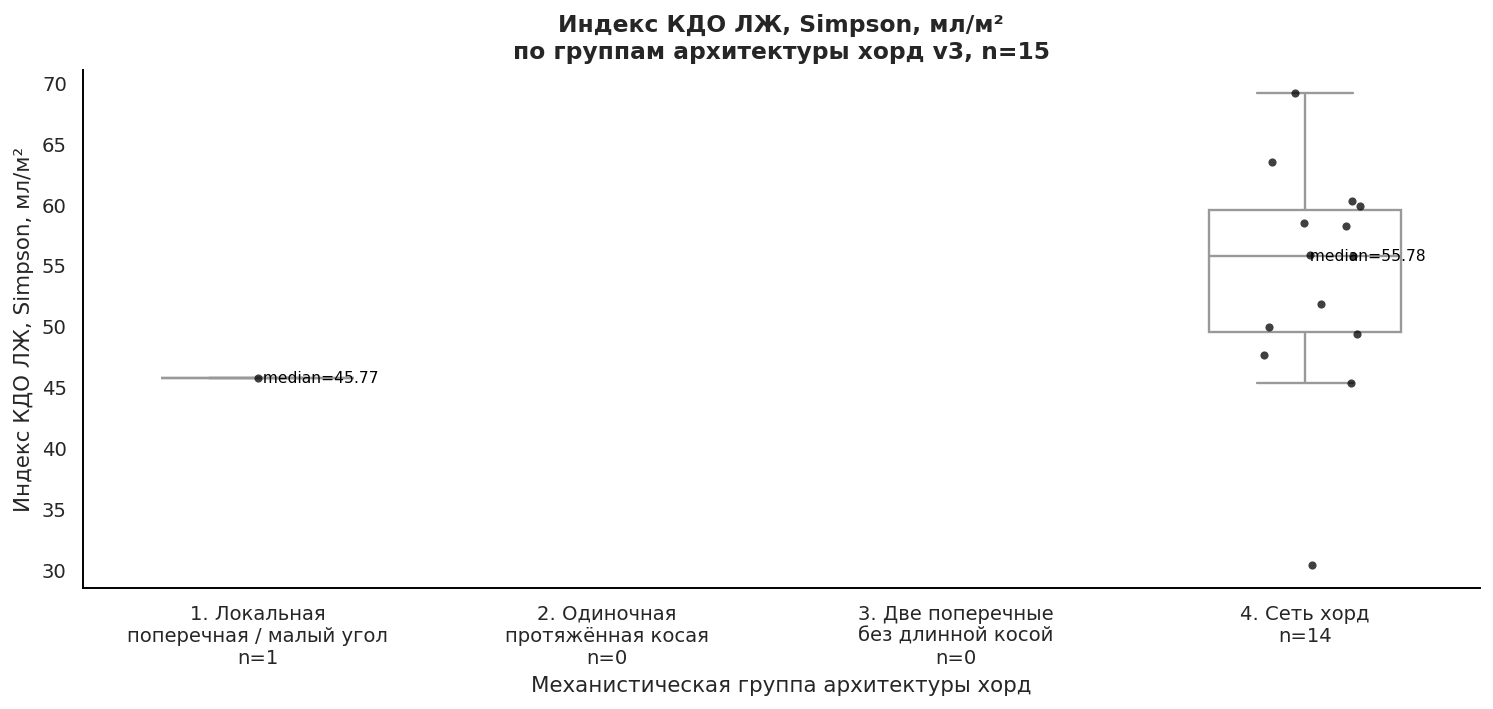

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_additional_vo2_max_absolute_ml_min_by_chord_architecture.png


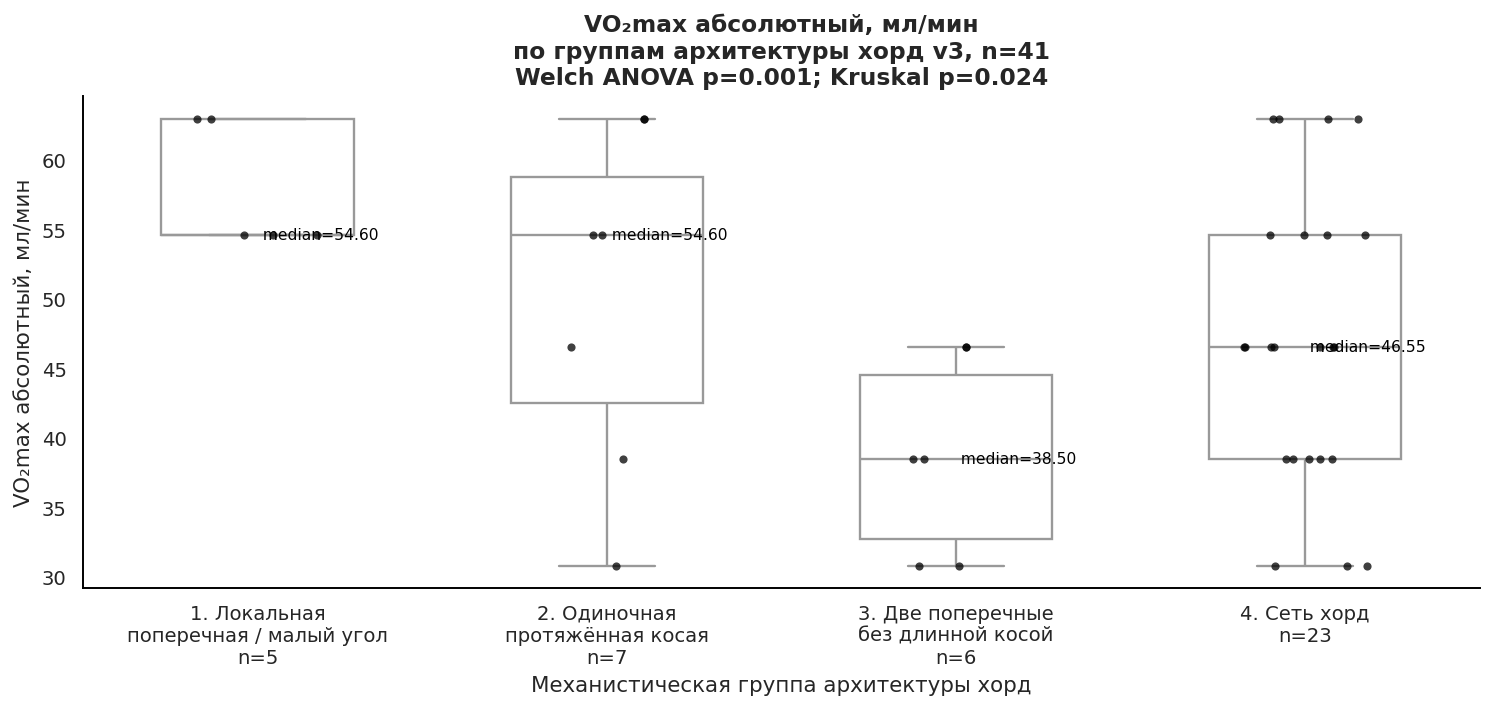

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_additional_echo_lv_systolic_wall_stress_g_cm2_by_chord_architecture.png


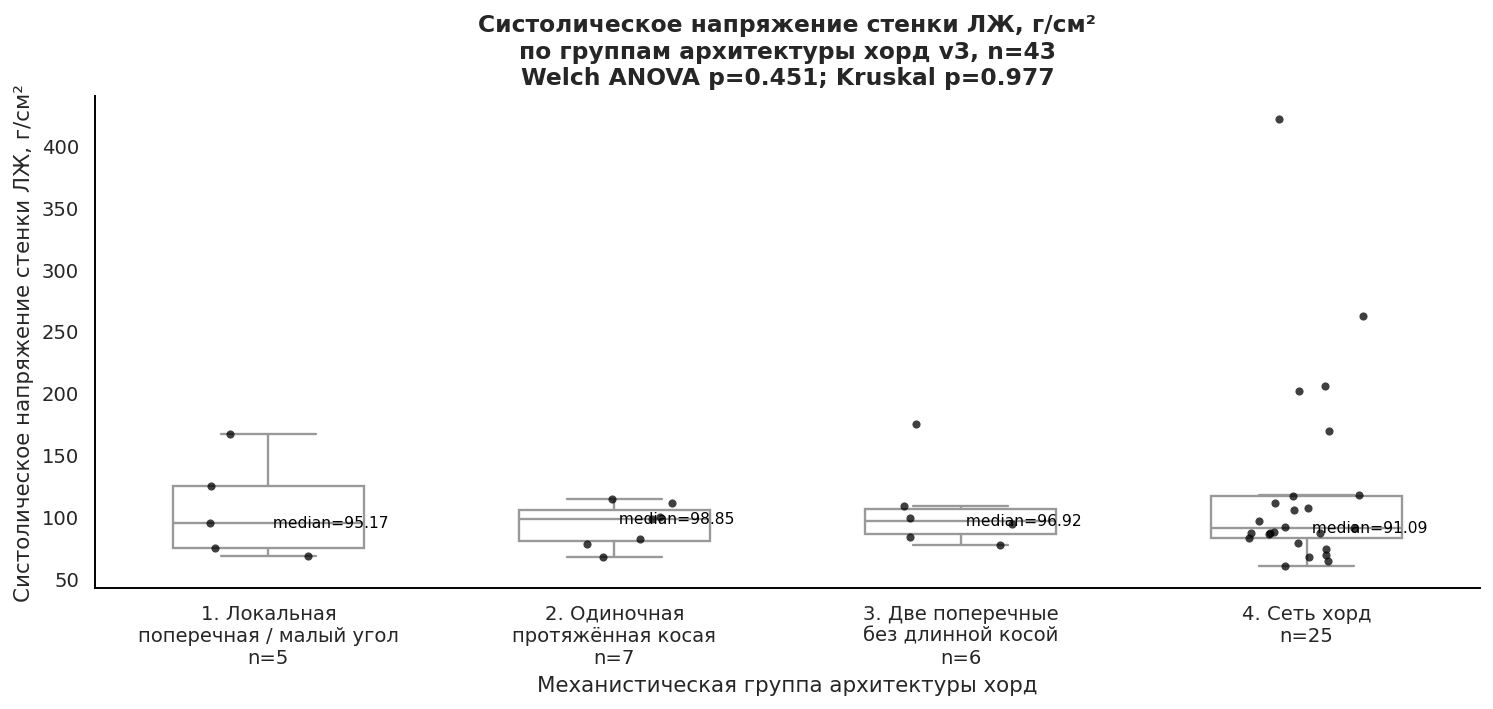

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_additional_echo_lv_systolic_wall_stress_per_mass_index_by_chord_architecture.png


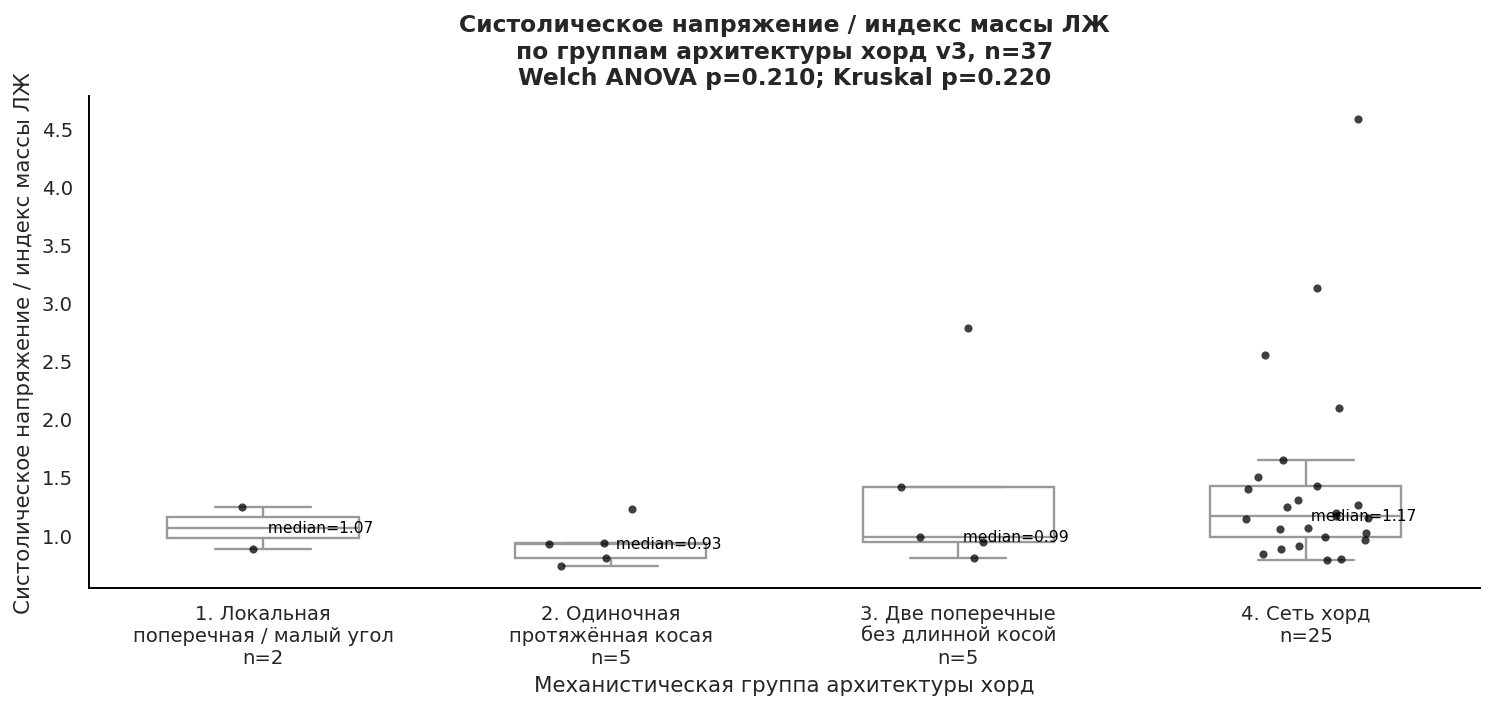

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_additional_echo_lv_sws_rest_per_mass_index_by_chord_architecture.png


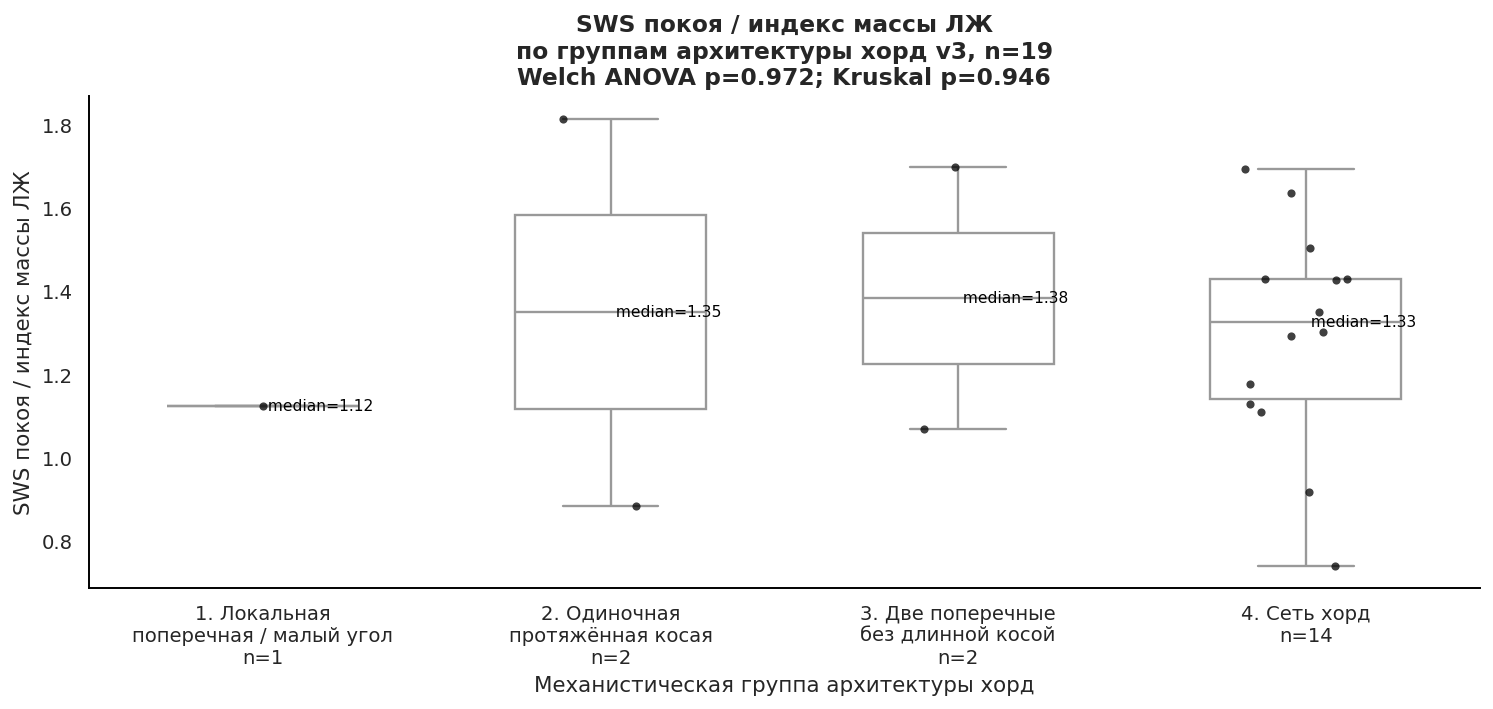

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_additional_echo_lv_sws_max_per_mass_index_by_chord_architecture.png


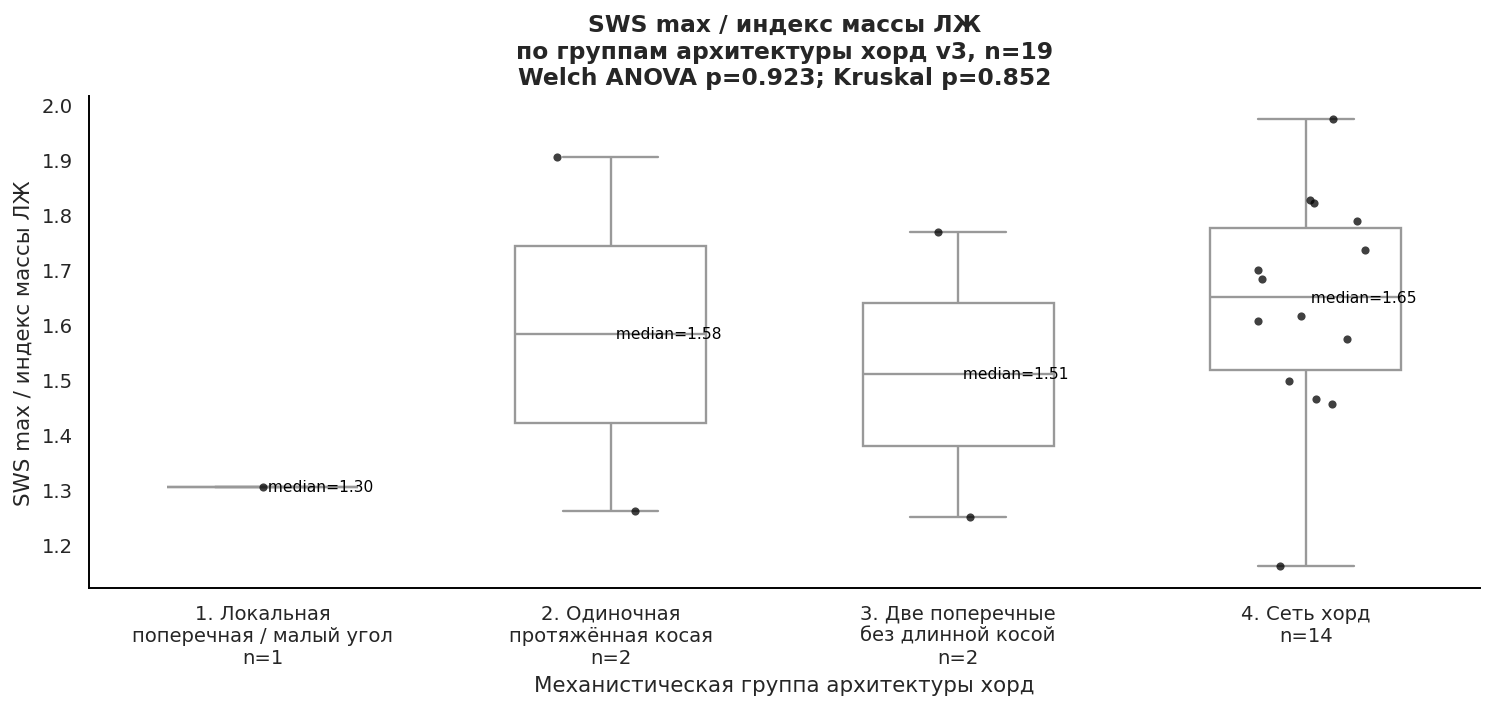

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_v3_additional_echo_lv_sws_delta_per_mass_index_by_chord_architecture.png


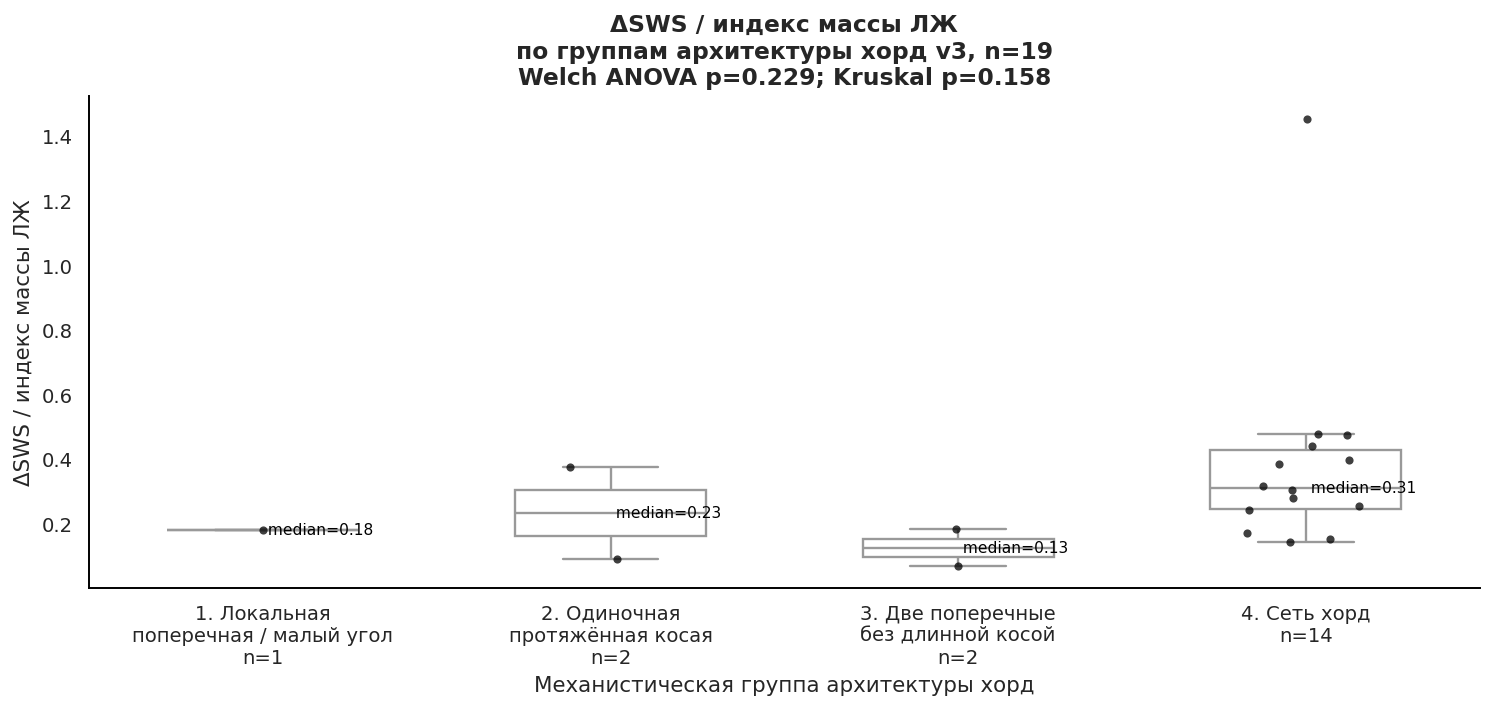

In [25]:
# ============================================================
# Boxplot + stripplot for additional outcomes
# ============================================================

def plot_additional_outcome_by_architecture(data, outcome, save=True):
    temp = data[[GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[GROUP_COL].isin(GROUP_ORDER)]

    if temp.empty:
        print(f"Skipping {outcome}: no data")
        return

    group_n = temp[GROUP_COL].value_counts().to_dict()

    xlabels = [
        f"{GROUP_LABELS_RU[g]}\nn={group_n.get(g, 0)}"
        for g in GROUP_ORDER
    ]

    fig, ax = plt.subplots(figsize=(10.8, 5.2))

    sns.boxplot(
        data=temp,
        x=GROUP_COL,
        y=outcome,
        order=GROUP_ORDER,
        color="white",
        width=0.55,
        fliersize=0,
        linewidth=1.2,
        ax=ax,
    )

    sns.stripplot(
        data=temp,
        x=GROUP_COL,
        y=outcome,
        order=GROUP_ORDER,
        color="black",
        size=4.2,
        jitter=0.18,
        alpha=0.75,
        ax=ax,
    )

    medians = temp.groupby(GROUP_COL)[outcome].median()

    for i, g in enumerate(GROUP_ORDER):
        if g in medians.index:
            ax.text(
                i,
                medians.loc[g],
                f" median={medians.loc[g]:.2f}",
                va="center",
                ha="left",
                fontsize=8,
                color="black",
            )

    p_txt = ""
    if "additional_anova_results" in globals() and not additional_anova_results.empty:
        row = additional_anova_results[additional_anova_results["outcome"] == outcome]
        if not row.empty:
            welch_p = row["welch_anova_p"].iloc[0]
            kruskal_p = row["kruskal_p"].iloc[0]
            p_txt = f"\nWelch ANOVA p={welch_p:.3f}; Kruskal p={kruskal_p:.3f}"

    ax.set_xlabel("Механистическая группа архитектуры хорд")
    ax.set_ylabel(ADDITIONAL_OUTCOME_LABELS_RU.get(outcome, outcome))
    ax.set_xticklabels(xlabels)

    ax.set_title(
        f"{ADDITIONAL_OUTCOME_LABELS_RU.get(outcome, outcome)}\n"
        f"по группам архитектуры хорд v3, n={len(temp)}{p_txt}"
    )

    sns.despine(ax=ax)
    plt.tight_layout()

    if save:
        file_name = f"18_v3_additional_{outcome}_by_chord_architecture.png"
        fig.savefig(FIGURES_DIR / file_name, bbox_inches="tight")
        print("Saved:", FIGURES_DIR / file_name)

    plt.show()


for outcome in existing_additional_outcomes:
    plot_additional_outcome_by_architecture(df, outcome)

In [26]:
# ============================================================
# VO2max adjusted analysis: chord architecture v3 + covariates
# ============================================================

import numpy as np
import pandas as pd

GROUP_COL = "chord_architecture_v3"
VO2_COL = "vo2_max_absolute_ml_min"

GROUP_ORDER = [
    "1_Local_transverse_or_low_angle",
    "2_Single_long_oblique_bridge",
    "3_Double_transverse_no_long_oblique",
    "4_Chord_network",
]

GROUP_LABELS_RU = {
    "1_Local_transverse_or_low_angle": "1. Локальная\nпоперечная / малый угол",
    "2_Single_long_oblique_bridge": "2. Одиночная\nпротяжённая косая",
    "3_Double_transverse_no_long_oblique": "3. Две поперечные\nбез длинной косой",
    "4_Chord_network": "4. Сеть хорд",
}

# Пытаемся найти подходящие ковариаты
candidate_covariates = {
    "sex": ["sex", "gender"],
    "age": ["age"],
    "weight": ["weight_kg", "weight", "body_weight_kg", "weight_cm"],
    "bsa": ["BSA", "bsa", "body_surface_area"],
    "height": ["height_cm", "height"],
}

selected_covariates = {}

for key, candidates in candidate_covariates.items():
    found = [c for c in candidates if c in df.columns]
    if found:
        selected_covariates[key] = found[0]

print("Selected covariates:")
print(selected_covariates)

# Предпочтение: sex + age + BSA
# если BSA нет, тогда sex + age + weight
base_covariates = []

if "sex" in selected_covariates:
    base_covariates.append(selected_covariates["sex"])

if "age" in selected_covariates:
    base_covariates.append(selected_covariates["age"])

if "bsa" in selected_covariates:
    base_covariates.append(selected_covariates["bsa"])
elif "weight" in selected_covariates:
    base_covariates.append(selected_covariates["weight"])

print("\nCovariates to use in main adjusted model:")
print(base_covariates)

needed_cols = [GROUP_COL, VO2_COL] + base_covariates
vo2_df = df[needed_cols].copy()

for col in needed_cols:
    vo2_df[col] = pd.to_numeric(vo2_df[col], errors="ignore")

vo2_df = vo2_df.dropna()
vo2_df = vo2_df[vo2_df[GROUP_COL].isin(GROUP_ORDER)].copy()

print("\nAnalysis dataset shape:", vo2_df.shape)
display(vo2_df.head())

display(
    vo2_df[GROUP_COL]
    .value_counts()
    .rename_axis(GROUP_COL)
    .reset_index(name="n")
)

Selected covariates:
{'sex': 'sex', 'age': 'age', 'weight': 'weight_cm', 'bsa': 'BSA', 'height': 'height_cm'}

Covariates to use in main adjusted model:
['sex', 'age', 'BSA']

Analysis dataset shape: (41, 5)


,chord_architecture_v3,vo2_max_absolute_ml_min,sex,age,BSA
0,2_Single_long_oblique_bridge,54.6,1.0,23.0,1.849925
2,4_Chord_network,38.5,1.0,20.0,1.587057
3,4_Chord_network,30.8,1.0,21.0,1.500148
4,4_Chord_network,38.5,1.0,17.0,1.568350
5,4_Chord_network,63.0,1.0,18.0,1.707500


,chord_architecture_v3,n
0,4_Chord_network,23
1,2_Single_long_oblique_bridge,7
2,3_Double_transverse_no_long_oblique,6
3,1_Local_transverse_or_low_angle,5


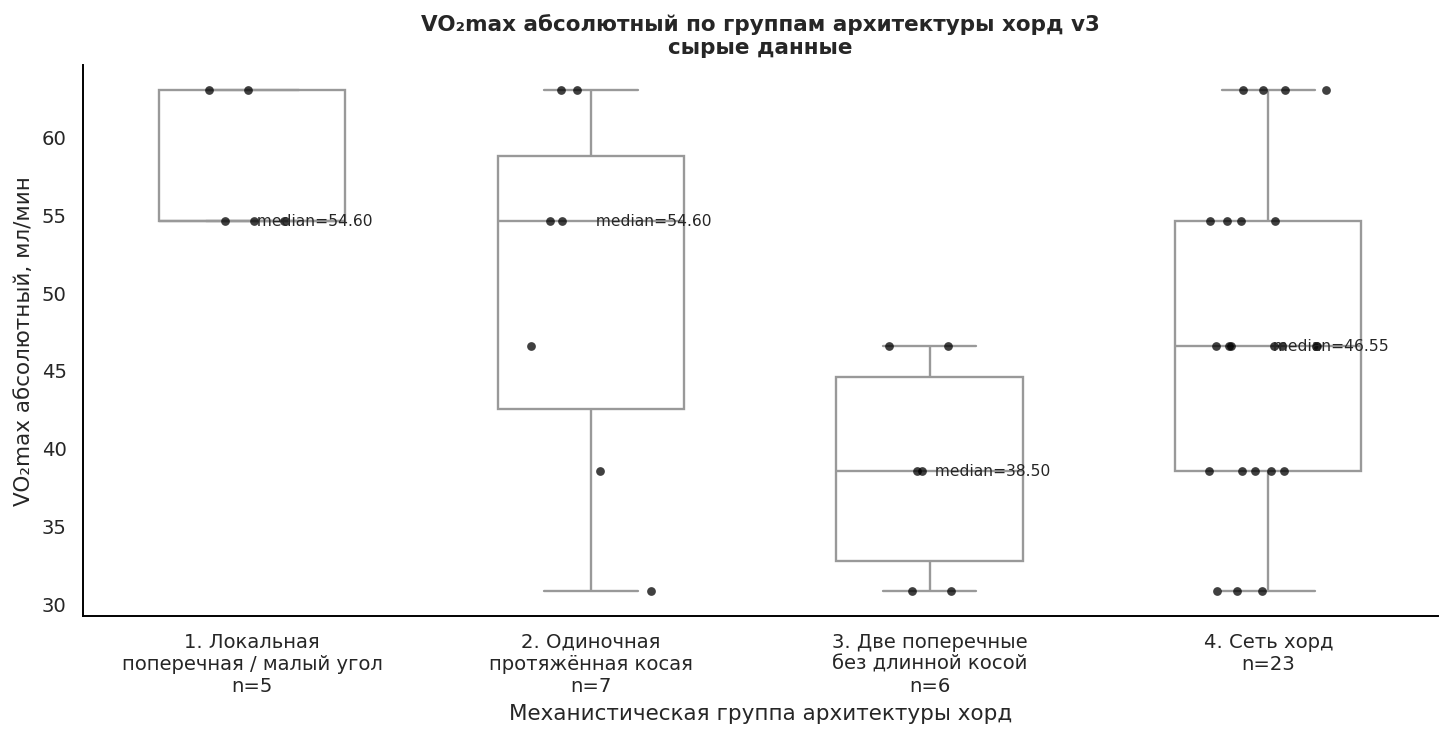

In [27]:
# ============================================================
# Raw VO2max boxplot
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="paper", style="white", font_scale=1.15)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

group_n = vo2_df[GROUP_COL].value_counts().to_dict()
xlabels = [f"{GROUP_LABELS_RU[g]}\nn={group_n.get(g, 0)}" for g in GROUP_ORDER]

fig, ax = plt.subplots(figsize=(10.5, 5.4))

sns.boxplot(
    data=vo2_df,
    x=GROUP_COL,
    y=VO2_COL,
    order=GROUP_ORDER,
    color="white",
    width=0.55,
    fliersize=0,
    linewidth=1.2,
    ax=ax,
)

sns.stripplot(
    data=vo2_df,
    x=GROUP_COL,
    y=VO2_COL,
    order=GROUP_ORDER,
    color="black",
    size=4.5,
    jitter=0.18,
    alpha=0.75,
    ax=ax,
)

medians = vo2_df.groupby(GROUP_COL)[VO2_COL].median()
for i, g in enumerate(GROUP_ORDER):
    if g in medians.index:
        ax.text(i, medians.loc[g], f" median={medians.loc[g]:.2f}", ha="left", va="center", fontsize=8)

ax.set_xticklabels(xlabels)
ax.set_xlabel("Механистическая группа архитектуры хорд")
ax.set_ylabel("VO₂max абсолютный, мл/мин")
ax.set_title("VO₂max абсолютный по группам архитектуры хорд v3\nсырые данные")

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# Adjusted OLS model for VO2max
# ============================================================

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm

# Делаем копию и категориальную переменную с порядком
vo2_model_df = vo2_df.copy()
vo2_model_df[GROUP_COL] = pd.Categorical(vo2_model_df[GROUP_COL], categories=GROUP_ORDER, ordered=True)

covariate_terms = []
for c in base_covariates:
    if c == selected_covariates.get("sex"):
        covariate_terms.append(f"C({c})")
    else:
        covariate_terms.append(c)

formula = f"{VO2_COL} ~ C({GROUP_COL})"
if covariate_terms:
    formula += " + " + " + ".join(covariate_terms)

print("Model formula:")
print(formula)

vo2_model = smf.ols(formula, data=vo2_model_df).fit(cov_type="HC3")

print(vo2_model.summary())

# Type II ANOVA table (обычная, без HC3; использовать как ориентир)
vo2_anova = anova_lm(smf.ols(formula, data=vo2_model_df).fit(), typ=2)
display(vo2_anova)

# Отдельно достанем строки с группой
group_rows = vo2_model.params.index[vo2_model.params.index.str.contains(GROUP_COL, regex=False)]
print("\nGroup contrast terms:")
display(
    pd.DataFrame({
        "coef": vo2_model.params[group_rows],
        "p_value_hc3": vo2_model.pvalues[group_rows],
        "ci_low_hc3": vo2_model.conf_int().loc[group_rows, 0],
        "ci_high_hc3": vo2_model.conf_int().loc[group_rows, 1],
    })
)

# Сохраняем компактную таблицу
vo2_model_results = pd.DataFrame({
    "term": vo2_model.params.index,
    "coef": vo2_model.params.values,
    "p_value_hc3": vo2_model.pvalues.values,
    "ci_low_hc3": vo2_model.conf_int()[0].values,
    "ci_high_hc3": vo2_model.conf_int()[1].values,
})

display(vo2_model_results)

Model formula:
vo2_max_absolute_ml_min ~ C(chord_architecture_v3) + C(sex) + age + BSA
                               OLS Regression Results                              
Dep. Variable:     vo2_max_absolute_ml_min   R-squared:                       0.339
Model:                                 OLS   Adj. R-squared:                  0.222
Method:                      Least Squares   F-statistic:                     6.458
Date:                     Sat, 30 May 2026   Prob (F-statistic):           0.000130
Time:                             12:51:42   Log-Likelihood:                -146.93
No. Observations:                       41   AIC:                             307.9
Df Residuals:                           34   BIC:                             319.9
Df Model:                                6                                         
Covariance Type:                       HC3                                         
                                                                      coe

,sum_sq,df,F,PR(>F)
C(chord_architecture_v3),850.400484,3.0,3.097131,0.039643
C(sex),405.575828,1.0,4.431282,0.042751
age,150.761099,1.0,1.647201,0.208019
BSA,14.320580,1.0,0.156465,0.694903
Residual,3111.870931,34.0,NaN,NaN



Group contrast terms:


,coef,p_value_hc3,ci_low_hc3,ci_high_hc3
C(chord_architecture_v3)[T.2_Single_long_oblique_bridge],-5.892064,0.286485,-16.726693,4.942566
C(chord_architecture_v3)[T.3_Double_transverse_no_long_oblique],-17.447640,0.000194,-26.623268,-8.272013
C(chord_architecture_v3)[T.4_Chord_network],-10.277286,0.004582,-17.382416,-3.172155


,term,coef,p_value_hc3,ci_low_hc3,ci_high_hc3
0,Intercept,38.428042,0.064627,-2.332034,79.188118
1,C(chord_architecture_v3)[T.2_Single_long_obliq...,-5.892064,0.286485,-16.726693,4.942566
2,C(chord_architecture_v3)[T.3_Double_transverse...,-17.447640,0.000194,-26.623268,-8.272013
3,C(chord_architecture_v3)[T.4_Chord_network],-10.277286,0.004582,-17.382416,-3.172155
4,C(sex)[T.2.0],-9.388144,0.021769,-17.407940,-1.368348
5,age,0.754057,0.229477,-0.475797,1.983911
6,BSA,4.035551,0.754364,-21.243406,29.314508


,chord_architecture_v3,sex,age,BSA,pred_mean,ci_low,ci_high
0,1_Local_transverse_or_low_angle,1.0,20.146341,1.796265,60.868447,55.272188,66.464705
1,2_Single_long_oblique_bridge,1.0,20.146341,1.796265,54.976383,45.227779,64.724986
2,3_Double_transverse_no_long_oblique,1.0,20.146341,1.796265,43.420806,35.585090,51.256522
3,4_Chord_network,1.0,20.146341,1.796265,50.591161,45.356440,55.825881


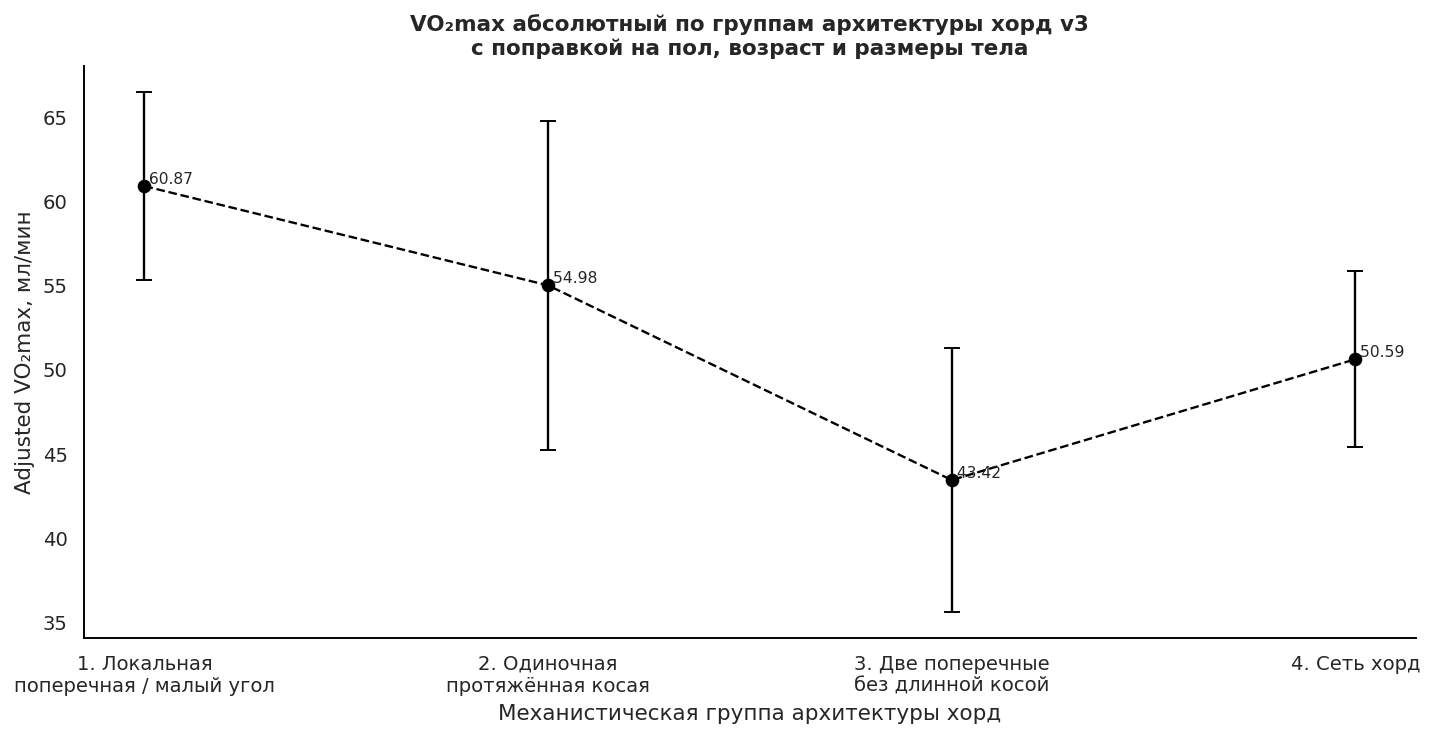

In [29]:
# ============================================================
# Adjusted means plot for VO2max
# ============================================================

# Создаём reference grid:
# age/BSA/weight = среднее
# sex = модальный уровень
ref_rows = []

ref_dict = {}

for c in base_covariates:
    if c == selected_covariates.get("sex"):
        ref_dict[c] = vo2_model_df[c].mode(dropna=True).iloc[0]
    else:
        ref_dict[c] = vo2_model_df[c].mean()

for g in GROUP_ORDER:
    row = {GROUP_COL: g}
    row.update(ref_dict)
    ref_rows.append(row)

pred_df = pd.DataFrame(ref_rows)
pred_df[GROUP_COL] = pd.Categorical(pred_df[GROUP_COL], categories=GROUP_ORDER, ordered=True)

pred = vo2_model.get_prediction(pred_df).summary_frame(alpha=0.05)

adjusted_means_df = pred_df.copy()
adjusted_means_df["pred_mean"] = pred["mean"].values
adjusted_means_df["ci_low"] = pred["mean_ci_lower"].values
adjusted_means_df["ci_high"] = pred["mean_ci_upper"].values

display(adjusted_means_df)

fig, ax = plt.subplots(figsize=(10.5, 5.4))

x = np.arange(len(adjusted_means_df))
y = adjusted_means_df["pred_mean"].values
yerr_low = y - adjusted_means_df["ci_low"].values
yerr_high = adjusted_means_df["ci_high"].values - y

ax.errorbar(
    x,
    y,
    yerr=[yerr_low, yerr_high],
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=1.2,
    capsize=4,
    markersize=6,
)
ax.plot(x, y, linestyle="--", color="black", linewidth=1.2)

for i, row in adjusted_means_df.iterrows():
    ax.text(
        i,
        row["pred_mean"],
        f" {row['pred_mean']:.2f}",
        ha="left",
        va="bottom",
        fontsize=8,
    )

ax.set_xticks(x)
ax.set_xticklabels([GROUP_LABELS_RU[g] for g in GROUP_ORDER])
ax.set_ylabel("Adjusted VO₂max, мл/мин")
ax.set_xlabel("Механистическая группа архитектуры хорд")
ax.set_title(
    "VO₂max абсолютный по группам архитектуры хорд v3\n"
    "с поправкой на пол, возраст и размеры тела"
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

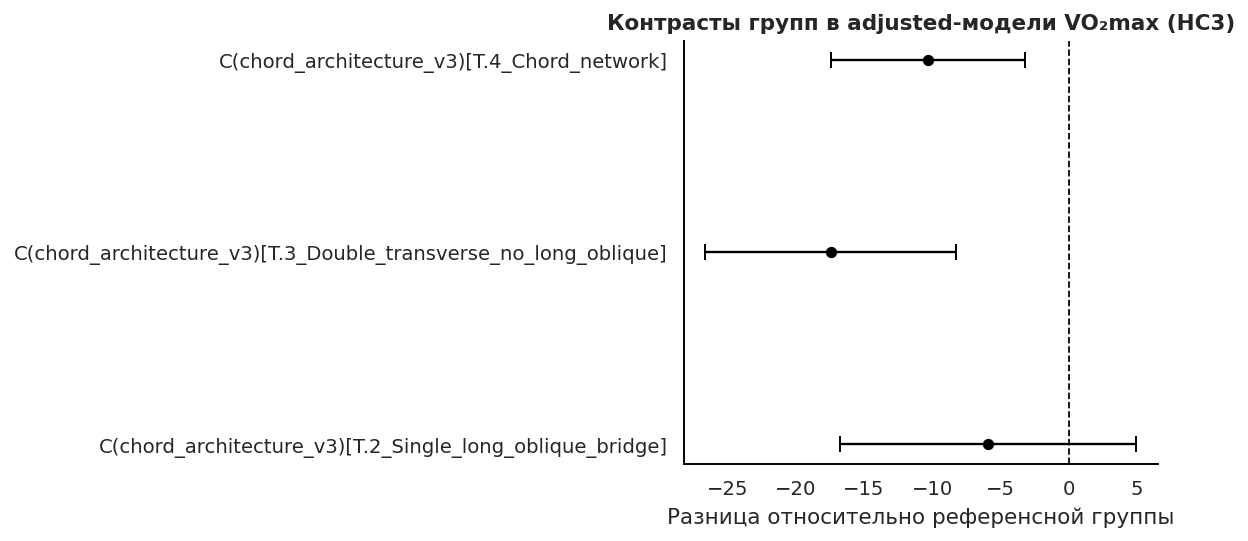

In [30]:
# ============================================================
# Coefficient plot for group contrasts (HC3)
# ============================================================

coef_df = vo2_model_results.copy()
coef_df = coef_df[coef_df["term"].str.contains(GROUP_COL, regex=False)].copy()

if not coef_df.empty:
    fig, ax = plt.subplots(figsize=(8.5, max(4, 0.6 * len(coef_df))))

    y_pos = np.arange(len(coef_df))
    coefs = coef_df["coef"].values
    ci_low = coef_df["ci_low_hc3"].values
    ci_high = coef_df["ci_high_hc3"].values

    ax.errorbar(
        coefs,
        y_pos,
        xerr=[coefs - ci_low, ci_high - coefs],
        fmt="o",
        color="black",
        ecolor="black",
        capsize=4,
    )

    ax.axvline(0, color="black", linestyle="--", linewidth=0.9)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(coef_df["term"])
    ax.set_xlabel("Разница относительно референсной группы")
    ax.set_title("Контрасты групп в adjusted-модели VO₂max (HC3)")

    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("No group contrast terms found.")

Covariate-only model used for residualization:
vo2_max_absolute_ml_min ~ C(sex) + age + BSA
Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\18_vo2_ols_adjusted_individual_values_with_adjusted_means.png


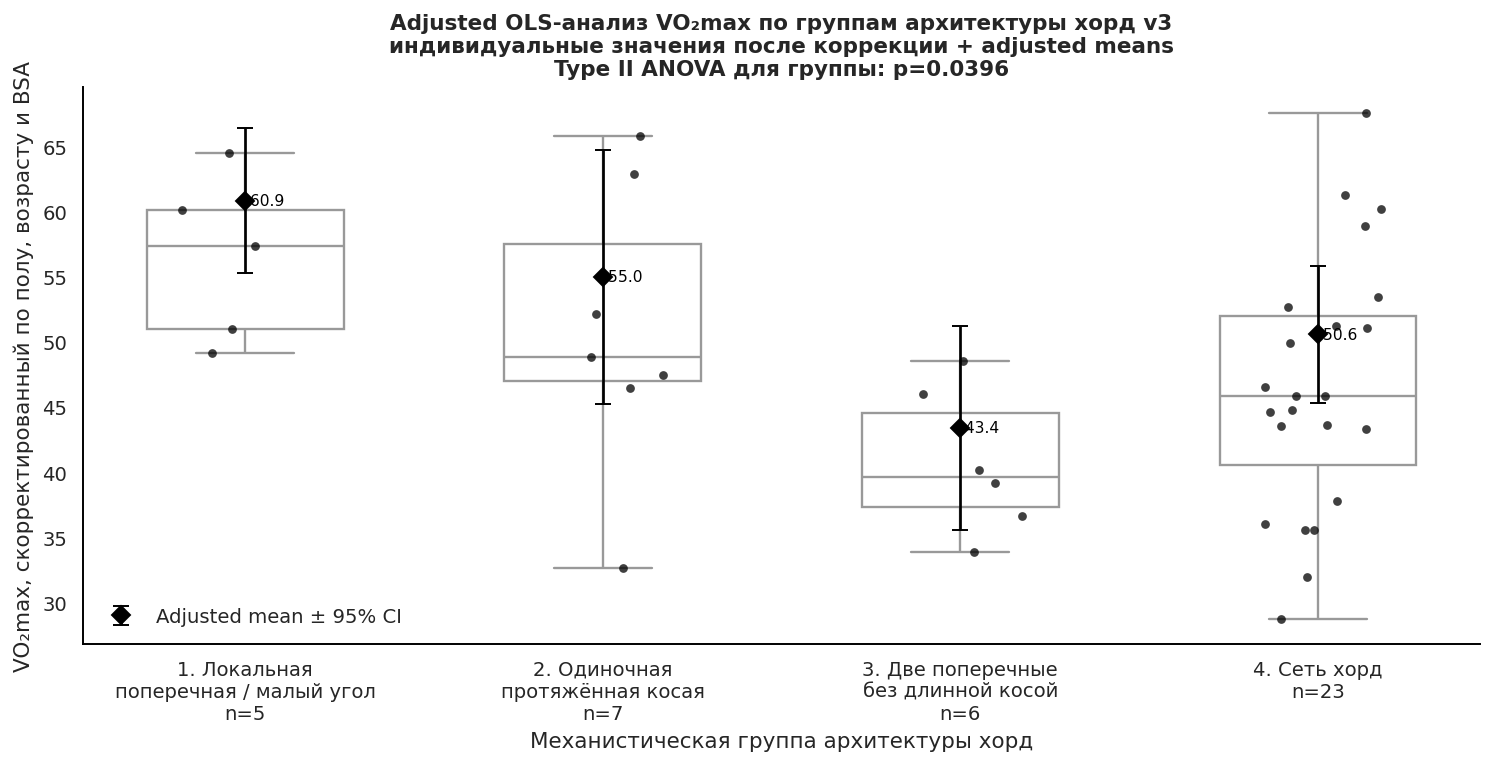

In [31]:
# ============================================================
# Academic plot for adjusted OLS:
# Covariate-adjusted individual VO2max + model adjusted means
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

GROUP_COL = "chord_architecture_v3"
VO2_COL = "vo2_max_absolute_ml_min"

GROUP_ORDER = [
    "1_Local_transverse_or_low_angle",
    "2_Single_long_oblique_bridge",
    "3_Double_transverse_no_long_oblique",
    "4_Chord_network",
]

GROUP_LABELS_RU = {
    "1_Local_transverse_or_low_angle": "1. Локальная\nпоперечная / малый угол",
    "2_Single_long_oblique_bridge": "2. Одиночная\nпротяжённая косая",
    "3_Double_transverse_no_long_oblique": "3. Две поперечные\nбез длинной косой",
    "4_Chord_network": "4. Сеть хорд",
}

sns.set_theme(context="paper", style="white", font_scale=1.15)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "figure.figsize": (10.8, 5.6),
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

# ------------------------------------------------------------
# 1. Create covariate-adjusted individual VO2 values
# ------------------------------------------------------------
# Логика:
# 1) строим модель только на ковариатах: VO2 ~ sex + age + BSA
# 2) берём residuals
# 3) добавляем средний VO2
# Получается VO2, очищенный от пола, возраста и BSA,
# но сохраняющий различия между группами хорд.

adjusted_plot_df = vo2_model_df.copy()

covariate_terms_for_residualization = []

for c in base_covariates:
    if c == selected_covariates.get("sex"):
        covariate_terms_for_residualization.append(f"C({c})")
    else:
        covariate_terms_for_residualization.append(c)

if len(covariate_terms_for_residualization) > 0:
    cov_formula = (
        f"{VO2_COL} ~ "
        + " + ".join(covariate_terms_for_residualization)
    )

    cov_model = smf.ols(cov_formula, data=adjusted_plot_df).fit()

    adjusted_plot_df["vo2_covariate_adjusted"] = (
        cov_model.resid + adjusted_plot_df[VO2_COL].mean()
    )

    print("Covariate-only model used for residualization:")
    print(cov_formula)

else:
    adjusted_plot_df["vo2_covariate_adjusted"] = adjusted_plot_df[VO2_COL]
    print("No covariates found. Using raw VO2 values.")

# ------------------------------------------------------------
# 2. Prepare labels and p-values
# ------------------------------------------------------------

group_n = adjusted_plot_df[GROUP_COL].value_counts().to_dict()

xlabels = [
    f"{GROUP_LABELS_RU[g]}\nn={group_n.get(g, 0)}"
    for g in GROUP_ORDER
]

# Group-level p-value from Type II ANOVA if available
p_group_txt = ""

if "vo2_anova" in globals():
    try:
        p_group = vo2_anova.loc[f"C({GROUP_COL})", "PR(>F)"]
        p_group_txt = f"\nType II ANOVA для группы: p={p_group:.4f}"
    except Exception:
        pass

# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.8, 5.6))

# Boxplot of covariate-adjusted individual values
sns.boxplot(
    data=adjusted_plot_df,
    x=GROUP_COL,
    y="vo2_covariate_adjusted",
    order=GROUP_ORDER,
    color="white",
    width=0.55,
    fliersize=0,
    linewidth=1.2,
    ax=ax,
)

# Individual adjusted points
sns.stripplot(
    data=adjusted_plot_df,
    x=GROUP_COL,
    y="vo2_covariate_adjusted",
    order=GROUP_ORDER,
    color="black",
    size=4.5,
    jitter=0.18,
    alpha=0.75,
    ax=ax,
)

# ------------------------------------------------------------
# 4. Overlay model adjusted means with 95% CI
# ------------------------------------------------------------

if "adjusted_means_df" in globals():
    means = adjusted_means_df.copy()
    means[GROUP_COL] = pd.Categorical(
        means[GROUP_COL],
        categories=GROUP_ORDER,
        ordered=True,
    )
    means = means.sort_values(GROUP_COL)

    x = np.arange(len(GROUP_ORDER))

    y = means["pred_mean"].values
    yerr_low = y - means["ci_low"].values
    yerr_high = means["ci_high"].values - y

    ax.errorbar(
        x,
        y,
        yerr=[yerr_low, yerr_high],
        fmt="D",
        color="black",
        ecolor="black",
        elinewidth=1.4,
        capsize=4,
        markersize=6.5,
        label="Adjusted mean ± 95% CI",
        zorder=5,
    )

    for i, row in means.iterrows():
        group_index = GROUP_ORDER.index(row[GROUP_COL])
        ax.text(
            group_index,
            row["pred_mean"],
            f" {row['pred_mean']:.1f}",
            ha="left",
            va="center",
            fontsize=8,
            color="black",
        )

# ------------------------------------------------------------
# 5. Final formatting
# ------------------------------------------------------------

ax.set_xticklabels(xlabels)
ax.set_xlabel("Механистическая группа архитектуры хорд")
ax.set_ylabel("VO₂max, скорректированный по полу, возрасту и BSA")

ax.set_title(
    "Adjusted OLS-анализ VO₂max по группам архитектуры хорд v3\n"
    "индивидуальные значения после коррекции + adjusted means"
    f"{p_group_txt}"
)

ax.legend(loc="best")

sns.despine(ax=ax)
plt.tight_layout()

file_name = "18_vo2_ols_adjusted_individual_values_with_adjusted_means.png"
fig.savefig(FIGURES_DIR / file_name, bbox_inches="tight")
print("Saved:", FIGURES_DIR / file_name)

plt.show()

## Adjusted-анализ VO₂max по механистическим группам архитектуры хорд

Для проверки связи между механистической архитектурой ложных хорд и показателем VO₂max была построена adjusted OLS-модель с робастными стандартными ошибками HC3.

Модель имела следующий вид:

`vo2_max_absolute_ml_min ~ C(chord_architecture_v3) + C(sex) + age + BSA`

То есть сравнение групп хорд выполнялось с поправкой на пол, возраст и площадь поверхности тела.

Всего в модель вошло 41 наблюдение. Модель в целом была статистически значимой: `Prob(F) = 0.00013`. Коэффициент детерминации составил `R² = 0.339`, adjusted `R² = 0.222`, что означает, что модель объясняет примерно 22–34% вариации VO₂max.

По Type II ANOVA фактор механистической архитектуры хорд был связан с VO₂max: `p = 0.0396`. Также значимым фактором оказался пол: `p = 0.0428`. Возраст и BSA в данной модели статистически значимого вклада не показали.

Референсной группой была выбрана группа `1. Локальная поперечная / малый угол`.

По сравнению с этой группой:

* `2. Одиночная протяжённая косая` имела VO₂max ниже примерно на 5.89 единицы, но различие не было статистически значимым: `p = 0.286`;
* `3. Две поперечные без длинной косой` имела VO₂max ниже примерно на 17.45 единицы: `p = 0.00019`;
* `4. Сеть хорд` имела VO₂max ниже примерно на 10.28 единицы: `p = 0.0046`.

Adjusted means при одинаковых значениях пола, возраста и BSA составили:

* `1. Локальная поперечная / малый угол`: 60.87;
* `2. Одиночная протяжённая косая`: 54.98;
* `3. Две поперечные без длинной косой`: 43.42;
* `4. Сеть хорд`: 50.59.

Таким образом, после поправки на пол, возраст и размеры тела связь между архитектурой хорд и VO₂max сохраняется. Наиболее низкие adjusted-значения VO₂max наблюдаются в группе `3. Две поперечные без длинной косой`, а также в группе `4. Сеть хорд`.

Предварительная физиологическая интерпретация: более выраженная поперечная или сетевая внутриполостная архитектура хорд может быть ассоциирована с более низкой аэробной производительностью. Однако этот результат следует трактовать осторожно, так как размеры отдельных групп небольшие, особенно в референсной группе и группе двух поперечных хорд.

Также важно дополнительно проверить единицы измерения переменной `vo2_max_absolute_ml_min`: значения порядка 30–60 больше похожи на относительный VO₂max в мл/кг/мин, а не на абсолютный VO₂max в мл/мин. Поэтому перед финальной интерпретацией необходимо уточнить, является ли этот показатель абсолютным или относительным.


In [32]:
# ============================================================
# Extreme phenotype for systolic wall stress
# ============================================================

STRESS_COL = "echo_lv_systolic_wall_stress_g_cm2"
STRESS_RATIO_COL = "echo_lv_systolic_wall_stress_per_mass_index"
DELTA_RATIO_COL = "echo_lv_sws_delta_per_mass_index"

extreme_candidates = [c for c in [STRESS_COL, STRESS_RATIO_COL, DELTA_RATIO_COL] if c in df.columns]
print("Available stress candidates:", extreme_candidates)

# Выбери основной extreme phenotype
TARGET_EXTREME_COL = STRESS_RATIO_COL if STRESS_RATIO_COL in df.columns else STRESS_COL
print("Using for extreme phenotype:", TARGET_EXTREME_COL)

stress_df = df[[GROUP_COL, TARGET_EXTREME_COL]].copy()
stress_df = stress_df.dropna()
stress_df = stress_df[stress_df[GROUP_COL].isin(GROUP_ORDER)].copy()

p85 = stress_df[TARGET_EXTREME_COL].quantile(0.85)
stress_df["extreme_phenotype"] = (stress_df[TARGET_EXTREME_COL] >= p85).astype(int)

print("85th percentile threshold:", p85)

display(
    stress_df["extreme_phenotype"]
    .value_counts()
    .rename_axis("extreme_phenotype")
    .reset_index(name="n")
)

display(
    pd.crosstab(stress_df[GROUP_COL], stress_df["extreme_phenotype"], margins=True)
)

Available stress candidates: ['echo_lv_systolic_wall_stress_g_cm2', 'echo_lv_systolic_wall_stress_per_mass_index', 'echo_lv_sws_delta_per_mass_index']
Using for extreme phenotype: echo_lv_systolic_wall_stress_per_mass_index
85th percentile threshold: 1.589656452393965


,extreme_phenotype,n
0,0,31
1,1,6


extreme_phenotype,0,1,All
chord_architecture_v3,,,
1_Local_transverse_or_low_angle,2,0,2
2_Single_long_oblique_bridge,5,0,5
3_Double_transverse_no_long_oblique,4,1,5
4_Chord_network,20,5,25
All,31,6,37


,chord_architecture_v3,count,sum,mean,percent
0,1_Local_transverse_or_low_angle,2,0,0.0,0.0
1,2_Single_long_oblique_bridge,5,0,0.0,0.0
2,3_Double_transverse_no_long_oblique,5,1,0.2,20.0
3,4_Chord_network,25,5,0.2,20.0


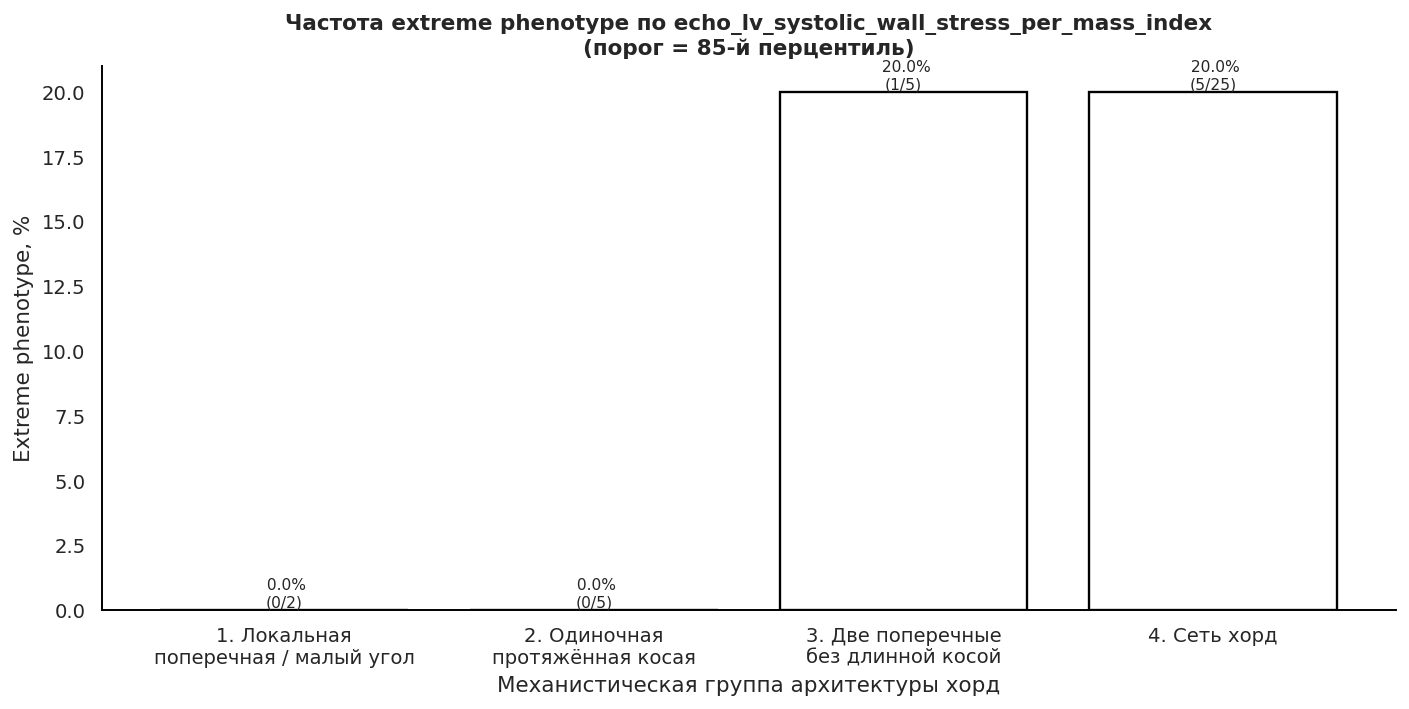

In [33]:
# ============================================================
# Plot prevalence of extreme phenotype by group
# ============================================================

prev_df = (
    stress_df
    .groupby(GROUP_COL)["extreme_phenotype"]
    .agg(["count", "sum", "mean"])
    .reindex(GROUP_ORDER)
    .reset_index()
)

prev_df["percent"] = prev_df["mean"] * 100

display(prev_df)

fig, ax = plt.subplots(figsize=(10.2, 5.2))

bars = ax.bar(
    np.arange(len(prev_df)),
    prev_df["percent"].values,
    edgecolor="black",
    color="white",
    linewidth=1.2,
)

for i, row in prev_df.iterrows():
    ax.text(
        i,
        row["percent"],
        f" {row['percent']:.1f}%\n({int(row['sum'])}/{int(row['count'])})",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_xticks(np.arange(len(prev_df)))
ax.set_xticklabels([GROUP_LABELS_RU[g] for g in prev_df[GROUP_COL]])
ax.set_ylabel("Extreme phenotype, %")
ax.set_xlabel("Механистическая группа архитектуры хорд")
ax.set_title(
    f"Частота extreme phenotype по {TARGET_EXTREME_COL}\n"
    f"(порог = 85-й перцентиль)"
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# Chi-square overall + network vs non-network
# ============================================================

from scipy.stats import chi2_contingency, fisher_exact

ct = pd.crosstab(stress_df[GROUP_COL], stress_df["extreme_phenotype"])
display(ct)

if ct.shape[0] >= 2 and ct.shape[1] == 2:
    chi2, p_chi2, dof, expected = chi2_contingency(ct)
    print(f"Overall chi-square p-value = {p_chi2:.4f}")
else:
    print("Chi-square not available.")

# network vs others
stress_df["network_binary"] = np.where(stress_df[GROUP_COL] == "4_Chord_network", "Network", "Non-network")
ct2 = pd.crosstab(stress_df["network_binary"], stress_df["extreme_phenotype"])
display(ct2)

if ct2.shape == (2, 2):
    odds_ratio, p_fisher = fisher_exact(ct2)
    print(f"Network vs non-network Fisher p-value = {p_fisher:.4f}")
    print(f"Odds ratio = {odds_ratio:.3f}")
else:
    print("Fisher exact not available.")

extreme_phenotype,0,1
chord_architecture_v3,,
1_Local_transverse_or_low_angle,2,0
2_Single_long_oblique_bridge,5,0
3_Double_transverse_no_long_oblique,4,1
4_Chord_network,20,5


Overall chi-square p-value = 0.6434


extreme_phenotype,0,1
network_binary,,
Network,20,5
Non-network,11,1


Network vs non-network Fisher p-value = 0.6409
Odds ratio = 0.364


In [35]:
# ============================================================
# Logistic regression for extreme stress phenotype
# Fixed version: create extreme phenotype in df first
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import fisher_exact, chi2_contingency

GROUP_COL = "chord_architecture_v3"

GROUP_ORDER = [
    "1_Local_transverse_or_low_angle",
    "2_Single_long_oblique_bridge",
    "3_Double_transverse_no_long_oblique",
    "4_Chord_network",
]

# ------------------------------------------------------------
# 1. Choose target variable for extreme phenotype
# ------------------------------------------------------------

stress_candidates = [
    "echo_lv_systolic_wall_stress_per_mass_index",
    "echo_lv_systolic_wall_stress_g_cm2",
    "echo_lv_sws_delta_per_mass_index",
]

available_stress_candidates = [c for c in stress_candidates if c in df.columns]

print("Available stress variables:")
print(available_stress_candidates)

TARGET_EXTREME_COL = "echo_lv_systolic_wall_stress_per_mass_index"

if TARGET_EXTREME_COL not in df.columns:
    TARGET_EXTREME_COL = available_stress_candidates[0]

print("Using target for extreme phenotype:", TARGET_EXTREME_COL)

df[TARGET_EXTREME_COL] = pd.to_numeric(df[TARGET_EXTREME_COL], errors="coerce")

# ------------------------------------------------------------
# 2. Create extreme phenotype directly inside df
# ------------------------------------------------------------

mask = (
    df[GROUP_COL].isin(GROUP_ORDER)
    & df[TARGET_EXTREME_COL].notna()
)

threshold_85 = df.loc[mask, TARGET_EXTREME_COL].quantile(0.85)

df["extreme_phenotype"] = np.nan
df.loc[mask, "extreme_phenotype"] = (
    df.loc[mask, TARGET_EXTREME_COL] >= threshold_85
).astype(int)

print("85th percentile threshold:", threshold_85)

display(
    df.loc[mask, "extreme_phenotype"]
    .value_counts(dropna=False)
    .rename_axis("extreme_phenotype")
    .reset_index(name="n")
)

# ------------------------------------------------------------
# 3. Crosstab: 4 groups × extreme phenotype
# ------------------------------------------------------------

ct = pd.crosstab(
    df.loc[mask, GROUP_COL],
    df.loc[mask, "extreme_phenotype"]
)

display(ct)

if ct.shape[0] >= 2 and ct.shape[1] == 2:
    chi2, p_chi2, dof, expected = chi2_contingency(ct)
    print(f"Overall chi-square p-value = {p_chi2:.4f}")
else:
    print("Chi-square not available.")

# ------------------------------------------------------------
# 4. Safer analysis: Network vs non-network
# ------------------------------------------------------------

network_df = df.loc[mask, [GROUP_COL, TARGET_EXTREME_COL, "extreme_phenotype"]].copy()

network_df["network_binary"] = np.where(
    network_df[GROUP_COL] == "4_Chord_network",
    "Network",
    "Non-network"
)

ct2 = pd.crosstab(
    network_df["network_binary"],
    network_df["extreme_phenotype"]
)

display(ct2)

if ct2.shape == (2, 2):
    odds_ratio, p_fisher = fisher_exact(ct2)
    print(f"Network vs non-network Fisher p-value = {p_fisher:.4f}")
    print(f"Odds ratio = {odds_ratio:.3f}")
else:
    print("Fisher exact not available.")

# ------------------------------------------------------------
# 5. Logistic regression
# ------------------------------------------------------------

# ВАЖНО:
# событий мало, поэтому полная модель 4 группы + sex + age + BSA
# может быть нестабильной. Сначала делаем более простую:
# extreme_phenotype ~ network_binary + sex + age + BSA

# проверяем ковариаты
available_covariates = [c for c in base_covariates if c in df.columns]

print("Available covariates:")
print(available_covariates)

logit_cols = [GROUP_COL, TARGET_EXTREME_COL, "extreme_phenotype"] + available_covariates

logit_df = df.loc[mask, logit_cols].copy()
logit_df = logit_df.dropna()

logit_df["network_binary"] = np.where(
    logit_df[GROUP_COL] == "4_Chord_network",
    "Network",
    "Non-network"
)

logit_df["extreme_phenotype"] = logit_df["extreme_phenotype"].astype(int)

print("Logit dataset shape:", logit_df.shape)
print("Number of extreme events:", logit_df["extreme_phenotype"].sum())

display(
    pd.crosstab(
        logit_df["network_binary"],
        logit_df["extreme_phenotype"],
        margins=True
    )
)

# ------------------------------------------------------------
# 6. Run logistic model only if enough events
# ------------------------------------------------------------

n_events = int(logit_df["extreme_phenotype"].sum())
n_nonevents = int((logit_df["extreme_phenotype"] == 0).sum())

if len(logit_df) >= 20 and n_events >= 5 and n_nonevents >= 5:
    
    terms = ["C(network_binary)"]
    
    for c in available_covariates:
        if c == "sex":
            terms.append(f"C({c})")
        else:
            terms.append(c)
    
    logit_formula = "extreme_phenotype ~ " + " + ".join(terms)
    
    print("Logistic formula:")
    print(logit_formula)
    
    try:
        logit_model = smf.logit(logit_formula, data=logit_df).fit(disp=False)
        print(logit_model.summary())
        
        params = logit_model.params
        conf = logit_model.conf_int()
        
        or_table = pd.DataFrame({
            "term": params.index,
            "OR": np.exp(params.values),
            "CI_low": np.exp(conf[0].values),
            "CI_high": np.exp(conf[1].values),
            "p_value": logit_model.pvalues.values,
        })
        
        display(or_table)
    
    except Exception as e:
        print("Logistic regression failed:")
        print(e)
        print("\nMost likely reason: too few events or quasi-separation.")
else:
    print("Too few events for logistic regression.")
    print("Use Fisher exact / descriptive prevalence instead.")

Available stress variables:
['echo_lv_systolic_wall_stress_per_mass_index', 'echo_lv_systolic_wall_stress_g_cm2', 'echo_lv_sws_delta_per_mass_index']
Using target for extreme phenotype: echo_lv_systolic_wall_stress_per_mass_index
85th percentile threshold: 1.589656452393965


,extreme_phenotype,n
0,0.0,31
1,1.0,6


extreme_phenotype,0.0,1.0
chord_architecture_v3,,
1_Local_transverse_or_low_angle,2,0
2_Single_long_oblique_bridge,5,0
3_Double_transverse_no_long_oblique,4,1
4_Chord_network,20,5


Overall chi-square p-value = 0.6434


extreme_phenotype,0.0,1.0
network_binary,,
Network,20,5
Non-network,11,1


Network vs non-network Fisher p-value = 0.6409
Odds ratio = 0.364
Available covariates:
['sex', 'age', 'BSA']
Logit dataset shape: (35, 7)
Number of extreme events: 6


extreme_phenotype,0,1,All
network_binary,,,
Network,18,5,23
Non-network,11,1,12
All,29,6,35


Logistic formula:
extreme_phenotype ~ C(network_binary) + C(sex) + age + BSA
                           Logit Regression Results                           
Dep. Variable:      extreme_phenotype   No. Observations:                   35
Model:                          Logit   Df Residuals:                       30
Method:                           MLE   Df Model:                            4
Date:                Sat, 30 May 2026   Pseudo R-squ.:                  0.1288
Time:                        12:51:44   Log-Likelihood:                -13.970
converged:                       True   LL-Null:                       -16.035
Covariance Type:            nonrobust   LLR p-value:                    0.3888
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -8.1213      8.850     -0.918      0.359     -25.466 

,term,OR,CI_low,CI_high,p_value
0,Intercept,0.000297,8.710639e-12,10135.590006,0.358779
1,C(network_binary)[T.Non-network],0.292444,1.717345e-02,4.979995,0.395312
2,C(sex)[T.2.0],0.060243,8.506657e-04,4.266393,0.196182
3,age,1.317025,8.335399e-01,2.080949,0.238056
4,BSA,3.452069,1.376040e-03,8660.201339,0.756385


## Extreme phenotype систолического напряжения стенки ЛЖ

Дополнительно был выполнен анализ экстремального фенотипа по показателю систолического напряжения стенки ЛЖ, нормированного на индекс массы миокарда ЛЖ. В качестве порога extreme phenotype использовался 85-й перцентиль распределения показателя.

Так как число наблюдений и число событий были небольшими, основной анализ был выполнен в двух вариантах:

1. сравнение всех 4 механистических групп архитектуры хорд;
2. укрупнённое сравнение `Network` vs `Non-network`.

По 4-групповой таблице распределение extreme phenotype было следующим:

* локальная поперечная / малый угол: 0 случаев extreme phenotype;
* одиночная протяжённая косая: 0 случаев;
* две поперечные без длинной косой: 1 случай;
* сеть хорд: 5 случаев.

При укрупнении до бинарной схемы:

* `Network`: 5 из 25 наблюдений, то есть 20.0%;
* `Non-network`: 1 из 12 наблюдений, то есть 8.3%.

Таким образом, визуально extreme phenotype чаще встречался в группе сетевой архитектуры хорд. Однако статистически эта связь не подтвердилась:

* χ² p-value = 0.643;
* Fisher exact p-value = 0.641;
* в логистической регрессии с поправкой на пол, возраст и BSA эффект `Non-network` относительно `Network` также не был значимым: p = 0.395.

Важно отметить, что логистическая модель имеет ограниченную устойчивость, так как число extreme-событий очень мало. Всего в модели было 35 наблюдений и только 6 событий extreme phenotype. Поэтому результат следует интерпретировать не как доказательство отсутствия эффекта, а как отсутствие статистического подтверждения при текущем размере выборки.

Предварительный вывод: сетевая архитектура хорд может визуально чаще сопровождаться экстремально высоким значением нормированного систолического напряжения стенки ЛЖ, однако на текущих данных эта ассоциация статистически не подтверждается. Для более надёжной проверки требуется больше наблюдений или анализ extreme phenotype на объединённой/расширенной выборке.
